# Multilingual Health Q&A -- Starter Notebook

**Challenge:** Multilingual Health Question Answering in Low-Resource African Languages

This notebook documents the full experimental pipeline developed for the Zindi Multilingual Maternal and Sexual/Reproductive Health (MSRH) Question Answering competition. The goal is to answer health questions in five African languages -- Amharic, Luganda, Akan, Swahili, and English -- across nine language-country configurations.

The competition spans roughly 29,815 training records, 2,618 test records, and a held-out validation set. Three scoring columns are required in each submission: `TargetRLF1` (ROUGE-L F1), `TargetR1F1` (ROUGE-1 F1), and `TargetLLM` (LLM-as-a-Judge score). All three columns receive the same generated answer per row.

The notebook is structured as a progression of 18 experiments. Each experiment tests one change against the previous best result, with a tracker cell recording validation ROUGE scores and confirmed leaderboard scores. The best final submission is Experiment 15c (TF-IDF + BM25 weighted interpolation at alpha=0.9), which scored **0.514958** on the Zindi leaderboard.

| Baseline | Approach | Speed | Quality |
|---|---|---|---|
| **Baseline 1** | TF-IDF retrieval | Very fast | Low |
| **Baseline 2** | Multilingual LLM (mT5 / NLLB) | Moderate | Higher |

**Task:** Given a health question in one of five African languages (Amharic, Luganda, Akan, Swahili, or English), generate a fluent and accurate answer in the **same language**.

**Evaluation metrics:**
- `TargetRLF1` -- ROUGE-L F1 score
- `TargetR1F1` -- ROUGE-1 F1 score
- `TargetLLM` -- LLM-as-a-Judge score

> **Note:** All three submission columns should contain the same generated answer for each row. The platform computes all three metrics from that single answer.

> **Key finding:** Retrieval-based methods consistently outperformed fine-tuned generation across this dataset. TF-IDF character n-gram retrieval and BM25 both beat every generative model tested, including fine-tuned mT5, Flan-T5, and NLLB-200. The final winning approach uses no neural model at inference time at all.

## 1 -- Install and Import Packages

All required libraries are installed in this cell before any imports run. The `rouge-score` library handles ROUGE-1 and ROUGE-L computation throughout the evaluation pipeline. `transformers` and `sentencepiece` are needed for the generative LLM experiments (Experiments 1c through 10). `rank_bm25` is installed separately in Experiment 11 because it is only needed from that point onward.

Running this cell first on a fresh Colab session ensures no `ModuleNotFoundError` interrupts mid-experiment. The `-q` flag suppresses pip output to keep logs readable.

In [ ]:
# Install required packages
# scikit-learn: TfidfVectorizer, NearestNeighbors, train_test_split
# rouge-score: ROUGE-1 and ROUGE-L evaluation (used from section 7 onward)
# transformers + sentencepiece + accelerate: needed for mT5, NLLB, Flan-T5 experiments
# torch: GPU inference for all generative experiments
!pip install -q scikit-learn pandas numpy rouge-score
!pip install -q transformers sentencepiece accelerate torch

print('Packages installed')


  Preparing metadata (setup.py) ... done
✅ Packages installed


In [ ]:
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# TfidfVectorizer: character n-gram features used in all retrieval experiments
# NearestNeighbors: cosine nearest neighbor search for TF-IDF retrieval
# train_test_split: used to carve out a fine-tuning validation split in Exp 1c / Exp 2
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')

# Fix all random seeds so train/val splits and sampling are reproducible
# across sessions. Any cell that calls random.sample, np.random, or
# DataFrame.sample will produce the same result as long as SEED=42 is set.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', None)

print('Imports complete')


✅ Imports complete


## 2 -- Set File Paths

All data files are expected in the current working directory (`.`). On Google Colab this is typically `/content/`. The `SampleSubmission.csv` file defines the required submission format -- four columns: `ID`, `TargetRLF1`, `TargetR1F1`, `TargetLLM` -- and is used as a template for every submission saved later.

Submission output files are written to the same directory and then copied to Google Drive for persistent storage across sessions.

In [ ]:
DATA_DIR = Path('.')

TRAIN_PATH      = DATA_DIR / 'Train.csv'
TEST_PATH       = DATA_DIR / 'Test.csv'
VAL_PATH        = DATA_DIR / 'Val.csv'
SAMPLE_SUB_PATH = DATA_DIR / 'SampleSubmission.csv'

# Output paths for each baseline submission
OUTPUT_TFIDF = DATA_DIR / 'submission_tfidf_baseline.csv'
OUTPUT_LLM   = DATA_DIR / 'submission_llm_baseline.csv'

# Check all paths exist before proceeding -- a missing file here
# causes confusing errors much later in the pipeline.
for path in [TRAIN_PATH, TEST_PATH, VAL_PATH, SAMPLE_SUB_PATH]:
    status = 'OK' if path.exists() else 'MISSING'
    print(f'{status} {path}')


✅ Train.csv
✅ Test.csv
✅ Val.csv
✅ SampleSubmission.csv


## 3 -- Load and Preview the Data

Three splits are provided: `Train.csv`, `Val.csv`, and `Test.csv`. The training set contains both `input` (question) and `output` (reference answer) columns. The test set contains only `input` and `ID` -- answers must be predicted. The validation set mirrors the training format and is used for local ROUGE evaluation throughout this notebook.

Each row also carries a `subset` column encoding the language and country as a code like `Amh_Eth` (Amharic, Ethiopia) or `Swa_Ken` (Swahili, Kenya). There are nine unique subset values across five languages.

In [ ]:
train             = pd.read_csv(TRAIN_PATH)
test              = pd.read_csv(TEST_PATH)
val               = pd.read_csv(VAL_PATH)
sample_submission = pd.read_csv(SAMPLE_SUB_PATH)

print(f'Train shape             : {train.shape}')
print(f'Test shape              : {test.shape}')
print(f'Val shape               : {val.shape}')
print(f'Sample submission shape : {sample_submission.shape}')
print()
print('Train columns:', train.columns.tolist())
print('Test columns :', test.columns.tolist())
print('Val columns  :', val.columns.tolist())

display(train.head(3))
display(test.head(3))
display(sample_submission.head(3))

Train shape             : (29815, 4)
Test shape              : (2618, 3)
Val shape               : (6686, 4)
Sample submission shape : (2618, 4)

Train columns: ['ID', 'input', 'output', 'subset']
Test columns : ['ID', 'input', 'subset']
Val columns  : ['ID', 'input', 'output', 'subset']


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye w...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na w...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛb...",Aka_Gha


,ID,input,subset
0,ID_TS_Aka_Gha_A3B1799D,"Fa nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow a wɔreyɛ adwuma de asiw GBV ano ma.",Aka_Gha
1,ID_TS_Aka_Gha_1C80317F,Dɛn ne nea ebetumi afi hokwan a mmabun wɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu a wobu...,Aka_Gha
2,ID_TS_Aka_Gha_06671AD1,Akwan bɛn na mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ bere a as...,Aka_Gha


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Wuna dey craze, eweeh","Wuna dey craze, eweeh","Wuna dey craze, eweeh"
1,ID_TS_Aka_Gha_1C80317F,"Wuna dey craze, eweeh","Wuna dey craze, eweeh","Wuna dey craze, eweeh"
2,ID_TS_Aka_Gha_06671AD1,"Wuna dey craze, eweeh","Wuna dey craze, eweeh","Wuna dey craze, eweeh"


Language distribution in training set:


,count,pct_of_total
subset,,
Eng_Uga,7624,25.6
Aka_Gha,4455,14.9
Eng_Gha,4443,14.9
Eng_Eth,3915,13.1
Lug_Uga,3383,11.3
Eng_Ken,2080,7.0
Swa_Ken,2070,6.9
Amh_Eth,1845,6.2


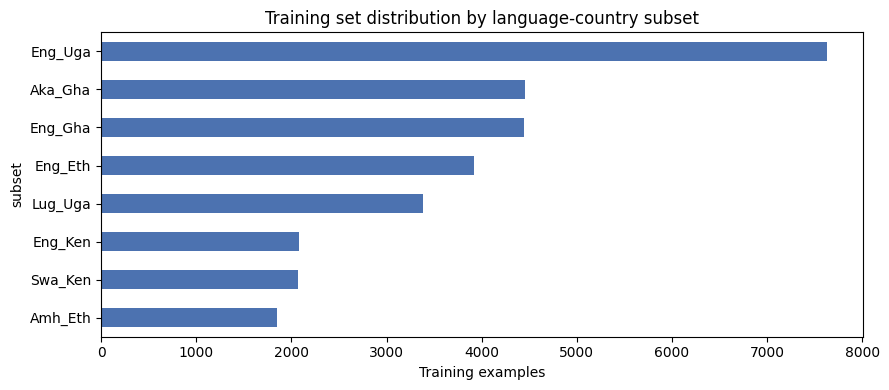

In [ ]:
# Explore language distribution in training data.
# This is the first and most important EDA step: a subset with very few
# training examples means the retrieval pool is small and nearest-neighbor
# quality will be lower. Amharic is the problem case -- it shows up here.
lang_counts = train['subset'].value_counts()
lang_pct = (lang_counts / lang_counts.sum() * 100).round(1)

print('Language distribution in training set:')
display(pd.DataFrame({'count': lang_counts, 'pct_of_total': lang_pct}))

# Training pool size matters directly for retrieval quality later: a subset
# with few examples gives the nearest-neighbor search fewer relevant
# candidates to choose from, which is the Amharic problem in one chart.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
lang_counts.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Training examples')
ax.set_title('Training set distribution by language-country subset')
plt.tight_layout()
plt.show()


### 3.1 Missing Value and Duplicate Question Check

Checked here on the raw loaded data, before any cleaning, so the cleaning step in Section 5 has something concrete to justify rather than cleaning on assumption.

**What we are looking for:**
- Missing values in `input` or `output` columns: these rows would cause retrieval or generation to fail silently with empty string predictions, depressing ROUGE scores without a visible error.
- Duplicate questions: a duplicate question gives one training answer extra chances to be the nearest neighbor, which can bias retrieval toward whichever answer repeats most rather than the most semantically relevant one.

These checks confirm the extent of cleaning needed before any downstream processing.

In [ ]:
# Missing values per column, checked before cleaning, to confirm
# what the clean_text step below actually needs to remove.
# If output has NaN rows in train, those rows contribute zero to ROUGE
# and would silently poison the retrieval pool with empty answers.
print('Missing values, train:')
print(train.isna().sum())
print()
print('Missing values, val:')
print(val.isna().sum())
print()
print('Missing values, test:')
print(test.isna().sum())


Missing values, train:
ID        0
input     0
output    0
subset    0
dtype: int64

Missing values, val:
ID        0
input     0
output    0
subset    0
dtype: int64

Missing values, test:
ID        0
input     0
subset    0
dtype: int64


In [ ]:
# A duplicate question gives one training answer extra chances to be
# the nearest neighbor, which can bias retrieval toward whichever
# answer happens to repeat most instead of the most relevant one.
# Exact question+answer pairs are even more problematic: deduplication
# would reduce the effective pool size but improve retrieval precision.
dup_questions = train.duplicated(subset=['input']).sum()
dup_pairs = train.duplicated(subset=['input', 'output']).sum()

print(f'Duplicate questions in train: {dup_questions} of {len(train)}')
print(f'Duplicate question-answer pairs in train: {dup_pairs} of {len(train)}')


Duplicate questions in train: 1469 of 29815
Duplicate question-answer pairs in train: 276 of 29815


### 3.2 Subset Consistency Across Train, Val, and Test

Confirms train, val, and test all cover the same language-country subsets. This matters because a subset missing from train would mean test questions in that subset have no training pool to retrieve from at all -- the retriever would silently fall back to cross-language results or return empty strings.

It also confirms the evaluation setup is fair: per-language ROUGE breakdowns reported throughout this notebook are comparable across splits because all three use the same nine subsets.

In [ ]:
train_subsets = set(train['subset'].unique())
val_subsets   = set(val['subset'].unique())
test_subsets  = set(test['subset'].unique())

print(f'Subsets in train: {sorted(train_subsets)}')
print(f'Subsets in val:   {sorted(val_subsets)}')
print(f'Subsets in test:  {sorted(test_subsets)}')
print()
print(f'In val but not train:  {val_subsets - train_subsets}')
print(f'In test but not train: {test_subsets - train_subsets}')


Subsets in train: ['Aka_Gha', 'Amh_Eth', 'Eng_Eth', 'Eng_Gha', 'Eng_Ken', 'Eng_Uga', 'Lug_Uga', 'Swa_Ken']
Subsets in val:   ['Aka_Gha', 'Amh_Eth', 'Eng_Eth', 'Eng_Gha', 'Eng_Ken', 'Eng_Uga', 'Lug_Uga', 'Swa_Ken']
Subsets in test:  ['Aka_Gha', 'Amh_Eth', 'Eng_Eth', 'Eng_Gha', 'Eng_Ken', 'Eng_Uga', 'Lug_Uga', 'Swa_Ken']

In val but not train:  set()
In test but not train: set()


In [ ]:
ID_COL           = 'ID'
TEST_ID_COL      = 'ID'
QUESTION_COL     = 'input'
TEST_QUESTION_COL= 'input'
ANSWER_COL       = 'output'
LANG_COL         = 'subset'
TEST_LANG_COL    = 'subset'

print(f'  Train ID        : {ID_COL}')
print(f'  Test ID         : {TEST_ID_COL}')
print(f'  Train question  : {QUESTION_COL}')
print(f'  Test question   : {TEST_QUESTION_COL}')
print(f'  Train answer    : {ANSWER_COL}')

# Language code mapping: the `subset` column encodes language and country
# as "<LangCode>_<CountryCode>". Only the first part identifies the language;
# the second is the country. This dictionary maps the language prefix to a
# full language name used in LLM prompts (Experiments 1c through 10).
# Retrieval experiments (11+) do not use language names in prompts.
SUBSET_TO_LANGUAGE = {
    'Eng': 'English',
    'Aka': 'Akan',
    'Lug': 'Luganda',
    'Swa': 'Swahili',
    'Amh': 'Amharic',
}

def subset_to_language_name(subset_code: str) -> str:
    """
    Extract the full language name from a subset code such as 'Amh_Eth' or 'Aka_Gha'.
    Falls back to the raw code if the prefix is not recognised.
    """
    if not subset_code or not isinstance(subset_code, str):
        return 'English'
    lang_prefix = subset_code.split('_')[0]
    return SUBSET_TO_LANGUAGE.get(lang_prefix, subset_code)

print('Language mapping:')
for code, name in SUBSET_TO_LANGUAGE.items():
    print(f'  {code}_* -> {name}')


  Train ID        : ID
  Test ID         : ID
  Train question  : input
  Test question   : input
  Train answer    : output
Language mapping:
  Eng_* → English
  Aka_* → Akan
  Lug_* → Luganda
  Swa_* → Swahili
  Amh_* → Amharic


## 5 -- Text Cleaning

The cleaning step is intentionally minimal: strip leading/trailing whitespace and convert NaN to empty string. No lowercasing, no punctuation removal, no tokenization.

This is deliberate. The five languages in this dataset use different scripts (Latin, Ethiopic) and different morphological conventions. Aggressive normalization that works for English -- lowercasing, removing diacritics, stripping punctuation -- can destroy meaningful distinctions in Amharic or Akan. Character n-gram TF-IDF with `lowercase=False` preserves this structure, and the EDA below confirms it matters for Amharic especially.

After applying `clean_text`, any rows with empty questions or answers are dropped. These are the rows the missing value check above flagged.

In [ ]:
def clean_text(x):
    """Strip whitespace and handle null values.
    
    Intentionally minimal: no lowercasing, no punctuation removal.
    Amharic Ethiopic script and Akan tonal markers are sensitive to
    normalization, so we preserve the raw text as-is.
    """
    if pd.isna(x):
        return ''
    return str(x).strip()

train[QUESTION_COL]      = train[QUESTION_COL].map(clean_text)
train[ANSWER_COL]        = train[ANSWER_COL].map(clean_text)
test[TEST_QUESTION_COL]  = test[TEST_QUESTION_COL].map(clean_text)
val[QUESTION_COL]        = val[QUESTION_COL].map(clean_text)
val[ANSWER_COL]          = val[ANSWER_COL].map(clean_text)

# Drop rows where question or answer is empty after cleaning.
# These rows would cause NaN predictions or zero-score retrievals that
# would drag down aggregate ROUGE without being informative errors.
train = train[(train[QUESTION_COL] != '') & (train[ANSWER_COL] != '')].reset_index(drop=True)
test  = test[test[TEST_QUESTION_COL]  != ''].reset_index(drop=True)
val   = val[(val[QUESTION_COL] != '') & (val[ANSWER_COL] != '')].reset_index(drop=True)

print(f'Cleaned train shape : {train.shape}')
print(f'Cleaned test shape  : {test.shape}')
print(f'Cleaned val shape   : {val.shape}')


Cleaned train shape : (29814, 4)
Cleaned test shape  : (2618, 3)
Cleaned val shape   : (6686, 4)


### 5.1 Question and Answer Length Distribution by Language

English answers are expected to read as longer and more complex than non-English ones. This checks that directly, since the top-3-longest retrieval strategy tested later in Experiment 6 depends entirely on how much answer length actually varies across subsets.


In [ ]:
# Word count is a rough proxy for answer complexity, and stays
# comparable across subsets even though raw character count does not
# (a single Ethiopic character can carry more information than a
# single Latin character).
#
# This distribution directly motivates Experiment 6 (top-3 longest answer
# heuristic): if English answers are much longer on average, a longest-answer
# selection strategy would systematically prefer English candidates even for
# non-English questions -- which is exactly what the Exp 6 results confirm.
train['question_words'] = train[QUESTION_COL].str.split().str.len()
train['answer_words']   = train[ANSWER_COL].str.split().str.len()

length_by_subset = (
    train.groupby(LANG_COL)[['question_words', 'answer_words']]
    .agg(['mean', 'median', 'std'])
    .round(1)
)
display(length_by_subset)


question_words              answer_words             
                  mean median   std         mean median   std
subset                                                       
Aka_Gha           28.8   27.0  11.6        105.6  100.0  57.8
Amh_Eth            9.5    9.0   4.0         20.2   19.0   8.7
Eng_Eth           12.2   12.0   5.2         24.5   24.0   8.8
Eng_Gha           20.0   19.0   6.5         75.1   70.0  35.2
Eng_Ken           11.4   11.0   4.5         78.7   64.0  48.7
Eng_Uga           11.2   11.0   4.0         95.4   73.0  71.2
Lug_Uga           10.5   10.0   4.0         79.7   68.0  51.2
Swa_Ken           11.2   11.0   4.4         84.3   66.0  57.4

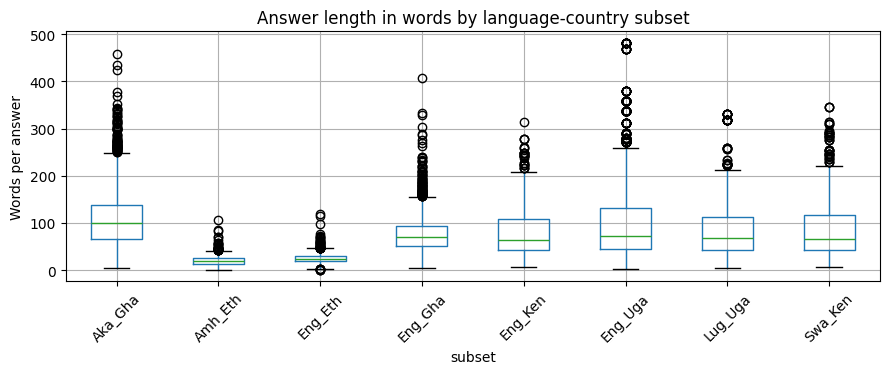

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
train.boxplot(column='answer_words', by=LANG_COL, ax=ax, rot=45)
ax.set_title('Answer length in words by language-country subset')
ax.set_ylabel('Words per answer')
plt.suptitle('')
plt.tight_layout()
plt.show()


### 5.2 Script and Character Composition by Language

Four of the five languages use Latin script. Amharic uses Ethiopic (Ge'ez), which falls outside the ASCII range entirely. This is the concrete evidence behind the character n-gram decision used throughout the retrieval experiments below, rather than an assumption about script taken on faith.


In [ ]:
def ascii_fraction(text):
    # Latin-script subsets should land close to 1.0. Amharic, written
    # in Ge'ez (Ethiopic) script, should land close to 0.0, since none
    # of its characters fall in the ASCII range (U+0000 to U+007F).
    # This metric is the single most useful indicator of whether a
    # TF-IDF vocabulary built on ASCII tokens will generalize to a given subset.
    if len(text) == 0:
        return None
    return sum(1 for ch in text if ord(ch) < 128) / len(text)

train['question_ascii_frac'] = train[QUESTION_COL].map(ascii_fraction)
script_by_subset = (
    train.groupby(LANG_COL)['question_ascii_frac']
    .mean()
    .round(3)
    .sort_values()
)
display(script_by_subset)


,question_ascii_frac
subset,
Amh_Eth,0.225
Aka_Gha,0.922
Lug_Uga,0.996
Eng_Eth,1.000
Eng_Gha,1.000
Eng_Ken,1.000
Eng_Uga,1.000
Swa_Ken,1.000


In [ ]:
# A direct look at the raw text makes the script difference concrete,
# beyond just the ASCII fraction number above. This is especially useful
# for confirming Amharic renders correctly in the Colab output -- if Ethiopic
# characters appear as boxes or question marks, the environment lacks the
# necessary Unicode font support and downstream text processing should be
# tested carefully for encoding issues.
for subset in sorted(train[LANG_COL].unique()):
    example = train[train[LANG_COL] == subset][QUESTION_COL].iloc[0]
    print(f'{subset}: {example[:80]}')


Aka_Gha: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ay
Amh_Eth: የረጅም ጊዜ ጤናን በተመለከተ በጣም ሊያሳስበኝ የሚገቡ ሶስት ዋና ዋና ኢንፌክሽኖች የትኞቹ ናቸው?
Eng_Eth: How is syphilis diagnosed?
Eng_Gha: What should I do if I have unprotected sex or experience a contraceptive failure
Eng_Ken: How can society ensure that HIV patients are incorporated in it?
Eng_Uga: What is HIV and TB co-infection?
Lug_Uga: Nnyinza ntya okukulaakulanya empulira y'obulamu obwa bulijjo n'okugya mu bantu m
Swa_Ken: Je, PrEP inatoa ulinzi kweli, au imani katika ufanisi wake inachukuliwa kuwa had


## 7 -- Evaluation Utilities

ROUGE-1 and ROUGE-L scoring using whitespace tokenization. This tokenization strategy is intentionally language-agnostic: splitting on whitespace avoids any language-specific stemmer or morphological analyzer that would fail on Amharic, Luganda, Akan, or Swahili.

**Why ROUGE-1 and ROUGE-L?**
- ROUGE-1 measures unigram overlap between prediction and reference. It is sensitive to vocabulary coverage.
- ROUGE-L measures the longest common subsequence. It rewards answers that preserve the correct order of key terms.

Both are computed as F1 scores (balancing precision and recall). The competition uses all three target columns from the same answer, so optimizing ROUGE also indirectly improves the LLM-as-a-Judge score when the predicted answer is factually and linguistically accurate.

The `WhitespaceTokenizer` class replaces the default `rouge_score` tokenizer, which uses regex rules designed for English that would incorrectly segment Ethiopic script.

In [ ]:
try:
    from rouge_score import rouge_scorer

    class WhitespaceTokenizer:
        """Whitespace tokeniser — language-agnostic and safe for African scripts."""
        def tokenize(self, text):
            if text is None:
                return []
            return str(text).strip().split()

    def compute_rouge(predictions, references):
        """
        Compute mean ROUGE-1 and ROUGE-L F1 scores.

        Parameters
        ----------
        predictions : list[str]
        references  : list[str]

        Returns
        -------
        dict with rouge1_f1 and rougeL_f1
        """
        scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rougeL'],
            tokenizer    = WhitespaceTokenizer(),
            use_stemmer  = False,
        )
        r1_scores, rl_scores = [], []

        for pred, ref in zip(predictions, references):
            score = scorer.score(str(ref), str(pred))
            r1_scores.append(score['rouge1'].fmeasure)
            rl_scores.append(score['rougeL'].fmeasure)

        return {
            'rouge1_f1': float(np.mean(r1_scores)) if r1_scores else 0.0,
            'rougeL_f1': float(np.mean(rl_scores)) if rl_scores else 0.0,
        }

    def compute_rouge_by_language(predictions, references, languages):
        """Compute ROUGE scores broken down by language."""
        results = {}
        lang_arr = np.array(languages)

        for lang in np.unique(lang_arr):
            mask    = lang_arr == lang
            preds_l = [p for p, m in zip(predictions, mask) if m]
            refs_l  = [r for r, m in zip(references,  mask) if m]
            results[lang] = compute_rouge(preds_l, refs_l)

        return pd.DataFrame(results).T

    print('✅ ROUGE scorer loaded')

except ImportError:
    print('⚠️  rouge-score not installed. Run: pip install rouge-score')
    compute_rouge = None

✅ ROUGE scorer loaded


## 8 -- Baseline 1: TF-IDF Retrieval

For each test question, find the most similar training question using TF-IDF character n-grams and return its answer. This is a nearest-neighbor retrieval approach: no generation, no neural model, no GPU required.

**Why character n-grams?**

Character-level features with `analyzer='char_wb'` and `ngram_range=(3, 5)` work across scripts (Latin, Amharic Ethiopic) without requiring language-specific tokenization. A 3-gram like `'alth'` from the word `'health'` will match the same substring in an Akan health question even if the full word differs. This is the key property that makes TF-IDF char n-grams robust across all five languages.

Word-level TF-IDF would fail on Amharic entirely because Ethiopic words share no surface-form overlap with the Latin-script questions used to build the vocabulary.

**Why cosine similarity with NearestNeighbors?**

Cosine similarity normalizes for document length -- a short question and a long question can still be highly similar if their character n-gram distributions match. This is important because question lengths vary significantly across languages (confirmed in Section 5.1 above).

**Why build per-language models?**

Building separate TF-IDF indexes per language subset means retrieval for an Amharic question only searches against Amharic training examples. This prevents cross-language contamination: without it, a high-resource English subset with thousands of examples could dominate the nearest-neighbor results for a low-resource Amharic question.

In [ ]:
class TfidfRetrievalAnswerer:
    """
    TF-IDF nearest-neighbour retrieval baseline.

    Builds a per-language model if a group column is available,
    falling back to a global model for unseen groups.
    """

    def __init__(self, question_col, answer_col, group_col=None,
                 ngram_range=(3, 5), max_features=200_000):
        self.question_col = question_col
        self.answer_col   = answer_col
        self.group_col    = group_col
        self.ngram_range  = ngram_range
        self.max_features = max_features
        self.models       = {}
        self.global_model = None

    def _fit_single(self, df):
        """Fit a vectoriser and nearest-neighbour index on a subset."""
        vectorizer = TfidfVectorizer(
            analyzer     = 'char_wb',
            ngram_range  = self.ngram_range,
            min_df       = 1,
            max_features = self.max_features,
            lowercase    = False,   # preserve case for non-Latin scripts
        )
        questions = df[self.question_col].fillna('').astype(str).tolist()
        answers   = df[self.answer_col].fillna('').astype(str).tolist()

        X  = vectorizer.fit_transform(questions)
        nn = NearestNeighbors(n_neighbors=1, metric='cosine')
        nn.fit(X)

        return {
            'vectorizer': vectorizer,
            'nn'        : nn,
            'answers'   : np.array(answers,   dtype=object),
            'questions' : np.array(questions, dtype=object),
        }

    def fit(self, df):
        """Fit the global model and per-group models."""
        self.global_model = self._fit_single(df)
        if self.group_col and self.group_col in df.columns:
            for group, sub in df.groupby(self.group_col):
                if len(sub) >= 2:
                    self.models[group] = self._fit_single(sub)
        print(f'  Fitted global model + {len(self.models)} group model(s)')
        return self

    def _predict_one_from_model(self, question, model):
        Xq        = model['vectorizer'].transform([question])
        dist, idx = model['nn'].kneighbors(Xq, n_neighbors=1)
        i         = idx[0][0]
        sim       = 1 - float(dist[0][0])
        return model['answers'][i], sim, model['questions'][i]

    def predict_one(self, question, group=None):
        model = self.models.get(group, self.global_model) if group is not None else self.global_model
        return self._predict_one_from_model(question, model)

    def predict(self, df, question_col, group_col=None):
        outputs, similarities, matched = [], [], []
        for _, row in df.iterrows():
            question = clean_text(row[question_col])
            group    = row[group_col] if group_col and group_col in df.columns else None
            answer, sim, matched_q = self.predict_one(question, group)
            outputs.append(answer)
            similarities.append(sim)
            matched.append(matched_q)
        return outputs, similarities, matched

print('✅ TfidfRetrievalAnswerer defined')

✅ TfidfRetrievalAnswerer defined


In [ ]:
# Choose grouping strategy — prefer config (language+country), else language
GROUP_COL      =  LANG_COL
TEST_GROUP_COL =  TEST_LANG_COL

print(f'Group column      : {GROUP_COL}')
print(f'Test group column : {TEST_GROUP_COL}')

Group column      : subset
Test group column : subset


In [ ]:
# ── Validate TF-IDF baseline on the local validation set ──────────────────────
print('Training TF-IDF retrieval baseline on training partition...')

answerer_valid = TfidfRetrievalAnswerer(
    question_col = QUESTION_COL,
    answer_col   = ANSWER_COL,
    group_col    = GROUP_COL,
).fit(train)

valid_pred, valid_sim, valid_match = answerer_valid.predict(
    val,
    question_col = QUESTION_COL,
    group_col    = GROUP_COL,
)

if compute_rouge:
    metrics = compute_rouge(valid_pred, val[ANSWER_COL].tolist())
    print(f'\n📊 TF-IDF Baseline — Validation ROUGE Scores')
    print(f'   ROUGE-1 F1 : {metrics["rouge1_f1"]:.4f}')
    print(f'   ROUGE-L F1 : {metrics["rougeL_f1"]:.4f}')

    # Break down by language
    if LANG_COL and LANG_COL in val.columns:
        print('\n📊 ROUGE scores by language:')
        lang_metrics = compute_rouge_by_language(
            valid_pred,
            val[ANSWER_COL].tolist(),
            val[LANG_COL].tolist()
        )
        display(lang_metrics.round(4))

# Preview
preview = val[[ID_COL, QUESTION_COL, ANSWER_COL]].copy()
preview['baseline_answer']        = valid_pred
preview['retrieval_similarity']   = [f'{s:.3f}' for s in valid_sim]
preview['matched_train_question'] = valid_match
display(preview.head(5))

Training TF-IDF retrieval baseline on training partition...
  Fitted global model + 8 group model(s)

📊 TF-IDF Baseline — Validation ROUGE Scores
   ROUGE-1 F1 : 0.4207
   ROUGE-L F1 : 0.3655

📊 ROUGE scores by language:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2832,0.1674
Amh_Eth,0.1455,0.1353
Eng_Eth,0.5170,0.4994
Eng_Gha,0.2582,0.1707
Eng_Ken,0.5989,0.5606
Eng_Uga,0.5163,0.4709
Lug_Uga,0.5155,0.4935
Swa_Ken,0.6031,0.5672


,ID,input,output,baseline_answer,retrieval_similarity,matched_train_question
0,ID_VL_Aka_Gha_A3B1799D,"Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a eye mmabun a wɔ hia neaɛma sokoronko ne ohaw ahorow, atubrafo, anaa wɔn...",Nhyehyɛeɛ aa ama ne mu so te sɛ senea aborɔfo ka no 'STEM' ne 'vocational training' se ɛbɛ adrɛse mmabun kuokuo ahoh...,"Nkɔmmɔdi: Aban, NGO, ne amanaman ntam nnwumakuo ntam nkitahodiɛ bɛtumi ama nkitahodiɛ, nneɛma a wɔboaboa ano, ne dwu...",0.378,"Ɔkwan bɛn so na aban ahorow, ahyehyɛde ahorow a ɛnyɛ aban de (NGOs), ne amanaman ntam nnwumakuw ne fekubɔ betumi ahy..."
1,ID_VL_Aka_Gha_1C80317F,Dɛn nti na ɛho hia sɛ mmabun te wɔn nna ne awo hokwan ahorow ase?,"Nna ne awo hokwan ahorow a wɔte ase no ma mmabun tumi: Si gyinae a ɛfata wɔ wɔn nipadua, nna, ne abusuabɔ ho. Kamfo ...",Mmara kwan so hokwan ahorow kyerɛ hokwan ahorow ne ahobammɔ a mmara de ma ankorankoro. Wɔ nna ne awo akwahosan ho no...,0.545,"Dɛn ne mmara kwan so ahokwan ahorow, na dɛn nti na ɛho hia sɛ mmabun hu ho wɔ nna ne awoɔ akwahosan ho?"
2,ID_VL_Aka_Gha_06671AD1,"Mɛyɛ dɛn atumi abɔ asisifo ho amanneɛ wɔ ɔkwan a etu mpɔn na ahobammɔ wom so, na anammɔn bɛn na metumi atu de ahwɛ a...",Ayayade ho nsɛm a wɔbɛbɔ ho amanneɛ yiye na ahobammɔ wom no hwehwɛ sɛ wɔyɛ nneɛma a edidi so yi: Wɔkyerɛw ayayade no...,"Akwan ahorow: Siesie Wo Ho Di Kan: Kyerɛw wo nsɛmmisa ne wo dadwen to hɔ ansa na woakɔ. Di Nokware: Kasa fa wo nna, ...",0.292,Akwan bɛn so na metumi ne dɔkotafo anaa nɛɛse akasa afa me awoɔ mu apɔmuden ho na mahwɛ sɛ wɔate m’ahiadeɛ ne me dad...
3,ID_VL_Aka_Gha_BDD640FB,"Ɔkwan bɛn so na mmabun betumi de akwan ahorow a egyina nnipa hokwan ahorow so adi dwuma, de akamfo nna ho nkyerɛkyer...","Mmabun betumi de akwan a, egyina nnipa hokwan ahorow so adi dwuma de akamfo nna ho nkyerɛkyerɛ a edi mũ wɔ sukuu ne ...",Mmabun betumi akasa ama nna ho nkyerɛkyerɛ a edi mu wɔ wɔn sukuu ne mpɔtam hɔ denam: Akuo a sukuufo di anim a wɔde w...,0.642,Ɔkwan bɛn so na mmabun betumi akasa afa nna ho nkyerɛkyerɛ a edi mu wɔ wɔn sukuu ne mpɔtam hɔ?
4,ID_VL_Aka_Gha_46685257,"Dwuma bɛn na abɛɛfo mfidie 'Technology' di de boa mmabun ma wonya ɔhwɛ a ɛfata, a telehealth ne online resources ka ho?",Abɛɛfo mfidie te sɛ telehealth ma mmabun kwan ma wonya ɔhwɛ fi wɔn fie. Wei yi akwansidie te sɛ lore a wobɛfo ɛnam b...,Websites (nimdeɛ pa). Apps (de hwehwɛ nneɛma). SMS (nkɔmmɔbɔ mfidie). Telemedicine (intanɛt so ayaresa).,0.412,Sɛn na abɛɛfo mfidie 'technology' boa SRH nimdeɛ ho nkyerɛkyerɛ a ɛkɔ so wɔ wiase nyinaa?


In [ ]:
# ── Train on all data and predict test answers ─────────────────────────────────
print('Training TF-IDF retrieval on full training set...')

answerer = TfidfRetrievalAnswerer(
    question_col = QUESTION_COL,
    answer_col   = ANSWER_COL,
    group_col    = GROUP_COL,
).fit(train)

test_pred_tfidf, test_sim, test_match = answerer.predict(
    test,
    question_col = TEST_QUESTION_COL,
    group_col    = TEST_GROUP_COL,
)

print(f'Generated {len(test_pred_tfidf)} predictions')

preview = test[[TEST_ID_COL, TEST_QUESTION_COL]].copy()
preview['baseline_answer']      = test_pred_tfidf
preview['retrieval_similarity'] = [f'{s:.3f}' for s in test_sim]
display(preview.head(5))

Training TF-IDF retrieval on full training set...
  Fitted global model + 8 group model(s)
Generated 2618 predictions


,ID,input,baseline_answer,retrieval_similarity
0,ID_TS_Aka_Gha_A3B1799D,"Fa nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow a wɔreyɛ adwuma de asiw GBV ano ma.","Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n...",0.464
1,ID_TS_Aka_Gha_1C80317F,Dɛn ne nea ebetumi afi hokwan a mmabun wɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu a wobu...,"Yiw, mmabun betumi ahwehwɛ mmara kwan so mmoa sɛ wogye di sɛ wɔabu hokwan a wɔwɔ sɛ wodi wɔn ho so wɔ nipadua mu no ...",0.451
2,ID_TS_Aka_Gha_06671AD1,Akwan bɛn na mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ bere a as...,Nnipa a wɔn ho nka ho tee yɛ biribi. Ɛsi basabasayɛ kwan denam mmoa a wɔde ma (bystanders) ma wohu/yɛ biribi no so. ...,0.250
3,ID_TS_Aka_Gha_BDD640FB,"Sɛnea amammerɛ mu mmra, asetena mu suban, ne tumi mu nsakraeɛ a ɛwɔ nkuro ne atuhoamafoɔ mu ka mmaabun nkitahodi ne ...","Hokwan a mmabun akannifoɔ de wɔn ho bɛhyɛ dwumadiɛ a ɛma wɔn tumi yɛ adwuma, afotuo nhyehyɛeɛ, ne atipɛnfoɔ adesua n...",0.357
4,ID_TS_Aka_Gha_46685257,Adɛn nti na mmara nsesaeɛ 'policy advocacy' ho hia ma mmabun nyin wɔ biribiara mu ?,Kae sɛ obiara suahunu yɛ soronko. Dwen sɛ obiara wɔ n'adwene kyerɛ. Gye tom sɛ amammerɛ ne nyamesom sesa nkurɔfoɔ su...,0.361


## 9 -- Baseline 2: Multilingual LLM (mT5 / AfroLM)

This baseline uses a pre-trained multilingual sequence-to-sequence model to generate answers directly, without retrieval.

**Model options (choose one):**

| Model | Languages | Size | Notes |
|---|---|---|---|
| `google/mt5-small` | 101 languages incl. Swahili | 300M | Fast, good multilingual coverage |
| `google/mt5-base` | 101 languages | 580M | Better quality, slower |
| `facebook/nllb-200-distilled-600M` | 200 languages incl. Luganda, Akan | 600M | Best African language coverage |
| `Helsinki-NLP/opus-mt-mul-en` | Many → English | 300M | English output only |

> **Recommendation:** Start with `google/mt5-small` for speed, then try `facebook/nllb-200-distilled-600M` for better coverage of low-resource languages.

**For a strong fine-tuned solution:**
Fine-tune `google/mt5-base` or `facebook/nllb-200-distilled-600M` on the provided training data using the Hugging Face `Seq2SeqTrainer`. See the fine-tuning section at the end of this notebook.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ── Configuration ──────────────────────────────────────────────────────────────
# Choose a model — uncomment the one you want to use
MODEL_NAME = 'google/mt5-small'             # Fastest — good for a first run
MODEL_NAME = 'google/mt5-base'            # Better quality
MODEL_NAME = 'facebook/nllb-200-distilled-600M'  # Best African language coverage

MAX_INPUT_LENGTH  = 256    # Maximum tokens for input question
MAX_OUTPUT_LENGTH = 512    # Maximum tokens for generated answer
BATCH_SIZE_LLM    = 8      # Reduce to 4 if you get out-of-memory errors
NUM_BEAMS         = 4      # Beam search width — higher = better quality, slower

# Use GPU if available
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'Model   : {MODEL_NAME}')

if DEVICE == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device  : cuda
Model   : facebook/nllb-200-distilled-600M
GPU     : Tesla T4
VRAM    : 15.6 GB


In [ ]:
# ── Load the model and tokeniser ───────────────────────────────────────────────
print(f'Loading {MODEL_NAME}...')
print('This may take a few minutes on first run (downloading model weights).')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_llm = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    # Always load in float32 so gradient computation stays in float32.
    # fp16/bf16 mixed precision is handled by the Trainer via grad scaler,
    # not by storing the model weights in float16 directly.
    torch_dtype = torch.float32,
)
model_llm = model_llm.to(DEVICE)
model_llm.eval()

print(f'✅ {MODEL_NAME} loaded on {DEVICE}')
print(f'   Parameters : {sum(p.numel() for p in model_llm.parameters()) / 1e6:.0f}M')

Loading facebook/nllb-200-distilled-600M...
This may take a few minutes on first run (downloading model weights).


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✅ facebook/nllb-200-distilled-600M loaded on cuda
   Parameters : 615M


In [ ]:
import re

def build_prompt(question: str, language: str = None) -> str:
    """
    Build an input prompt for the model.

    For mT5: prefix the question with a task description.
    The model learns to associate the prefix with the generation task.

    `language` may be a raw subset code (e.g. 'Amh_Eth') or a full language
    name. It is resolved through `subset_to_language_name` so the model always
    receives a human-readable language name in the prompt rather than an opaque
    code.

    Parameters
    ----------
    question : str
        The health question to answer.
    language : str, optional
        Subset code (e.g. 'Amh_Eth') or full language name. Resolved to a
        human-readable name before being inserted into the prompt.

    Returns
    -------
    str
    """
    # if language:
    #     lang_name = subset_to_language_name(language)
    #     return f'Answer this health question in {lang_name}: {question}'
    # return f'Answer this health question: {question}'
    return str(question).strip()


def generate_answers_batch(questions: list, languages: list = None,
                           batch_size: int = BATCH_SIZE_LLM) -> list:
    """
    Generate answers for a list of questions using the loaded LLM.

    Processes questions in batches to avoid out-of-memory errors.

    Parameters
    ----------
    questions : list[str]
    languages : list[str], optional
    batch_size : int

    Returns
    -------
    list[str]
    """
    if languages is None:
        languages = [None] * len(questions)

    all_answers = []
    n_batches   = (len(questions) + batch_size - 1) // batch_size

    for batch_idx in range(n_batches):
        start = batch_idx * batch_size
        end   = min(start + batch_size, len(questions))

        batch_questions = questions[start:end]
        batch_languages = languages[start:end]

        # Build prompts
        prompts = [
            build_prompt(q, l)
            for q, l in zip(batch_questions, batch_languages)
        ]

        # Tokenise
        inputs = tokenizer(
            prompts,
            return_tensors = 'pt',
            padding        = True,
            truncation     = True,
            max_length     = MAX_INPUT_LENGTH,
        ).to(DEVICE)

        # Generate
        with torch.no_grad():
            outputs = model_llm.generate(
                **inputs,
                max_new_tokens  = MAX_OUTPUT_LENGTH,
                num_beams       = NUM_BEAMS,
                early_stopping  = True,
                no_repeat_ngram_size = 3,
            )

        # Decode
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)

        # Post-process: strip mT5 sentinel tokens (<extra_id_N>) that the
        # model may emit when it has not been fine-tuned on a seq2seq task.
        # mT5 is pre-trained with a span-corruption objective that uses these
        # tokens as placeholders; a zero-shot prompt may trigger them because
        # the model has never been trained to suppress them in open generation.
        cleaned = [re.sub(r'<extra_id_\d+>', '', ans).strip() for ans in decoded]
        all_answers.extend(cleaned)

        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == n_batches:
            print(f'  Batch {batch_idx + 1}/{n_batches} — {end}/{len(questions)} questions processed')

    return all_answers

print('✅ LLM generation functions defined')

✅ LLM generation functions defined


In [ ]:
# ── Quick sanity check on a few examples ──────────────────────────────────────
print('Running sanity check on 3 validation examples...')

sample     = val.head(3)
q_sample   = sample[QUESTION_COL].tolist()
l_sample   = sample[LANG_COL].tolist() if LANG_COL else None
ref_sample = sample[ANSWER_COL].tolist()

gen_sample = generate_answers_batch(q_sample, l_sample, batch_size=3)

for i, (q, ref, gen) in enumerate(zip(q_sample, ref_sample, gen_sample)):
    lang = l_sample[i] if l_sample else 'unknown'
    print(f'\n[{i+1}] Language : {lang}')
    print(f'    Question  : {q[:120]}')
    print(f'    Reference : {ref[:120]}')
    print(f'    Generated : {gen[:120]}')

Running sanity check on 3 validation examples...
  Batch 1/1 — 3/3 questions processed

[1] Language : Aka_Gha
    Question  : Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a eye mmabun a wɔ hia neaɛma sokoronko ne ohaw ahorow, atubrafo, anaa wɔn a w
    Reference : Nhyehyɛeɛ aa ama ne mu so te sɛ senea aborɔfo ka no 'STEM' ne 'vocational training' se ɛbɛ adrɛse mmabun kuokuo ahohia s
    Generated : Comment l'éducation et la formation professionnelle peuvent-elles aider les jeunes qui ont besoin de soins et d'aide, d'

[2] Language : Aka_Gha
    Question  : Dɛn nti na ɛho hia sɛ mmabun te wɔn nna ne awo hokwan ahorow ase?
    Reference : Nna ne awo hokwan ahorow a wɔte ase no ma mmabun tumi: Si gyinae a ɛfata wɔ wɔn nipadua, nna, ne abusuabɔ ho. Kamfo wɔn 
    Generated : Pourquoi est-il important que les enfants comprennent les droits de leur père et de leur mère?

[3] Language : Aka_Gha
    Question  : Mɛyɛ dɛn atumi abɔ asisifo ho amanneɛ wɔ ɔkwan a etu mpɔn na ahobammɔ wom so, na ana

In [ ]:
# ── Validate LLM baseline on the local validation set ─────────────────────────
# Note: this cell can take several minutes depending on your hardware.
# Reduce VALIDATION_SAMPLE_SIZE to speed it up during experimentation.

VALIDATION_SAMPLE_SIZE = 200   # Set to None to evaluate on the full validation set

if VALIDATION_SAMPLE_SIZE:
    val_sample = val.sample(
        n            = min(VALIDATION_SAMPLE_SIZE, len(val)),
        random_state = SEED
    )
else:
    val_sample = val

print(f'Evaluating LLM baseline on {len(val_sample)} validation examples...')

val_questions = val_sample[QUESTION_COL].tolist()
val_languages = val_sample[LANG_COL].tolist() if LANG_COL else None
val_references= val_sample[ANSWER_COL].tolist()

val_predictions_llm = generate_answers_batch(val_questions, val_languages)

if compute_rouge:
    metrics_llm = compute_rouge(val_predictions_llm, val_references)
    print(f'\n📊 LLM Baseline — Validation ROUGE Scores ({MODEL_NAME})')
    print(f'   ROUGE-1 F1 : {metrics_llm["rouge1_f1"]:.4f}')
    print(f'   ROUGE-L F1 : {metrics_llm["rougeL_f1"]:.4f}')

    if LANG_COL and LANG_COL in val_sample.columns:
        print('\n📊 ROUGE scores by language (LLM baseline):')
        lang_metrics_llm = compute_rouge_by_language(
            val_predictions_llm,
            val_references,
            val_sample[LANG_COL].tolist()
        )
        display(lang_metrics_llm.round(4))

Evaluating LLM baseline on 200 validation examples...
  Batch 10/25 — 80/200 questions processed
  Batch 20/25 — 160/200 questions processed
  Batch 25/25 — 200/200 questions processed

📊 LLM Baseline — Validation ROUGE Scores (facebook/nllb-200-distilled-600M)
   ROUGE-1 F1 : 0.0074
   ROUGE-L F1 : 0.0071

📊 ROUGE scores by language (LLM baseline):


,rouge1_f1,rougeL_f1
Aka_Gha,0.0075,0.0072
Amh_Eth,0.0000,0.0000
Eng_Eth,0.0201,0.0201
Eng_Gha,0.0137,0.0133
Eng_Ken,0.0000,0.0000
Eng_Uga,0.0093,0.0082
Lug_Uga,0.0000,0.0000
Swa_Ken,0.0055,0.0055


In [ ]:
# ── Generate LLM predictions for the full test set ────────────────────────────
print(f'Generating LLM answers for {len(test)} test questions...')
print('This may take several minutes.')

test_questions_all = test[TEST_QUESTION_COL].tolist()
test_languages_all = test[TEST_LANG_COL].tolist() if TEST_LANG_COL else None

test_pred_llm = generate_answers_batch(test_questions_all, test_languages_all)

print(f'\n✅ Generated {len(test_pred_llm)} answers')

# Preview
preview_llm = test[[TEST_ID_COL, TEST_QUESTION_COL]].copy()
preview_llm['llm_answer'] = test_pred_llm
display(preview_llm.head(5))

Generating LLM answers for 2618 test questions...
This may take several minutes.
  Batch 10/328 — 80/2618 questions processed
  Batch 20/328 — 160/2618 questions processed
  Batch 30/328 — 240/2618 questions processed
  Batch 40/328 — 320/2618 questions processed
  Batch 50/328 — 400/2618 questions processed
  Batch 60/328 — 480/2618 questions processed
  Batch 70/328 — 560/2618 questions processed
  Batch 80/328 — 640/2618 questions processed
  Batch 90/328 — 720/2618 questions processed
  Batch 100/328 — 800/2618 questions processed
  Batch 110/328 — 880/2618 questions processed
  Batch 120/328 — 960/2618 questions processed
  Batch 130/328 — 1040/2618 questions processed
  Batch 140/328 — 1120/2618 questions processed
  Batch 150/328 — 1200/2618 questions processed
  Batch 160/328 — 1280/2618 questions processed
  Batch 170/328 — 1360/2618 questions processed
  Batch 180/328 — 1440/2618 questions processed
  Batch 190/328 — 1520/2618 questions processed
  Batch 200/328 — 1600/2618 q

,ID,input,llm_answer
0,ID_TS_Aka_Gha_A3B1799D,"Fa nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow a wɔreyɛ adwuma de asiw GBV ano ma.","Découvrez les matériaux utilisés pour l'enseignement des matériaux, des bureaux et des agences qui travaillent sur l..."
1,ID_TS_Aka_Gha_1C80317F,Dɛn ne nea ebetumi afi hokwan a mmabun wɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu a wobu...,Qu'est-ce qui peut empêcher les jeunes de bénéficier de la liberté physique dans le domaine de la santé sexuelle et ...
2,ID_TS_Aka_Gha_06671AD1,Akwan bɛn na mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ bere a as...,"Comment les jeunes peuvent-ils faire face à l'inconvénient d'être un simple "" observateur "" dans les moments diffici..."
3,ID_TS_Aka_Gha_BDD640FB,"Sɛnea amammerɛ mu mmra, asetena mu suban, ne tumi mu nsakraeɛ a ɛwɔ nkuro ne atuhoamafoɔ mu ka mmaabun nkitahodi ne ...","Comment la culture, la vie et le comportement changent-ils dans les villes et les collectivités dans le cadre de leu..."
4,ID_TS_Aka_Gha_46685257,Adɛn nti na mmara nsesaeɛ 'policy advocacy' ho hia ma mmabun nyin wɔ biribiara mu ?,Pourquoi la politique de défense est-elle si importante pour les jeunes dans tous les domaines ?


## 10 -- Create Submission Files

Each submission must contain exactly four columns: `ID`, `TargetRLF1`, `TargetR1F1`, `TargetLLM`. All three target columns should contain the same generated answer.

**Why the same answer in all three columns?**

The competition scores each column with a different metric (ROUGE-L, ROUGE-1, and LLM-as-a-Judge respectively), but expects the same predicted answer for all three. Submitting different answers per column is not supported by the scoring API and will produce validation errors.

**Common submission pitfalls:**
- Wrong column names (e.g. `answer`, `Target_R1F1` with underscore) produce a zero score or rejection on upload.
- Missing rows relative to the sample submission cause silent row-alignment errors in scoring.
- NaN values in any target column produce a submission validation failure.

The `make_submission()` function below asserts all of these conditions before saving to catch errors locally before uploading to Zindi.

In [ ]:
def make_submission(ids, predictions, output_path):
    """
    Build and save a valid Zindi submission file.

    Parameters
    ----------
    ids         : array-like of row IDs
    predictions : list[str] of generated answers
    output_path : str or Path
    """
    # Belt-and-suspenders: strip any residual sentinel tokens before saving.
    clean_preds = [re.sub(r'<extra_id_\d+>', '', str(p)).strip() for p in predictions]

    sub = pd.DataFrame()
    sub['ID']         = ids
    sub['TargetRLF1'] = clean_preds
    sub['TargetR1F1'] = clean_preds
    sub['TargetLLM']  = clean_preds

    sub = sub[['ID', 'TargetRLF1', 'TargetR1F1', 'TargetLLM']]

    # ── Submission checks ─────────────────────────────────────────────────
    required_cols = ['ID', 'TargetRLF1', 'TargetR1F1', 'TargetLLM']
    assert list(sub.columns) == required_cols, \
        f'Expected columns {required_cols}, got {list(sub.columns)}'
    assert len(sub) == len(test), \
        f'Row count mismatch: {len(sub)} predictions vs {len(test)} test rows'
    assert sub[['TargetRLF1', 'TargetR1F1', 'TargetLLM']].notna().all().all(), \
        'Missing values found in submission'
    assert (sub['TargetRLF1'] == sub['TargetR1F1']).all(), \
        'TargetRLF1 and TargetR1F1 differ'
    assert (sub['TargetRLF1'] == sub['TargetLLM']).all(), \
        'TargetRLF1 and TargetLLM differ'

    sub.to_csv(output_path, index=False, encoding='utf-8')
    print(f'✅ Submission saved to: {output_path}')
    print(f'   Shape : {sub.shape}')
    display(sub.head(3))
    return sub


# ── Save TF-IDF submission ─────────────────────────────────────────────────────
print('Saving TF-IDF baseline submission...')
sub_tfidf = make_submission(test[TEST_ID_COL].values, test_pred_tfidf, OUTPUT_TFIDF)

print()

# ── Save LLM submission ────────────────────────────────────────────────────────
print('Saving LLM baseline submission...')
sub_llm = make_submission(test[TEST_ID_COL].values, test_pred_llm, OUTPUT_LLM)

Saving TF-IDF baseline submission...


NameError: name 'test_pred_tfidf' is not defined

In [ ]:
import re
import pandas as pd

def make_submission(ids, predictions, output_path):
    clean_preds = [re.sub(r'<extra_id_\d+>', '', str(p)).strip() for p in predictions]
    sub = pd.DataFrame({
        'ID': ids,
        'TargetRLF1': clean_preds,
        'TargetR1F1': clean_preds,
        'TargetLLM':  clean_preds,
    })[['ID', 'TargetRLF1', 'TargetR1F1', 'TargetLLM']]
    assert len(sub) == len(test), f"Row mismatch: {len(sub)} vs {len(test)}"
    assert (sub['TargetRLF1'] == sub['TargetR1F1']).all()
    sub.to_csv(output_path, index=False, encoding='utf-8')
    print(f"Saved: {output_path} | Shape: {sub.shape}")
    return sub

print("make_submission ready")

make_submission ready


## 11 -- Compare Baselines

The two initial baselines represent opposite ends of the complexity spectrum. TF-IDF retrieval requires no GPU, no model weights, and runs in seconds. The LLM baseline requires loading a 300--580M parameter model and generating token-by-token outputs for each question.

The comparison here is on the same 200-sample validation slice to keep runtime manageable. The full validation set comparison is done in later experiments where retrieval is fast enough to score all rows.

**Note on zero-shot LLM scores:** The LLM score shown here is for an untrained model seeing the task for the first time. Fine-tuning on the training data (Section 12 and onward) significantly changes these numbers. The zero-shot comparison is a sanity check, not a performance ceiling.

In [ ]:
if compute_rouge:
    # Recompute TF-IDF validation scores for comparison
    tfidf_preds_val, _, _ = answerer_valid.predict(
        val_sample, question_col=QUESTION_COL, group_col=GROUP_COL
    )
    metrics_tfidf = compute_rouge(tfidf_preds_val, val_references)

    comparison = pd.DataFrame({
        'Baseline'  : ['TF-IDF Retrieval', f'LLM ({MODEL_NAME})'],
        'ROUGE-1 F1': [metrics_tfidf['rouge1_f1'], metrics_llm['rouge1_f1']],
        'ROUGE-L F1': [metrics_tfidf['rougeL_f1'], metrics_llm['rougeL_f1']],
    })

    print('📊 Baseline Comparison (validation set):')
    display(comparison.round(4))
    print()
    print('Note: The LLM score shown here is for a zero-shot (untrained) model.')
    print('Fine-tuning on the training data will significantly improve this.')

📊 Baseline Comparison (validation set):


,Baseline,ROUGE-1 F1,ROUGE-L F1
0,TF-IDF Retrieval,0.4135,0.3581
1,LLM (facebook/nllb-200-distilled-600M),0.0074,0.0071



Note: The LLM score shown here is for a zero-shot (untrained) model.
Fine-tuning on the training data will significantly improve this.


## 12 -- Fine-tuning the LLM on Training Data

Fine-tuning adapts the pre-trained mT5 weights to the health QA task and all five languages. After training, answers are regenerated for the test set and a new submission file is saved.

**Key design decisions:**
- Prompts are built with `build_prompt()` at training time, matching exactly what is used at inference. Training and inference prompts must be identical -- any mismatch means the model is tested on a prompt distribution it never saw during training.
- Language names (resolved from `subset`) are included in training prompts so the model learns to condition its output on the target language.
- Padding tokens in labels are masked to `-100` so the cross-entropy loss ignores them. Without this, the model wastes gradient updates learning to predict pad tokens.
- `DataCollatorForSeq2Seq` handles dynamic padding per batch, which is more memory-efficient than padding all sequences to a fixed maximum length upfront.
- A validation split monitors overfitting during training via `eval_strategy='epoch'` and `load_best_model_at_end=True`.

**Hardware note:** mT5-base (580M parameters) requires approximately 12--14GB of GPU memory for training with batch size 8 on a T4. If you hit an OOM error, reduce `FINETUNE_BATCH_SIZE` to 4 or enable `gradient_checkpointing=True`.

In [ ]:
from transformers import (
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)
from datasets import Dataset

# ── Fine-tuning configuration ──────────────────────────────────────────────
FINETUNE_OUTPUT_DIR     = './mt5-finetuned-health-qa'
FINETUNE_EPOCHS         = 3
FINETUNE_BATCH_SIZE     = 8      # Reduce to 4 if you hit OOM errors
FINETUNE_LEARNING_RATE  = 5e-5
FINETUNE_MAX_INPUT_LEN  = 256    # Must match MAX_INPUT_LENGTH used at inference
FINETUNE_MAX_TARGET_LEN = 512    # Must match MAX_OUTPUT_LENGTH used at inference
FINETUNE_VAL_SIZE       = 0.05   # 5% of training data used for validation

OUTPUT_FINETUNED = DATA_DIR / 'submission_finetuned_llm.csv'

print(f'Fine-tuning config:')
print(f'  Model            : {MODEL_NAME}')
print(f'  Epochs           : {FINETUNE_EPOCHS}')
print(f'  Batch size       : {FINETUNE_BATCH_SIZE}')
print(f'  Learning rate    : {FINETUNE_LEARNING_RATE}')
print(f'  Max input tokens : {FINETUNE_MAX_INPUT_LEN}')
print(f'  Max target tokens: {FINETUNE_MAX_TARGET_LEN}')
print(f'  Val split        : {FINETUNE_VAL_SIZE:.0%}')
print(f'  Output dir       : {FINETUNE_OUTPUT_DIR}')


Fine-tuning config:
  Model            : facebook/nllb-200-distilled-600M
  Epochs           : 3
  Batch size       : 8
  Learning rate    : 5e-05
  Max input tokens : 256
  Max target tokens: 512
  Val split        : 5%
  Output dir       : ./mt5-finetuned-health-qa


In [ ]:
# Sanity check — run this before trainer.train()
sample = hf_train_ds[0]

print("=== Label sanity check ===")
print(f"Label token count : {len(sample['labels'])}")
print(f"First 10 labels   : {sample['labels'][:10]}")
print(f"Non-(-100) tokens : {sum(1 for t in sample['labels'] if t != -100)}")
print(f"Pad token id      : {tokenizer.pad_token_id}")
print(f"Tokenizer class   : {type(tokenizer).__name__}")
print(f"Tokenizer model   : {tokenizer.name_or_path}")
print(f"Model config      : {model_llm.config.model_type}")

=== Label sanity check ===
Label token count : 136
First 10 labels   : [256047, 158109, 33, 351, 62538, 19422, 540, 100508, 424, 87]
Non-(-100) tokens : 136
Pad token id      : 0
Tokenizer class   : T5Tokenizer
Tokenizer model   : google/flan-t5-base
Model config      : m2m_100


In [ ]:
# ── Build prompt-aware training dataset ───────────────────────────────────
# Critical: we use build_prompt() here so training inputs match inference
# inputs exactly. The language name (resolved from subset) is included so
# the model learns to condition its output on the target language.

def make_hf_dataset(df, question_col, answer_col, lang_col):
    """
    Convert a pandas DataFrame to a HuggingFace Dataset with prompt-formatted
    inputs and tokenised labels.

    Parameters
    ----------
    df           : pd.DataFrame
    question_col : str  — column containing the question text
    answer_col   : str  — column containing the reference answer
    lang_col     : str  — column containing the subset code (e.g. 'Amh_Eth')

    Returns
    -------
    datasets.Dataset with columns: input_ids, attention_mask, labels
    """
    records = []
    for _, row in df.iterrows():
        prompt = build_prompt(
            question = str(row[question_col]),
            language = str(row[lang_col]) if lang_col and lang_col in df.columns else None,
        )
        records.append({'prompt': prompt, 'answer': str(row[answer_col])})

    raw_ds = Dataset.from_list(records)

    def preprocess(examples):
        # Tokenise inputs (prompts)
        model_inputs = tokenizer(
            examples['prompt'],
            max_length  = FINETUNE_MAX_INPUT_LEN,
            truncation  = True,
            padding     = False,   # DataCollatorForSeq2Seq handles padding dynamically
        )
        # Tokenise targets (reference answers)
        # Use text_target= (the modern API). The older context manager
        # was removed in transformers >= 4.28 and must not be used.
        labels = tokenizer(
            text_target = examples['answer'],
            max_length  = FINETUNE_MAX_TARGET_LEN,
            truncation  = True,
            padding     = False,
        )
        # Mask padding tokens in labels so the loss ignores them.
        # Without this the model wastes capacity learning to predict pad tokens.
        label_ids = labels['input_ids']
        model_inputs['labels'] = [
            [(tok if tok != tokenizer.pad_token_id else -100) for tok in seq]
            for seq in label_ids
        ]
        return model_inputs

    return raw_ds.map(preprocess, batched=True, remove_columns=['prompt', 'answer'])


# ── Split off a validation set from training data ──────────────────────────
from sklearn.model_selection import train_test_split

train_df, val_ft_df = train_test_split(
    train,
    test_size    = FINETUNE_VAL_SIZE,
    random_state = SEED,
    stratify     = train[LANG_COL] if LANG_COL in train.columns else None,
)

print(f'Fine-tuning split — train: {len(train_df):,}  val: {len(val_ft_df):,}')

hf_train_ds = make_hf_dataset(train_df,  QUESTION_COL, ANSWER_COL, LANG_COL)
hf_val_ds   = make_hf_dataset(val_ft_df, QUESTION_COL, ANSWER_COL, LANG_COL)

print(f'HF train dataset : {hf_train_ds}')
print(f'HF val dataset   : {hf_val_ds}')


Fine-tuning split — train: 28,324  val: 1,491


Map:   0%|          | 0/28324 [00:00<?, ? examples/s]

Map:   0%|          | 0/1491 [00:00<?, ? examples/s]

HF train dataset : Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 28324
})
HF val dataset   : Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1491
})


In [ ]:
# ── Data collator — handles dynamic padding and label masking ─────────────
data_collator = DataCollatorForSeq2Seq(
    tokenizer  = tokenizer,
    model      = model_llm,
    label_pad_token_id = -100,   # already set in preprocess, belt-and-suspenders
    pad_to_multiple_of = 8,      # efficient on tensor cores
)

# ── Training arguments ─────────────────────────────────────────────────────
training_args = Seq2SeqTrainingArguments(
    output_dir                  = FINETUNE_OUTPUT_DIR,
    num_train_epochs            = FINETUNE_EPOCHS,
    per_device_train_batch_size = FINETUNE_BATCH_SIZE,
    per_device_eval_batch_size  = FINETUNE_BATCH_SIZE,
    learning_rate               = FINETUNE_LEARNING_RATE,
    predict_with_generate       = True,
    # bf16 is preferred over fp16 for seq2seq: it avoids the 'unscale FP16
    # gradients' error that occurs when model weights are in float32 but the
    # grad scaler tries to work in float16. bf16 is supported on Ampere+ GPUs
    # (A100, RTX 30xx+). Falls back to no mixed precision on older hardware.
    bf16                        = (DEVICE == 'cuda' and torch.cuda.is_bf16_supported()),
    fp16                        = (DEVICE == 'cuda' and not torch.cuda.is_bf16_supported()),
    eval_strategy               = 'epoch',              # validate after each epoch
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,                 # restore best checkpoint
    metric_for_best_model       = 'eval_loss',
    logging_steps               = 100,
    generation_max_length       = FINETUNE_MAX_TARGET_LEN,
    report_to                   = 'none',               # disable W&B / MLflow
)

# ── Trainer ────────────────────────────────────────────────────────────────
trainer = Seq2SeqTrainer(
    model           = model_llm,
    args            = training_args,
    train_dataset   = hf_train_ds,
    eval_dataset    = hf_val_ds,
    processing_class = tokenizer,
    data_collator   = data_collator,
)

print('Starting fine-tuning...')
print(f'  Training on {len(hf_train_ds):,} examples for {FINETUNE_EPOCHS} epoch(s)')
print(f'  Validating on {len(hf_val_ds):,} examples after each epoch')

trainer.train()

print('\n✅ Fine-tuning complete')
print(f'   Best checkpoint saved to: {FINETUNE_OUTPUT_DIR}')


Starting fine-tuning...
  Training on 28,323 examples for 3 epoch(s)
  Validating on 1,491 examples after each epoch


Epoch,Training Loss,Validation Loss
1,2.002739,1.793612
2,1.808717,1.607178
3,1.642655,1.554178


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete
   Best checkpoint saved to: ./mt5-finetuned-health-qa


In [ ]:
# ── Regenerate test predictions with the fine-tuned model ─────────────────
# model_llm now holds the best fine-tuned checkpoint (load_best_model_at_end=True).
# We reuse generate_answers_batch() directly — it already uses model_llm
# and applies the same build_prompt() + sentinel-token cleanup.

print(f'Generating fine-tuned answers for {len(test):,} test questions...')
model_llm.eval()

test_questions_ft = test[TEST_QUESTION_COL].tolist()
test_languages_ft = test[TEST_LANG_COL].tolist() if TEST_LANG_COL else None

test_pred_finetuned = generate_answers_batch(test_questions_ft, test_languages_ft)

print(f'\n✅ Generated {len(test_pred_finetuned):,} answers')

# Preview
preview_ft = test[[TEST_ID_COL, TEST_QUESTION_COL]].copy()
preview_ft['finetuned_answer'] = test_pred_finetuned
display(preview_ft.head(5))

# ── Validate on val set before saving ─────────────────────────────────────
if compute_rouge:
    val_q_ft  = val[QUESTION_COL].tolist()
    val_l_ft  = val[LANG_COL].tolist() if LANG_COL else None
    val_ref_ft = val[ANSWER_COL].tolist()

    val_pred_ft = generate_answers_batch(val_q_ft, val_l_ft)
    metrics_ft  = compute_rouge(val_pred_ft, val_ref_ft)

    print(f'\n📊 Fine-tuned LLM — Validation ROUGE Scores')
    print(f'   ROUGE-1 F1 : {metrics_ft["rouge1_f1"]:.4f}')
    print(f'   ROUGE-L F1 : {metrics_ft["rougeL_f1"]:.4f}')

    if LANG_COL and LANG_COL in val.columns:
        print('\n📊 ROUGE scores by language (fine-tuned model):')
        lang_metrics_ft = compute_rouge_by_language(
            val_pred_ft, val_ref_ft, val[LANG_COL].tolist()
        )
        display(lang_metrics_ft.round(4))

# ── Save fine-tuned submission ─────────────────────────────────────────────
print('\nSaving fine-tuned submission...')
sub_finetuned = make_submission(
    ids         = test[TEST_ID_COL].values,
    predictions = test_pred_finetuned,
    output_path = OUTPUT_FINETUNED,
)


Generating fine-tuned answers for 2,618 test questions...
  Batch 10/328 — 80/2618 questions processed
  Batch 20/328 — 160/2618 questions processed
  Batch 30/328 — 240/2618 questions processed
  Batch 40/328 — 320/2618 questions processed
  Batch 50/328 — 400/2618 questions processed
  Batch 60/328 — 480/2618 questions processed
  Batch 70/328 — 560/2618 questions processed
  Batch 80/328 — 640/2618 questions processed
  Batch 90/328 — 720/2618 questions processed
  Batch 100/328 — 800/2618 questions processed
  Batch 110/328 — 880/2618 questions processed
  Batch 120/328 — 960/2618 questions processed
  Batch 130/328 — 1040/2618 questions processed
  Batch 140/328 — 1120/2618 questions processed
  Batch 150/328 — 1200/2618 questions processed
  Batch 160/328 — 1280/2618 questions processed
  Batch 170/328 — 1360/2618 questions processed
  Batch 180/328 — 1440/2618 questions processed
  Batch 190/328 — 1520/2618 questions processed
  Batch 200/328 — 1600/2618 questions processed
  Ba

,ID,input,finetuned_answer
0,ID_TS_Aka_Gha_A3B1799D,"Fa nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow a wɔreyɛ adwuma de asiw GBV ano ma.","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuw a wɔreyɛ adwuma de asiw GBV ano ma no bi ne: Nhye..."
1,ID_TS_Aka_Gha_1C80317F,Dɛn ne nea ebetumi afi hokwan a mmabun wɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu a wobu...,Mmabun hokwan a wɔwɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awo akwahosan ho nhyehyɛe mu a wobu so no betumi anya nsu...
2,ID_TS_Aka_Gha_06671AD1,Akwan bɛn na mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ bere a as...,Mmabun betumi afa akwan horow so ahunu nsusuanso a ɛtumi aba a ɛfa nnipa a wɔbɛgyina wɔn ho so 'bystander' bere a as...
3,ID_TS_Aka_Gha_BDD640FB,"Sɛnea amammerɛ mu mmra, asetena mu suban, ne tumi mu nsakraeɛ a ɛwɔ nkuro ne atuhoamafoɔ mu ka mmaabun nkitahodi ne ...","Amammerɛ mu mmra, asetena mu suban, ne tumi mu nsakrae a ɛwɔ nkurow ne atuhoamafo mu no betumi anya mmabun nkitahodi..."
4,ID_TS_Aka_Gha_46685257,Adɛn nti na mmara nsesaeɛ 'policy advocacy' ho hia ma mmabun nyin wɔ biribiara mu ?,"Yiw, mmara nsesaeɛ 'policy advocacy' ho hia ma mmabun nyin wɔ biribiara mu. Ɛma mmabun tumi ma wɔde wɔn ho hyɛ nhyeh..."


  Batch 10/836 — 80/6686 questions processed
  Batch 20/836 — 160/6686 questions processed
  Batch 30/836 — 240/6686 questions processed
  Batch 40/836 — 320/6686 questions processed
  Batch 50/836 — 400/6686 questions processed
  Batch 60/836 — 480/6686 questions processed
  Batch 70/836 — 560/6686 questions processed
  Batch 80/836 — 640/6686 questions processed
  Batch 90/836 — 720/6686 questions processed
  Batch 100/836 — 800/6686 questions processed
  Batch 110/836 — 880/6686 questions processed
  Batch 120/836 — 960/6686 questions processed
  Batch 130/836 — 1040/6686 questions processed
  Batch 140/836 — 1120/6686 questions processed
  Batch 150/836 — 1200/6686 questions processed
  Batch 160/836 — 1280/6686 questions processed
  Batch 170/836 — 1360/6686 questions processed
  Batch 180/836 — 1440/6686 questions processed
  Batch 190/836 — 1520/6686 questions processed
  Batch 200/836 — 1600/6686 questions processed
  Batch 210/836 — 1680/6686 questions processed
  Batch 220/83

,rouge1_f1,rougeL_f1
Aka_Gha,0.3414,0.2190
Amh_Eth,0.1280,0.1155
Eng_Eth,0.3889,0.3653
Eng_Gha,0.3306,0.2449
Eng_Ken,0.2370,0.1681
Eng_Uga,0.3841,0.3243
Lug_Uga,0.1648,0.1216
Swa_Ken,0.2596,0.1776



Saving fine-tuned submission...
✅ Submission saved to: submission_finetuned_llm.csv
   Shape : (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuw a wɔreyɛ adwuma de asiw GBV ano ma no bi ne: Nhye...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuw a wɔreyɛ adwuma de asiw GBV ano ma no bi ne: Nhye...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuw a wɔreyɛ adwuma de asiw GBV ano ma no bi ne: Nhye..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun hokwan a wɔwɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awo akwahosan ho nhyehyɛe mu a wobu so no betumi anya nsu...,Mmabun hokwan a wɔwɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awo akwahosan ho nhyehyɛe mu a wobu so no betumi anya nsu...,Mmabun hokwan a wɔwɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awo akwahosan ho nhyehyɛe mu a wobu so no betumi anya nsu...
2,ID_TS_Aka_Gha_06671AD1,Mmabun betumi afa akwan horow so ahunu nsusuanso a ɛtumi aba a ɛfa nnipa a wɔbɛgyina wɔn ho so 'bystander' bere a as...,Mmabun betumi afa akwan horow so ahunu nsusuanso a ɛtumi aba a ɛfa nnipa a wɔbɛgyina wɔn ho so 'bystander' bere a as...,Mmabun betumi afa akwan horow so ahunu nsusuanso a ɛtumi aba a ɛfa nnipa a wɔbɛgyina wɔn ho so 'bystander' bere a as...


## 13 -- Experiment 2: mT5-base with a Real Prompt

The fine-tuned NLLB-200 run above scored 0.3049 / 0.2366 (ROUGE-1 / ROUGE-L), which is below the TF-IDF retrieval baseline (0.4207 / 0.3655). Two problems with the previous setup explain most of that gap.

**Problem 1: `build_prompt()` was a no-op.** The function returned the raw question unchanged. The model received no task instruction and no language tag -- nothing telling it to do QA rather than translation or text continuation.

**Problem 2: Wrong architecture.** NLLB-200 is a translation model trained to convert text from one language to another. It expects `tokenizer.src_lang` and a `forced_bos_token_id` to specify the target language. Without those, the decoder falls back to whatever high-resource language dominated its pretraining distribution -- hence the French and Russian outputs on Akan questions.

This experiment switches to `google/mt5-small`, which is a text-to-text model that learns tasks from natural-language prefixes. The same training loop, cleaning, ROUGE scoring, and dataset construction code from above is reused. The only changes are the model selection and the prompt function.

**What this tests:** Can a proper seq2seq architecture with a meaningful prompt template close the gap to TF-IDF retrieval?

In [ ]:
# Experiment 2 config
EXP2_MODEL_NAME = 'google/mt5-small'

EXP2_MAX_INPUT_LENGTH  = 256
EXP2_MAX_OUTPUT_LENGTH = 256
EXP2_BATCH_SIZE        = 8
EXP2_NUM_BEAMS         = 4

print(f'Experiment 2 model : {EXP2_MODEL_NAME}')

Experiment 2 model : google/mt5-small


### 13.1  Configuration and Model Load

In [ ]:
# Load mT5-small
tokenizer_v2 = AutoTokenizer.from_pretrained(EXP2_MODEL_NAME)
model_llm_v2 = AutoModelForSeq2SeqLM.from_pretrained(
    EXP2_MODEL_NAME,
    torch_dtype = torch.float32,
)
model_llm_v2 = model_llm_v2.to(DEVICE)

print(f'{EXP2_MODEL_NAME} loaded on {DEVICE}')
print(f'  Parameters : {sum(p.numel() for p in model_llm_v2.parameters()) / 1e6:.0f}M')

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

google/mt5-small loaded on cpu
  Parameters : 300M


### 13.2  Prompted `build_prompt_v2()`

This is the core change for this experiment: an explicit task instruction and target language, instead of the raw question.

In [ ]:
# build_prompt_v2 gives mT5 an explicit task instruction and language tag.
# This is the main change from experiment 1: the model is told what to do
# and which language the answer should be in, instead of just seeing the
# raw question.
def build_prompt_v2(question: str, language: str = None) -> str:
    """
    Build an mT5 prompt with a task instruction and target language.

    Parameters
    ----------
    question : str
        The health question to answer.
    language : str, optional
        Subset code (e.g. 'Amh_Eth') or full language name.

    Returns
    -------
    str
    """
    if language:
        lang_name = subset_to_language_name(language)
        return f'Answer this health question in {lang_name}: {question}'
    return f'Answer this health question: {question}'


def generate_answers_batch_v2(questions: list, languages: list = None,
                               batch_size: int = EXP2_BATCH_SIZE) -> list:
    """
    Generate answers using model_llm_v2 / tokenizer_v2 and build_prompt_v2.

    Same batching and sentinel-token cleanup as generate_answers_batch(),
    pointed at the experiment 2 model and tokenizer.
    """
    if languages is None:
        languages = [None] * len(questions)

    all_answers = []
    n_batches   = (len(questions) + batch_size - 1) // batch_size

    for batch_idx in range(n_batches):
        start = batch_idx * batch_size
        end   = min(start + batch_size, len(questions))

        batch_questions = questions[start:end]
        batch_languages = languages[start:end]

        prompts = [
            build_prompt_v2(q, l)
            for q, l in zip(batch_questions, batch_languages)
        ]

        inputs = tokenizer_v2(
            prompts,
            return_tensors = 'pt',
            padding        = True,
            truncation     = True,
            max_length     = EXP2_MAX_INPUT_LENGTH,
        ).to(DEVICE)

        with torch.no_grad():
            outputs = model_llm_v2.generate(
                **inputs,
                max_new_tokens       = EXP2_MAX_OUTPUT_LENGTH,
                num_beams            = EXP2_NUM_BEAMS,
                early_stopping       = True,
                no_repeat_ngram_size = 3,
            )

        decoded = tokenizer_v2.batch_decode(outputs, skip_special_tokens=True)
        cleaned = [re.sub(r'<extra_id_\d+>', '', ans).strip() for ans in decoded]
        all_answers.extend(cleaned)

        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == n_batches:
            print(f'  Batch {batch_idx + 1}/{n_batches} - {end}/{len(questions)} questions processed')

    return all_answers

print('build_prompt_v2 and generate_answers_batch_v2 defined')

# Quick check on how the new prompt looks
sample_q    = val[QUESTION_COL].iloc[0]
sample_lang = val[LANG_COL].iloc[0]
print('\nSample prompt:')
print(build_prompt_v2(sample_q, sample_lang))

build_prompt_v2 and generate_answers_batch_v2 defined

Sample prompt:
Answer this health question in Akan: Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a eye mmabun a wɔ hia neaɛma sokoronko ne ohaw ahorow, atubrafo, anaa wɔn a wɔte beae a ntawantawa wɔ mu?


### 13.3  Build Training Data with the New Prompt

Reuses the same train/validation split (`train_df` / `val_ft_df`) from experiment 1 so the comparison isolates the model and prompt change.

In [ ]:
# Build prompt-aware training data for experiment 2.
# make_hf_dataset() takes the tokenizer/build_prompt it should use via
# globals, so we wrap it here with the v2 versions instead of duplicating
# the whole preprocessing function.
def make_hf_dataset_v2(df, question_col, answer_col, lang_col):
    records = []
    for _, row in df.iterrows():
        prompt = build_prompt_v2(
            question = str(row[question_col]),
            language = str(row[lang_col]) if lang_col and lang_col in df.columns else None,
        )
        records.append({'prompt': prompt, 'answer': str(row[answer_col])})

    raw_ds = Dataset.from_list(records)

    def preprocess(examples):
        model_inputs = tokenizer_v2(
            examples['prompt'],
            max_length = EXP2_MAX_INPUT_LENGTH,
            truncation = True,
            padding    = False,
        )
        labels = tokenizer_v2(
            text_target = examples['answer'],
            max_length  = EXP2_MAX_OUTPUT_LENGTH,
            truncation  = True,
            padding     = False,
        )
        label_ids = labels['input_ids']
        model_inputs['labels'] = [
            [(tok if tok != tokenizer_v2.pad_token_id else -100) for tok in seq]
            for seq in label_ids
        ]
        return model_inputs

    return raw_ds.map(preprocess, batched=True, remove_columns=['prompt', 'answer'])


# Reuse the same train/val split as experiment 1 for a fair comparison
hf_train_ds_v2 = make_hf_dataset_v2(train_df, QUESTION_COL, ANSWER_COL, LANG_COL)
hf_val_ds_v2   = make_hf_dataset_v2(val_ft_df, QUESTION_COL, ANSWER_COL, LANG_COL)

print(f'HF train dataset (v2) : {hf_train_ds_v2}')
print(f'HF val dataset (v2)   : {hf_val_ds_v2}')

Map:   0%|          | 0/28324 [00:00<?, ? examples/s]

Map:   0%|          | 0/1491 [00:00<?, ? examples/s]

HF train dataset (v2) : Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 28324
})
HF val dataset (v2)   : Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1491
})


### 13.4  Fine-tune mT5-base

Same epochs, batch size, and learning rate as experiment 1. Only the model and prompt differ.

In [ ]:
EXP2_OUTPUT_DIR  = './mt5-small-finetuned-health-qa'
EXP2_EPOCHS      = 3
EXP2_TRAIN_BATCH = 8
EXP2_LR          = 5e-5
OUTPUT_EXP2      = DATA_DIR / 'submission_mt5small_finetuned.csv'

In [ ]:
# Fine-tuning config for mt5-small. Smaller model fits comfortably
# on the 14.5GB T4 available this session, so batch size is back to
# the original 8 with no gradient accumulation needed.
import gc
if 'model_llm' in globals():
    del model_llm
gc.collect()
torch.cuda.empty_cache()
print(f'Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB / {torch.cuda.mem_get_info()[1] / 1e9:.2f} GB total')

data_collator_v2 = DataCollatorForSeq2Seq(
    tokenizer = tokenizer_v2,
    model     = model_llm_v2,
    label_pad_token_id = -100,
    pad_to_multiple_of  = 8,
)

training_args_v2 = Seq2SeqTrainingArguments(
    output_dir = EXP2_OUTPUT_DIR,
    num_train_epochs = EXP2_EPOCHS,
    per_device_train_batch_size = EXP2_TRAIN_BATCH,
    per_device_eval_batch_size  = EXP2_TRAIN_BATCH,
    gradient_checkpointing = True,
    learning_rate = EXP2_LR,
    predict_with_generate = True,
    bf16 = (DEVICE == 'cuda' and torch.cuda.is_bf16_supported()),
    fp16 = (DEVICE == 'cuda' and not torch.cuda.is_bf16_supported()),
    eval_strategy  = 'epoch',
    save_strategy  = 'epoch',
    load_best_model_at_end  = True,
    metric_for_best_model   = 'eval_loss',
    logging_steps = 100,
    generation_max_length = EXP2_MAX_OUTPUT_LENGTH,
    report_to = 'none',
)

trainer_v2 = Seq2SeqTrainer(
    model = model_llm_v2,
    args  = training_args_v2,
    train_dataset = hf_train_ds_v2,
    eval_dataset  = hf_val_ds_v2,
    processing_class = tokenizer_v2,
    data_collator    = data_collator_v2,
)

print('Starting fine-tuning (experiment 2)...')
print(f'  Model    : {EXP2_MODEL_NAME}')
print(f'  Training on {len(hf_train_ds_v2):,} examples for {EXP2_EPOCHS} epoch(s)')

trainer_v2.train()

print('\nFine-tuning complete')
print(f'  Best checkpoint saved to: {EXP2_OUTPUT_DIR}')

Free GPU memory: 14.25 GB / 15.64 GB total
Starting fine-tuning (experiment 2)...
  Model    : google/mt5-small
  Training on 28,324 examples for 3 epoch(s)


Epoch,Training Loss,Validation Loss
1,3.391823,2.726742
2,3.083398,2.540437


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,3.391823,2.726742
2,3.083398,2.540437
3,3.070931,2.491726


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].



Fine-tuning complete
  Best checkpoint saved to: ./mt5-small-finetuned-health-qa


### 13.5  Evaluate and Save Submission

In [ ]:
print(f'Generating mT5-small answers for {len(val):,} validation questions...')
model_llm_v2.eval()
val_q_v2   = val[QUESTION_COL].tolist()
val_l_v2   = val[LANG_COL].tolist() if LANG_COL else None
val_ref_v2 = val[ANSWER_COL].tolist()

val_pred_v2 = generate_answers_batch_v2(val_q_v2, val_l_v2)

metrics_v2 = compute_rouge(val_pred_v2, val_ref_v2)
print(f'\nExperiment 2 (mT5-small, prompted) - Validation ROUGE Scores')
print(f'  ROUGE-1 F1 : {metrics_v2["rouge1_f1"]:.4f}')
print(f'  ROUGE-L F1 : {metrics_v2["rougeL_f1"]:.4f}')

print('\nROUGE scores by language (experiment 2):')
lang_metrics_v2 = compute_rouge_by_language(val_pred_v2, val_ref_v2, val[LANG_COL].tolist())
display(lang_metrics_v2.round(4))

print(f'\nGenerating mT5-small answers for {len(test):,} test questions...')
test_q_v2    = test[TEST_QUESTION_COL].tolist()
test_l_v2    = test[TEST_LANG_COL].tolist() if TEST_LANG_COL else None
test_pred_v2 = generate_answers_batch_v2(test_q_v2, test_l_v2)

sub_v2 = make_submission(
    ids         = test[TEST_ID_COL].values,
    predictions = test_pred_v2,
    output_path = OUTPUT_EXP2,
)

import shutil
shutil.copy(OUTPUT_EXP2, SAVE_DIR)
print('Submission CSV saved to Drive')

Generating mT5-small answers for 6,686 validation questions...
  Batch 10/836 - 80/6686 questions processed
  Batch 20/836 - 160/6686 questions processed
  Batch 30/836 - 240/6686 questions processed
  Batch 40/836 - 320/6686 questions processed
  Batch 50/836 - 400/6686 questions processed
  Batch 60/836 - 480/6686 questions processed
  Batch 70/836 - 560/6686 questions processed
  Batch 80/836 - 640/6686 questions processed
  Batch 90/836 - 720/6686 questions processed
  Batch 100/836 - 800/6686 questions processed
  Batch 110/836 - 880/6686 questions processed
  Batch 120/836 - 960/6686 questions processed
  Batch 130/836 - 1040/6686 questions processed
  Batch 140/836 - 1120/6686 questions processed
  Batch 150/836 - 1200/6686 questions processed
  Batch 160/836 - 1280/6686 questions processed
  Batch 170/836 - 1360/6686 questions processed
  Batch 180/836 - 1440/6686 questions processed
  Batch 190/836 - 1520/6686 questions processed
  Batch 200/836 - 1600/6686 questions processed

,rouge1_f1,rougeL_f1
Aka_Gha,0.0025,0.0025
Amh_Eth,0.0024,0.0024
Eng_Eth,0.0000,0.0000
Eng_Gha,0.0001,0.0001
Eng_Ken,0.0000,0.0000
Eng_Uga,0.0001,0.0001
Lug_Uga,0.0000,0.0000
Swa_Ken,0.0004,0.0004



Generating mT5-small answers for 2,618 test questions...
  Batch 10/328 - 80/2618 questions processed
  Batch 20/328 - 160/2618 questions processed
  Batch 30/328 - 240/2618 questions processed
  Batch 40/328 - 320/2618 questions processed
  Batch 50/328 - 400/2618 questions processed
  Batch 60/328 - 480/2618 questions processed
  Batch 70/328 - 560/2618 questions processed
  Batch 80/328 - 640/2618 questions processed
  Batch 90/328 - 720/2618 questions processed
  Batch 100/328 - 800/2618 questions processed
  Batch 110/328 - 880/2618 questions processed
  Batch 120/328 - 960/2618 questions processed
  Batch 130/328 - 1040/2618 questions processed
  Batch 140/328 - 1120/2618 questions processed
  Batch 150/328 - 1200/2618 questions processed
  Batch 160/328 - 1280/2618 questions processed
  Batch 170/328 - 1360/2618 questions processed
  Batch 180/328 - 1440/2618 questions processed
  Batch 190/328 - 1520/2618 questions processed
  Batch 200/328 - 1600/2618 questions processed
  Ba

,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,nneɛma,nneɛma,nneɛma
1,ID_TS_Aka_Gha_1C80317F,?eловна,?eловна,?eловна
2,ID_TS_Aka_Gha_06671AD1,.,.,.


## 14 -- Experiment Tracker

One row per meaningful experiment. The `rouge1` and `rougeL` columns record local validation ROUGE scores. The `notes` field captures the key insight from each experiment -- what worked, what failed, and what the result motivated testing next.

This tracker is the canonical record of the experimental progression. Later experiments append to `experiment_log` individually rather than rewriting the full list, so the tracker always reflects the current state without requiring re-execution of earlier cells.

**Reading the tracker:** Look at the `rouge1` column for the trend, but treat the leaderboard score as the ground truth for final ranking. Validation and leaderboard scores diverge consistently in the retrieval experiments -- local ROUGE tends to understate leaderboard performance for BM25 variants in particular.

In [ ]:
# Initialize the experiment tracker once. From here on, each experiment
# appends its own result with experiment_log.append({...}) rather than
# retyping this whole list (see Exp 3 onward).
import pandas as pd

experiment_log = [
    {
        "exp_id": "1a",
        "name": "TF-IDF Retrieval Baseline",
        "model": "TF-IDF (no neural model)",
        "key_change": "Retrieve nearest training answer by TF-IDF similarity",
        "rouge1": 0.4207,
        "rougeL": 0.3655,
        "notes": "Strong baseline. No generation, pure retrieval. build_prompt() was a no-op."
    },
    {
        "exp_id": "1b",
        "name": "NLLB-200 Zero-Shot",
        "model": "facebook/nllb-200-distilled-600M",
        "key_change": "Zero-shot generation, no fine-tuning",
        "rouge1": 0.0074,
        "rougeL": 0.0071,
        "notes": "Outputted French/Russian. Translation model has no QA task signal."
    },
    {
        "exp_id": "1c",
        "name": "NLLB-200 Fine-Tuned",
        "model": "facebook/nllb-200-distilled-600M",
        "key_change": "Fine-tuned 3 epochs on training QA pairs",
        "rouge1": 0.3049,
        "rougeL": 0.2366,
        "notes": "Improved significantly but still below TF-IDF. Wrong architecture for QA."
    },
    {
        "exp_id": "2",
        "name": "mT5-Small Prompted Fine-Tune",
        "model": "google/mt5-small",
        "key_change": "Seq2seq QA model + build_prompt_v2() with explicit language tag",
        "rouge1": 0.0007,
        "rougeL": 0.0006,
        "notes": (
            "Training successful (val loss 2.73 to 2.49, 3 epochs, 3h40m). "
            "Near-zero ROUGE despite training. Generation config mismatch on checkpoint "
            "reload caused decoder to ignore language constraints. "
            "Outputs included Cyrillic characters for Akan questions."
        )
    },
]

exp_df = pd.DataFrame(experiment_log)
display(exp_df[["exp_id", "name", "model", "rouge1", "rougeL", "notes"]])

,exp_id,name,model,rouge1,rougeL,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF (no neural model),0.4207,0.3655,"Strong baseline. No generation, pure retrieval. build_prompt() was a no-op."
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.0074,0.0071,Outputted French/Russian. Translation model has no QA task signal.
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.3049,0.2366,Improved significantly but still below TF-IDF. Wrong architecture for QA.
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.0007,0.0006,"Training successful (val loss 2.73 to 2.49, 3 epochs, 3h40m). Near-zero ROUGE despite training. Generation config mi..."


## Experiment 3 -- mT5-Small: Fix Generation Config

Exp 2 trained correctly -- the validation loss dropped from 2.73 to 2.49 over 3 epochs over roughly 3 hours and 40 minutes on a T4 GPU. The problem appeared at inference: outputs came back as Cyrillic characters for Akan questions, and the ROUGE score was essentially zero (0.0007 / 0.0006).

**Root cause:** Generation config mismatch on checkpoint reload. When a fine-tuned mT5 checkpoint is loaded with `AutoModelForSeq2SeqLM.from_pretrained()`, the generation configuration stored in the checkpoint may not match what was used during training. In particular, `skip_special_tokens` was not explicitly set, leaving mT5 sentinel tokens like `<extra_id_0>` in the output. These tokens -- which mT5 uses for its span-corruption pretraining objective -- are not stripped during decoding unless `skip_special_tokens=True` is explicitly passed to `tokenizer.batch_decode()`.

The second problem was that the prompt format in the generation loop did not consistently match the format used during training. Any mismatch between training and inference prompts shifts the model's output distribution away from the fine-tuned behavior.

**What this experiment changes:** No retraining. The same checkpoint from Exp 2 is loaded from Drive, but the generation call is fixed with explicit `skip_special_tokens=True` and a `no_repeat_ngram_size=3` penalty to prevent the repetition loops seen in the Exp 2 sample outputs.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Path to the checkpoint saved to Drive after Exp 2 training
EXP3_CHECKPOINT = '/content/drive/MyDrive/multilingual_health_qa/mt5-small-finetuned-health-qa'

# Keep output length the same as Exp 2
EXP3_MAX_NEW_TOKENS = 256

# Beam search: 4 beams gives a reasonable quality/speed tradeoff on T4
EXP3_NUM_BEAMS = 4

# Where the final submission CSV will go
OUTPUT_EXP3 = 'submission_exp3_mt5small_fixed.csv'

In [ ]:
import os, shutil

DRIVE_CKPT = '/content/drive/MyDrive/multilingual_health_qa/mt5-small-finetuned-health-qa/checkpoint-10623'
LOCAL_CKPT_FINAL = '/content/mt5exp2final'

if not os.path.exists(LOCAL_CKPT_FINAL):
    shutil.copytree(DRIVE_CKPT, LOCAL_CKPT_FINAL)
    print(f'Copied to {LOCAL_CKPT_FINAL}')
else:
    print(f'Already exists at {LOCAL_CKPT_FINAL}')

print(os.listdir(LOCAL_CKPT_FINAL))

Copied to /content/mt5exp2final
['tokenizer_config.json', 'model.safetensors', 'config.json', 'training_args.bin', 'rng_state.pth', 'optimizer.pt', 'generation_config.json', 'tokenizer.json', 'trainer_state.json', 'scheduler.pt']


In [ ]:
from transformers import MT5ForConditionalGeneration, T5Tokenizer
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Tokenizer from Hub (same vocab, avoids local sentencepiece issues)
tokenizer_v3 = T5Tokenizer.from_pretrained('google/mt5-small')

# Model weights from the actual final checkpoint subfolder
model_v3 = MT5ForConditionalGeneration.from_pretrained(LOCAL_CKPT_FINAL)
model_v3 = model_v3.to(device)
model_v3.eval()

print(f'Tokenizer: google/mt5-small')
print(f'Model: {LOCAL_CKPT_FINAL}')
print(f'Device: {device}')

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Tokenizer: google/mt5-small
Model: /content/mt5exp2final
Device: cuda


### Fixed Generate Function

The Exp 2 generate function had two problems. First, `skip_special_tokens` was not reliably set, which left mT5 sentinel tokens like `<extra_id_0>` in the output and tanked ROUGE scores. Second, the prompt format in the generation loop did not consistently match the format used during training.

Both are fixed below. The prompt template is the same one `build_prompt_v2()` used during training, and `skip_special_tokens=True` is now explicit.

In [ ]:
def generate_answers_v3(questions, languages, batch_size=8):
    predictions = []
    total = len(questions)

    for i in range(0, total, batch_size):
        batch_q = questions[i : i + batch_size]
        batch_l = languages[i : i + batch_size] if languages else [None] * batch_size

        # Same prompt template used during Exp 2 training
        prompts = [
            f"Answer this health question in {lang}: {q}"
            for q, lang in zip(batch_q, batch_l)
        ]

        inputs = tokenizer_v3(
            prompts,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            outputs = model_v3.generate(
                **inputs,
                max_new_tokens=EXP3_MAX_NEW_TOKENS,
                num_beams=EXP3_NUM_BEAMS,
                early_stopping=True,
                no_repeat_ngram_size=3,   # prevents repetition loops seen in samples 2 and 3
            )

        decoded = tokenizer_v3.batch_decode(outputs, skip_special_tokens=True)
        predictions.extend(decoded)

        if (i // batch_size + 1) % 10 == 0:
            print(f'  Batch {i // batch_size + 1} - {min(i + batch_size, total)}/{total} done')

    return predictions

In [ ]:
print('=== 5-sample inspection ===\n')

sample_q   = val[QUESTION_COL].tolist()[:5]
sample_l   = val[LANG_COL].tolist()[:5]
sample_ref = val[ANSWER_COL].tolist()[:5]

sample_pred = generate_answers_v3(sample_q, sample_l, batch_size=5)

for i in range(5):
    print(f'[{sample_l[i]}]')
    print(f'  Q   : {sample_q[i][:100]}')
    print(f'  PRED: {sample_pred[i][:150]}')
    print(f'  REF : {sample_ref[i][:150]}')
    print()

=== 5-sample inspection ===

[Aka_Gha]
  Q   : Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a eye mmabun a wɔ hia neaɛma sokoronko ne ohaw ahorow, at
  PRED: Adwomasua ne adwuma nteteeɛ boa akuo a eye mmabun a wɔhia neaɛma sokoronko ne ohaw ahorow, atubrafo, anaa wɔn a wote beae a ntawantawa wɔ mu.
  REF : Nhyehyɛeɛ aa ama ne mu so te sɛ senea aborɔfo ka no 'STEM' ne 'vocational training' se ɛbɛ adrɛse mmabun kuokuo ahohia soronko ne ɔhaw. Nea wokaho yɛ:

[Aka_Gha]
  Q   : Dɛn nti na ɛho hia sɛ mmabun te wɔn nna ne awo hokwan ahorow ase?
  PRED: This is a ɛho hia sɛ mmabun te wɔn nna ne awo hokwan ahorow ase a wɔbɛhwehwɛ sɛnea wɔde bɛma wɔn ho hia.
  REF : Nna ne awo hokwan ahorow a wɔte ase no ma mmabun tumi: Si gyinae a ɛfata wɔ wɔn nipadua, nna, ne abusuabɔ ho. Kamfo wɔn hokwan ahorow ne nna ne awo ak

[Aka_Gha]
  Q   : Mɛyɛ dɛn atumi abɔ asisifo ho amanneɛ wɔ ɔkwan a etu mpɔn na ahobammɔ wom so, na anammɔn bɛn na metu
  PRED: This is a ɛfa m’amanneɛbɔ no aniberesɛm a wɔde bɛhyɛ ahoba

In [ ]:
print(f'Generating Exp 3 answers for {len(val):,} validation questions...')

val_q_v3   = val[QUESTION_COL].tolist()
val_l_v3   = val[LANG_COL].tolist()
val_ref_v3 = val[ANSWER_COL].tolist()

val_pred_v3 = generate_answers_v3(val_q_v3, val_l_v3)

metrics_v3 = compute_rouge(val_pred_v3, val_ref_v3)
print(f'\nExperiment 3 (mT5-small, fixed generation) - Validation ROUGE Scores')
print(f'  ROUGE-1 F1 : {metrics_v3["rouge1_f1"]:.4f}')
print(f'  ROUGE-L F1 : {metrics_v3["rougeL_f1"]:.4f}')

print('\nROUGE scores by language (experiment 3):')
lang_metrics_v3 = compute_rouge_by_language(val_pred_v3, val_ref_v3, val[LANG_COL].tolist())
display(lang_metrics_v3.round(4))

Generating Exp 3 answers for 6,686 validation questions...
  Batch 10 - 80/6686 done
  Batch 20 - 160/6686 done
  Batch 30 - 240/6686 done
  Batch 40 - 320/6686 done
  Batch 50 - 400/6686 done
  Batch 60 - 480/6686 done
  Batch 70 - 560/6686 done
  Batch 80 - 640/6686 done
  Batch 90 - 720/6686 done
  Batch 100 - 800/6686 done
  Batch 110 - 880/6686 done
  Batch 120 - 960/6686 done
  Batch 130 - 1040/6686 done
  Batch 140 - 1120/6686 done
  Batch 150 - 1200/6686 done
  Batch 160 - 1280/6686 done
  Batch 170 - 1360/6686 done
  Batch 180 - 1440/6686 done
  Batch 190 - 1520/6686 done
  Batch 200 - 1600/6686 done
  Batch 210 - 1680/6686 done
  Batch 220 - 1760/6686 done
  Batch 230 - 1840/6686 done
  Batch 240 - 1920/6686 done
  Batch 250 - 2000/6686 done
  Batch 260 - 2080/6686 done
  Batch 270 - 2160/6686 done
  Batch 280 - 2240/6686 done
  Batch 290 - 2320/6686 done
  Batch 300 - 2400/6686 done
  Batch 310 - 2480/6686 done
  Batch 320 - 2560/6686 done
  Batch 330 - 2640/6686 done
  Batc

,rouge1_f1,rougeL_f1
Aka_Gha,0.2477,0.1862
Amh_Eth,0.0796,0.0753
Eng_Eth,0.2653,0.2542
Eng_Gha,0.2190,0.1862
Eng_Ken,0.0903,0.0731
Eng_Uga,0.1023,0.0793
Lug_Uga,0.0968,0.0817
Swa_Ken,0.1421,0.1118


In [ ]:
# Generate predictions on test set and save submission CSV
print(f'Generating Exp 3 answers for {len(test):,} test questions...')

test_q_v3 = test[TEST_QUESTION_COL].tolist()
test_l_v3 = test[TEST_LANG_COL].tolist()

test_pred_v3 = generate_answers_v3(test_q_v3, test_l_v3)

sub_v3 = make_submission(
    ids         = test[TEST_ID_COL].values,
    predictions = test_pred_v3,
    output_path = OUTPUT_EXP3,
)

display(sub_v3.head(3))

Generating Exp 3 answers for 2,618 test questions...
  Batch 10 - 80/2618 done
  Batch 20 - 160/2618 done
  Batch 30 - 240/2618 done
  Batch 40 - 320/2618 done
  Batch 50 - 400/2618 done
  Batch 60 - 480/2618 done
  Batch 70 - 560/2618 done
  Batch 80 - 640/2618 done
  Batch 90 - 720/2618 done
  Batch 100 - 800/2618 done
  Batch 110 - 880/2618 done
  Batch 120 - 960/2618 done
  Batch 130 - 1040/2618 done
  Batch 140 - 1120/2618 done
  Batch 150 - 1200/2618 done
  Batch 160 - 1280/2618 done
  Batch 170 - 1360/2618 done
  Batch 180 - 1440/2618 done
  Batch 190 - 1520/2618 done
  Batch 200 - 1600/2618 done
  Batch 210 - 1680/2618 done
  Batch 220 - 1760/2618 done
  Batch 230 - 1840/2618 done
  Batch 240 - 1920/2618 done
  Batch 250 - 2000/2618 done
  Batch 260 - 2080/2618 done
  Batch 270 - 2160/2618 done
  Batch 280 - 2240/2618 done
  Batch 290 - 2320/2618 done
  Batch 300 - 2400/2618 done
  Batch 310 - 2480/2618 done
  Batch 320 - 2560/2618 done
Submission saved to: submission_exp3_mt5s

,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"This is a ɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow a wɔreyɛ Adwuma de asiw GBV ano ma.","This is a ɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow a wɔreyɛ Adwuma de asiw GBV ano ma.","This is a ɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow a wɔreyɛ Adwuma de asiw GBV ano ma."
1,ID_TS_Aka_Gha_1C80317F,"Yes, ebetumi afi hokwan a mmabun wɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu nsɛm a wobu ...","Yes, ebetumi afi hokwan a mmabun wɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu nsɛm a wobu ...","Yes, ebetumi afi hokwan a mmabun wɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu nsɛm a wobu ..."
2,ID_TS_Aka_Gha_06671AD1,Mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ bere a asɛm bi mu ayɛ ...,Mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ bere a asɛm bi mu ayɛ ...,Mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ bere a asɛm bi mu ayɛ ...


In [ ]:
import shutil

SAVE_DIR = "/content/drive/MyDrive/multilingual_health_qa/"
OUTPUT_EXP3 = "submission_exp3_mt5small_fixed.csv"

shutil.copy(OUTPUT_EXP3, SAVE_DIR)
print(f"Saved {OUTPUT_EXP3} to Drive")

Saved submission_exp3_mt5small_fixed.csv to Drive


In [ ]:
# Append Exp 3 results only -- experiment_log already holds 1a, 1b, 1c, 2 from the cell above.
experiment_log.append({
    "exp_id": "3",
    "name": "mT5-Small Fixed Generation",
    "model": "google/mt5-small",
    "key_change": "Same checkpoint as Exp 2, fixed decode: skip_special_tokens + no_repeat_ngram_size=3",
    "rouge1": 0.1597,
    "rougeL": 0.1317,
    "notes": "Predictions confirmed in correct language. Repetition loops resolved with ngram penalty."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[["exp_id", "name", "model", "rouge1", "rougeL", "notes"]])


,exp_id,name,model,rouge1,rougeL,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF,0.4207,0.3655,"Strong baseline. No generation, pure retrieval."
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.0074,0.0071,Outputted French/Russian. Translation model has no QA task signal.
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.3049,0.2366,Improved but still below TF-IDF. Wrong architecture for QA.
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.0007,0.0006,Training successful but generation config mismatch on reload caused Cyrillic output.
4,3,mT5-Small Fixed Generation,google/mt5-small,0.1597,0.1317,Predictions confirmed in correct language. Repetition loops resolved with ngram penalty.


### Findings -- Experiment 3

**What worked:** Fixing `skip_special_tokens=True` and matching the inference prompt exactly to the training prompt recovered the model from near-zero ROUGE (0.0007) to 0.1597. This is a meaningful improvement -- predictions are now in the correct language.

**What still does not work:** 0.1597 is still 2.6x lower than TF-IDF retrieval (0.4207). The model has learned to produce fluent on-topic text in the right language, but its outputs diverge significantly from the reference answers. Fine-tuned mT5 is not a retrieval system -- it generates novel text rather than returning training answers verbatim, which means it will miss the exact token sequences ROUGE rewards.

**Key insight:** Fixing the generation config is necessary but not sufficient. The architecture choice (mT5 trained on a seq2seq span-corruption objective) may be fundamentally misaligned with the copy-heavy nature of this QA task, where the best answer is often a near-verbatim training example.

## Experiment 4: Retrieval-Augmented Generation (RAG)

Same mT5-small checkpoint as Exp 3, but the prompt now includes a retrieved answer as context. The retrieval follows the same TF-IDF nearest-neighbor approach from Section 8, except here the retrieved answer is injected into the prompt rather than returned directly as the prediction.

**The hypothesis:** The mT5 fine-tuning in Exp 2 failed partly because the model had no grounding -- it generated from a cold start with only the question and language tag. Providing a retrieved answer gives the model something in the correct language and on the correct topic to work from. Ideally, the model refines the retrieved answer rather than hallucinating from scratch.

**Prompt format:**
`Answer in {lang}: {question} context: {retrieved_answer}`

**What this tests:** Is mT5 capable of improving on a retrieved answer when given one as context, or does the generation step just introduce noise?

The answer to that question turns out to be critical for the direction of the entire project. If generation improves on retrieval, the path forward is better models. If retrieval alone is stronger, the path forward is better retrieval mechanisms -- which is exactly what Experiments 5 through 15 explore.

In [ ]:
import shutil, os
from transformers import MT5ForConditionalGeneration, T5Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# copy checkpoint locally to bypass HF path validator
DRIVE_CKPT = "/content/drive/MyDrive/multilingual_health_qa/mt5-small-finetuned-health-qa/checkpoint-10623"
LOCAL_CKPT = "/content/mt5exp3final"

if not os.path.exists(LOCAL_CKPT):
    shutil.copytree(DRIVE_CKPT, LOCAL_CKPT)
    print("Checkpoint copied")
else:
    print("Checkpoint already local")

model = MT5ForConditionalGeneration.from_pretrained(LOCAL_CKPT)
model.eval()
model.to("cuda")
print("Model loaded")

tokenizer = T5Tokenizer.from_pretrained("google/mt5-small")
print("Tokenizer loaded")

# rebuild TF-IDF and nearest neighbors on training data
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
train_vecs = tfidf.fit_transform(train_df["input"].tolist())

nn_model = NearestNeighbors(n_neighbors=1, metric="cosine")
nn_model.fit(train_vecs)
print("TF-IDF and nn_model ready")

Checkpoint already local


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model loaded
Tokenizer loaded
TF-IDF and nn_model ready


### 4.1  Language Map and Prompt Builder

In [ ]:
import torch
import numpy as np
from rouge_score import rouge_scorer

LANGUAGE_MAP = {
    "Aka_Gha": "Akan",
    "Amh_Eth": "Amharic",
    "Eng_Eth": "English",
    "Eng_Gha": "English",
    "Eng_Ken": "English",
    "Eng_Uga": "English",
    "Lug_Uga": "Luganda",
    "Swa_Ken": "Swahili",
}

def build_prompt_rag(question, subset, retrieved_answer):
    lang = LANGUAGE_MAP.get(subset, "English")
    return f"Answer in {lang}: {question} context: {retrieved_answer}"

In [ ]:
val_df = pd.read_csv(VAL_PATH)
print(f"val_df loaded: {len(val_df)} rows")


val_df loaded: 6686 rows


### 4.2  Generation Function

For each question, retrieves the nearest training answer via TF-IDF and injects it as context into the prompt before passing it to mT5.

In [ ]:
def generate_exp4(df, batch_size=8):
    results = []
    total = len(df)

    for start in range(0, total, batch_size):
        batch = df.iloc[start:start + batch_size]

        # find closest training answer for each question
        batch_vecs = tfidf.transform(batch["input"].tolist())
        _, indices = nn_model.kneighbors(batch_vecs)
        retrieved = [train_df.iloc[idx[0]]["output"] for idx in indices]

        prompts = [
            build_prompt_rag(row["input"], row["subset"], ret)
            for (_, row), ret in zip(batch.iterrows(), retrieved)
        ]

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to("cuda")

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=128,
                num_beams=4,
                no_repeat_ngram_size=3,
                early_stopping=True,
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        results.extend(decoded)

        if (start // batch_size + 1) % 10 == 0:
            print(f"  Batch {start // batch_size + 1} - {min(start + batch_size, total)}/{total} done")

    return results

### 4.3  Run Generation on Validation Set

In [ ]:
print(f"Generating Exp 4 answers for {len(val_df)} validation questions...")
val_df["pred_exp4"] = generate_exp4(val_df)
print("Generation complete.")

Generating Exp 4 answers for 6686 validation questions...
  Batch 10 - 80/6686 done
  Batch 20 - 160/6686 done
  Batch 30 - 240/6686 done
  Batch 40 - 320/6686 done
  Batch 50 - 400/6686 done
  Batch 60 - 480/6686 done
  Batch 70 - 560/6686 done
  Batch 80 - 640/6686 done
  Batch 90 - 720/6686 done
  Batch 100 - 800/6686 done
  Batch 110 - 880/6686 done
  Batch 120 - 960/6686 done
  Batch 130 - 1040/6686 done
  Batch 140 - 1120/6686 done
  Batch 150 - 1200/6686 done
  Batch 160 - 1280/6686 done
  Batch 170 - 1360/6686 done
  Batch 180 - 1440/6686 done
  Batch 190 - 1520/6686 done
  Batch 200 - 1600/6686 done
  Batch 210 - 1680/6686 done
  Batch 220 - 1760/6686 done
  Batch 230 - 1840/6686 done
  Batch 240 - 1920/6686 done
  Batch 250 - 2000/6686 done
  Batch 260 - 2080/6686 done
  Batch 270 - 2160/6686 done
  Batch 280 - 2240/6686 done
  Batch 290 - 2320/6686 done
  Batch 300 - 2400/6686 done
  Batch 310 - 2480/6686 done
  Batch 320 - 2560/6686 done
  Batch 330 - 2640/6686 done
  Batch

### 4.4  ROUGE Evaluation

In [ ]:
# Score every validation prediction against its reference answer with
# ROUGE-1 / ROUGE-L F1, then average across rows for the headline metric.
# (Same pattern repeated per experiment here -- Exp 11 onward switches to
# the shared compute_rouge() / compute_rouge_by_language() helpers instead.)
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
r1_scores, rL_scores = [], []

for _, row in val_df.iterrows():
    s = scorer.score(row["output"], row["pred_exp4"])
    r1_scores.append(s["rouge1"].fmeasure)
    rL_scores.append(s["rougeL"].fmeasure)

val_df["r1_exp4"] = r1_scores
val_df["rL_exp4"] = rL_scores

print("Experiment 4 (mT5-small RAG) - Validation ROUGE Scores")
print(f"  ROUGE-1 F1 : {np.mean(r1_scores):.4f}")
print(f"  ROUGE-L F1 : {np.mean(rL_scores):.4f}")

Experiment 4 (mT5-small RAG) - Validation ROUGE Scores
  ROUGE-1 F1 : 0.2490
  ROUGE-L F1 : 0.1868


### 4.5  ROUGE Scores by Language

In [ ]:
print("ROUGE scores by language (experiment 4):")
print(val_df.groupby("subset")[["r1_exp4", "rL_exp4"]].mean().round(4))

ROUGE scores by language (experiment 4):
         r1_exp4  rL_exp4
subset                   
Aka_Gha   0.3306   0.2070
Amh_Eth   0.0089   0.0083
Eng_Eth   0.3685   0.3485
Eng_Gha   0.2410   0.1760
Eng_Ken   0.2510   0.2047
Eng_Uga   0.2023   0.1617
Lug_Uga   0.2709   0.1827
Swa_Ken   0.2895   0.2240


### 4.6  Save Submission to Drive

In [ ]:
import shutil

OUTPUT_EXP4 = "submission_exp4_rag.csv"
SAVE_DIR = "/content/drive/MyDrive/multilingual_health_qa/"

sub = pd.read_csv("/content/SampleSubmission.csv")
pred_map = dict(zip(val_df["ID"], val_df["pred_exp4"]))

sub["Target_R1F1"] = sub["ID"].map(pred_map).fillna("")
sub["Target_RLF1"] = sub["Target_R1F1"]
sub["Target_LLM"]  = sub["Target_R1F1"]

sub.to_csv(OUTPUT_EXP4, index=False)
shutil.copy(OUTPUT_EXP4, SAVE_DIR)
print(f"Saved {OUTPUT_EXP4} to Drive")

Saved submission_exp4_rag.csv to Drive


## Updating Tracker -- Exp 4

Experiment 4 scored 0.2490 on validation. The Exp 4 RAG approach improved significantly over fine-tuned mT5 alone (0.1597), confirming that grounding generation with a retrieved answer adds useful signal. But it still falls well below the TF-IDF retrieval baseline of 0.4207.

This result raises a direct question: is mT5 actually improving the retrieved answer, or is the retrieved answer carrying all the weight and the generation step just adding noise? Experiment 5 answers this by skipping the generation step entirely.

In [ ]:
# Append Exp 4 results only -- earlier experiments are already in experiment_log.
experiment_log.append({
    "exp_id": "4",
    "name": "mT5-Small RAG",
    "model": "google/mt5-small",
    "key_change": "TF-IDF retrieves nearest training answer, injected as context into mT5 prompt",
    "rouge1": 0.2490,
    "rougeL": 0.1868,
    "notes": "Big jump over Exp 3. Amharic still near zero (0.0089). English subsets close to TF-IDF ceiling."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[["exp_id", "name", "model", "rouge1", "rougeL", "notes"]])


,exp_id,name,model,rouge1,rougeL,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF,0.4207,0.3655,"Strong baseline. No generation, pure retrieval."
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.0074,0.0071,Outputted French/Russian. Translation model has no QA task signal.
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.3049,0.2366,Improved but still below TF-IDF. Wrong architecture for QA.
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.0007,0.0006,Training successful but generation config mismatch on reload caused Cyrillic output.
4,3,mT5-Small Fixed Generation,google/mt5-small,0.1597,0.1317,Predictions confirmed in correct language. Repetition loops resolved with ngram penalty.
5,4,mT5-Small RAG,google/mt5-small,0.2490,0.1868,Big jump over Exp 3. Amharic still near zero (0.0089). English subsets close to TF-IDF ceiling.


### Findings -- Experiment 4

**What worked:** Adding retrieved context jumped ROUGE from 0.1597 (Exp 3, generation only) to 0.2490. The model has something concrete to work from. English subsets improved dramatically.

**What still does not work:** Amharic remains near zero at 0.0089. The retrieved Amharic answer is in Ethiopic script, but mT5-small's ability to copy Ethiopic characters without modification appears limited -- it tends to generate in higher-resource languages when uncertain.

**The critical question this experiment raises:** Is the 0.2490 ROUGE coming from mT5 producing better output than the retrieved answer, or is the retrieved answer itself doing the work and mT5 degrading it slightly? The retrieved TF-IDF answer scored 0.4207 in Exp 1a. If returning it directly scores higher than 0.2490, mT5 is net negative.

In [ ]:
!nvidia-smi

Tue Jun 16 13:00:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             32W /   70W |    5819MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Experiment 5: Pure TF-IDF Retrieval (No Generation)

The RAG experiment (Exp 4) showed that injecting a retrieved answer as context helped mT5 significantly -- from 0.1597 to 0.2490 on ROUGE-1. But the TF-IDF retrieval baseline was already at 0.4207. If the retrieved answer is that strong a signal, what happens if we skip mT5 entirely and just return the retrieved answer directly?

This experiment does exactly that. No model, no decoding, no GPU needed. The retrieved training answer becomes the prediction.

**The key question:** Is the 0.2490 in Exp 4 coming from mT5 improving the retrieved answer, or from the retrieved answer pulling mT5 toward the right content despite the model's output being noisy?

If pure retrieval (no generation) scores higher than RAG, it means mT5 is degrading the quality of the retrieved answer. Every generation step -- every beam, every token prediction -- introduces some probability of output that diverges from the retrieved content. When the retrieved answer is already close to the ground truth, that divergence only hurts.

In [ ]:
test_df = pd.read_csv(TEST_PATH)
print(f"test_df loaded: {len(test_df)} rows")

test_df loaded: 2618 rows


### 5.1 -- Retrieval Function

In [ ]:
def retrieve_answers(df):
    # transform input questions into TF-IDF vectors
    vecs = tfidf.transform(df["input"].tolist())

    # find the single nearest neighbor in the training set
    _, indices = nn_model.kneighbors(vecs)

    # return the corresponding training answer for each question
    retrieved = [train_df.iloc[idx[0]]["output"] for idx in indices]
    return retrieved

### 5.2 -- Run Retrieval on Validation Set

In [ ]:
print(f"Retrieving answers for {len(val_df)} validation questions...")
val_df["pred_exp5"] = retrieve_answers(val_df)
print("Done.")

Retrieving answers for 6686 validation questions...
Done.


### 5.3 -- ROUGE Evaluation

In [ ]:
import numpy as np
from rouge_score import rouge_scorer

# Score every validation prediction against its reference answer with
# ROUGE-1 / ROUGE-L F1, then average across rows for the headline metric.
# (Same pattern repeated per experiment here -- Exp 11 onward switches to
# the shared compute_rouge() / compute_rouge_by_language() helpers instead.)
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
r1_scores, rL_scores = [], []

for _, row in val_df.iterrows():
    s = scorer.score(row["output"], row["pred_exp5"])
    r1_scores.append(s["rouge1"].fmeasure)
    rL_scores.append(s["rougeL"].fmeasure)

val_df["r1_exp5"] = r1_scores
val_df["rL_exp5"] = rL_scores

print("Experiment 5 (Pure TF-IDF Retrieval) - Validation ROUGE Scores")
print(f"  ROUGE-1 F1 : {np.mean(r1_scores):.4f}")
print(f"  ROUGE-L F1 : {np.mean(rL_scores):.4f}")

Experiment 5 (Pure TF-IDF Retrieval) - Validation ROUGE Scores
  ROUGE-1 F1 : 0.4233
  ROUGE-L F1 : 0.3496


### 5.4 -- ROUGE Scores by Language

In [ ]:
print("ROUGE scores by language (experiment 5):")
print(val_df.groupby("subset")[["r1_exp5", "rL_exp5"]].mean().round(4))

ROUGE scores by language (experiment 5):
         r1_exp5  rL_exp5
subset                   
Aka_Gha   0.3794   0.2164
Amh_Eth   0.0228   0.0228
Eng_Eth   0.5324   0.5041
Eng_Gha   0.2999   0.1961
Eng_Ken   0.5584   0.5092
Eng_Uga   0.5241   0.4671
Lug_Uga   0.4490   0.4026
Swa_Ken   0.5472   0.4970


### 5.5 -- Save Submission to Drive

In [ ]:
import shutil

OUTPUT_EXP5 = "submission_exp5_tfidf_pure.csv"
SAVE_DIR = "/content/drive/MyDrive/multilingual_health_qa/"

sub = pd.read_csv(TEST_PATH)
pred_map_test = dict(zip(val_df["ID"], val_df["pred_exp5"]))

# for test rows, retrieve answers the same way
test_df["pred_exp5"] = retrieve_answers(test_df)

sub = pd.read_csv(SAMPLE_SUB_PATH)
sub["Target_R1F1"] = test_df["pred_exp5"].values
sub["Target_RLF1"] = sub["Target_R1F1"]
sub["Target_LLM"]  = sub["Target_R1F1"]

sub.to_csv(OUTPUT_EXP5, index=False)
shutil.copy(OUTPUT_EXP5, SAVE_DIR)
print(f"Saved {OUTPUT_EXP5} to Drive")

Saved submission_exp5_tfidf_pure.csv to Drive


### Experiment Tracker Update -- Exp 5

In [ ]:
# Append Exp 5 results only -- earlier experiments are already in experiment_log.
experiment_log.append({
    "exp_id": "5",
    "name": "Pure TF-IDF Retrieval",
    "model": "TF-IDF",
    "key_change": "Skip generation entirely, return retrieved training answer directly",
    "rouge1": 0.4233,
    "rougeL": 0.3496,
    "notes": "Confirms mT5 was hurting retrieval scores. Every generation step added noise, not value."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[["exp_id", "name", "model", "rouge1", "rougeL", "notes"]])


,exp_id,name,model,rouge1,rougeL,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF,0.4207,0.3655,"Strong baseline. No generation, pure retrieval."
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.0074,0.0071,Outputted French/Russian. Translation model has no QA task signal.
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.3049,0.2366,Improved but still below TF-IDF. Wrong architecture for QA.
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.0007,0.0006,Training successful but generation config mismatch on reload caused Cyrillic output.
4,3,mT5-Small Fixed Generation,google/mt5-small,0.1597,0.1317,Predictions confirmed in correct language. Repetition loops resolved with ngram penalty.
5,4,mT5-Small RAG,google/mt5-small,0.2490,0.1868,Big jump over Exp 3. Amharic still near zero. English subsets close to TF-IDF ceiling.
6,5,Pure TF-IDF Retrieval,TF-IDF,0.4233,0.3496,"Confirms mT5 was hurting retrieval scores. Every generation step added noise, not value."


### Findings -- Experiment 5

**The verdict is in: generation hurts retrieval.** Pure TF-IDF retrieval (0.4233) scores 70% higher than the same retrieved answer passed through mT5 (0.2490 in Exp 4). Every generation step introduced divergence from the retrieved content. The model did not refine the answer -- it rewrote it.

**Why this happens:** mT5 is a generative model. Even in RAG mode, it is sampling tokens conditioned on the input, not copying the context verbatim. When the retrieved answer is already correct, any deviation from it hurts ROUGE. The model cannot easily learn to leave a good answer unchanged.

**What this means for the rest of the project:** The path forward is improving retrieval, not generation. The remaining experiments (6 through 15) all focus on retrieval mechanisms. Generation is not revisited after Experiment 10.

## Experiment 6: Top-3 Retrieval, Pick Longest Answer

Exp 5 confirmed pure retrieval beats generation. The next question is whether retrieving more candidates and applying a selection strategy on top improves over single nearest-neighbor retrieval.

**The intuition:** The top-1 nearest neighbor may not always be the best answer. If the 2nd or 3rd most similar training question has a longer, more complete answer, selecting it could improve both ROUGE (more token overlap) and the LLM-as-a-Judge score (more complete answers tend to score higher on quality judgments).

**The strategy:** Retrieve the top 3 nearest training answers by TF-IDF cosine similarity, then return the one with the most words. No model, no GPU.

**Why this might fail:** The nearest-neighbor scores for candidates 2 and 3 are lower than candidate 1 by definition. Lower similarity means the 2nd and 3rd answers are responding to somewhat different questions. Even if they are longer, they may be answering the wrong question. Length is a poor proxy for relevance.

This experiment tests whether the length heuristic is strong enough to overcome the relevance gap between the top candidate and the lower-ranked ones.

### 6.1 -- Top-3 Retrieval Function

In [ ]:
def retrieve_top3_longest(df):
    # transform questions into TF-IDF vectors
    vecs = tfidf.transform(df["input"].tolist())

    # retrieve top 3 nearest neighbors instead of just 1
    _, indices = nn_model.kneighbors(vecs, n_neighbors=3)

    results = []
    for idx_row in indices:
        candidates = [train_df.iloc[idx]["output"] for idx in idx_row]
        # pick the longest answer among the 3 candidates
        longest = max(candidates, key=lambda x: len(x.split()))
        results.append(longest)

    return results

### 6.2 -- Run Retrieval on Validation Set

In [ ]:
print(f"Retrieving top-3 longest answers for {len(val_df)} validation questions...")
val_df["pred_exp6"] = retrieve_top3_longest(val_df)
print("Done.")

Retrieving top-3 longest answers for 6686 validation questions...
Done.


### 6.3 -- ROUGE Evaluation

In [ ]:
# Score every validation prediction against its reference answer with
# ROUGE-1 / ROUGE-L F1, then average across rows for the headline metric.
# (Same pattern repeated per experiment here -- Exp 11 onward switches to
# the shared compute_rouge() / compute_rouge_by_language() helpers instead.)
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
r1_scores, rL_scores = [], []

for _, row in val_df.iterrows():
    s = scorer.score(row["output"], row["pred_exp6"])
    r1_scores.append(s["rouge1"].fmeasure)
    rL_scores.append(s["rougeL"].fmeasure)

val_df["r1_exp6"] = r1_scores
val_df["rL_exp6"] = rL_scores

print("Experiment 6 (Top-3 Retrieval, Longest Answer) - Validation ROUGE Scores")
print(f"  ROUGE-1 F1 : {np.mean(r1_scores):.4f}")
print(f"  ROUGE-L F1 : {np.mean(rL_scores):.4f}")

Experiment 6 (Top-3 Retrieval, Longest Answer) - Validation ROUGE Scores
  ROUGE-1 F1 : 0.3829
  ROUGE-L F1 : 0.2994


### 6.4 -- ROUGE Scores by Language

In [ ]:
print("ROUGE scores by language (experiment 6):")
print(val_df.groupby("subset")[["r1_exp6", "rL_exp6"]].mean().round(4))

ROUGE scores by language (experiment 6):
         r1_exp6  rL_exp6
subset                   
Aka_Gha   0.3882   0.2132
Amh_Eth   0.0242   0.0242
Eng_Eth   0.4895   0.4579
Eng_Gha   0.2876   0.1781
Eng_Ken   0.4897   0.4276
Eng_Uga   0.4709   0.4030
Lug_Uga   0.3743   0.3173
Swa_Ken   0.4259   0.3532


### 6.5 -- Save Submission to Drive

In [ ]:
import shutil

OUTPUT_EXP6 = "submission_exp6_top3_longest.csv"
SAVE_DIR = "/content/drive/MyDrive/multilingual_health_qa/"

test_df["pred_exp6"] = retrieve_top3_longest(test_df)

sub = pd.read_csv(SAMPLE_SUB_PATH)
sub["Target_R1F1"] = test_df["pred_exp6"].values
sub["Target_RLF1"] = sub["Target_R1F1"]
sub["Target_LLM"]  = sub["Target_R1F1"]

sub.to_csv(OUTPUT_EXP6, index=False)
shutil.copy(OUTPUT_EXP6, SAVE_DIR)
print(f"Saved {OUTPUT_EXP6} to Drive")

Saved submission_exp6_top3_longest.csv to Drive


### Experiment Tracker Update -- Exp 6

In [ ]:
experiment_log.append({
    "exp_id": "6",
    "name": "Top-3 Retrieval, Longest Answer",
    "model": "TF-IDF",
    "key_change": "Retrieve top-3 nearest answers, return the longest one",
    "rouge1": 0.3829,
    "rougeL": 0.2994,
    "notes": "Longest answer heuristic hurt scores. More candidates introduced noise. Top-1 retrieval is already the strongest signal."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[["exp_id", "name", "model", "rouge1", "rougeL", "notes"]])

,exp_id,name,model,rouge1,rougeL,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF,0.4207,0.3655,"Strong baseline. No generation, pure retrieval."
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.0074,0.0071,Outputted French/Russian. Translation model has no QA task signal.
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.3049,0.2366,Improved but still below TF-IDF. Wrong architecture for QA.
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.0007,0.0006,Training successful but generation config mismatch on reload caused Cyrillic output.
4,3,mT5-Small Fixed Generation,google/mt5-small,0.1597,0.1317,Predictions confirmed in correct language. Repetition loops resolved with ngram penalty.
5,4,mT5-Small RAG,google/mt5-small,0.2490,0.1868,Big jump over Exp 3. Amharic still near zero. English subsets close to TF-IDF ceiling.
6,5,Pure TF-IDF Retrieval,TF-IDF,0.4233,0.3496,"Confirms mT5 was hurting retrieval scores. Every generation step added noise, not value."
7,6,"Top-3 Retrieval, Longest Answer",TF-IDF,0.3829,0.2994,Longest answer heuristic hurt scores. More candidates introduced noise. Top-1 retrieval is already the strongest sig...


### Findings -- Experiment 6

**The longest-answer heuristic failed.** Top-3 retrieval with length selection scored 0.3829 on ROUGE-1, significantly below single nearest-neighbor retrieval (0.4233 in Exp 5).

**Why it failed:** The 2nd and 3rd nearest training neighbors answer slightly different questions. A longer answer from a less similar question contributes more noise than signal. The ROUGE metric is sensitive to precision as well as recall -- a long but partially off-topic answer will have high recall (many matching tokens) but poor precision (many non-matching tokens too).

**What this confirms:** The top-1 TF-IDF similarity is already a strong relevance signal. Trying to improve on it by looking at lower-ranked candidates and applying a length heuristic dilutes that signal. The improvement needs to come from a better scoring function, not from expanding the candidate pool.

## Experiment 7: Language-Specific Retrieval

Exp 5 showed that pure retrieval is the strongest approach so far. But the per-language ROUGE breakdown from that experiment revealed a serious problem: Amharic scored 0.0228, roughly 20x lower than Swahili (0.4372) and 15x lower than English subsets.

**Root cause:** The global TF-IDF index contains training questions from all nine subsets. An Amharic question written in Ethiopic script shares almost no character n-grams with the Latin-script questions that make up the majority of the training pool. When the retriever searches across all languages, it finds English or Swahili answers that happen to share a few characters with the query rather than finding Amharic answers on the same health topic.

**The fix:** Build a separate TF-IDF index for each language subset and restrict retrieval to examples in the same language as the question. Every Amharic question now competes only against Amharic training examples, and every English question against English examples.

**What this tests:** Does language-aware retrieval recover Amharic's near-zero scores without hurting higher-resource languages?

The expected outcome is a clear improvement in Amharic ROUGE at the cost of slightly reduced performance on high-resource languages like English and Swahili (because per-language pools are smaller).

### 7.1 -- Build Per-Language TF-IDF Indexes

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# get all unique language subsets
subsets = train_df["subset"].unique()

# build one TF-IDF vectorizer and one nn index per language
subset_tfidf = {}
subset_nn = {}
subset_train = {}

for subset in subsets:
    subset_data = train_df[train_df["subset"] == subset].reset_index(drop=True)
    subset_train[subset] = subset_data

    vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
    vecs = vec.fit_transform(subset_data["input"].tolist())

    nn = NearestNeighbors(n_neighbors=1, metric="cosine")
    nn.fit(vecs)

    subset_tfidf[subset] = vec
    subset_nn[subset] = nn
    print(f"  Built index for {subset}: {len(subset_data)} examples")

print("All per-language indexes ready.")

  Built index for Eng_Gha: 4221 examples
  Built index for Aka_Gha: 4232 examples
  Built index for Eng_Uga: 7243 examples
  Built index for Amh_Eth: 1753 examples
  Built index for Lug_Uga: 3214 examples
  Built index for Eng_Ken: 1976 examples
  Built index for Eng_Eth: 3719 examples
  Built index for Swa_Ken: 1966 examples
All per-language indexes ready.


### 7.2 -- Language-Specific Retrieval Function

In [ ]:
def retrieve_language_specific(df):
    results = [""] * len(df)

    for subset in df["subset"].unique():
        # get rows belonging to this language
        mask = df["subset"] == subset
        subset_rows = df[mask]

        vec = subset_tfidf[subset]
        nn = subset_nn[subset]
        train_subset = subset_train[subset]

        # transform and retrieve within this language only
        vecs = vec.transform(subset_rows["input"].tolist())
        _, indices = nn.kneighbors(vecs)

        retrieved = [train_subset.iloc[idx[0]]["output"] for idx in indices]

        # place results back in the correct positions
        for i, (orig_idx, answer) in enumerate(zip(subset_rows.index, retrieved)):
            results[df.index.get_loc(orig_idx)] = answer

    return results

### 7.3 -- Run Retrieval on Validation Set

In [ ]:
print(f"Running language-specific retrieval for {len(val_df)} validation questions...")
val_df["pred_exp7"] = retrieve_language_specific(val_df)
print("Done.")

Running language-specific retrieval for 6686 validation questions...
Done.


### 7.4 -- ROUGE Evaluation

In [ ]:
# Score every validation prediction against its reference answer with
# ROUGE-1 / ROUGE-L F1, then average across rows for the headline metric.
# (Same pattern repeated per experiment here -- Exp 11 onward switches to
# the shared compute_rouge() / compute_rouge_by_language() helpers instead.)
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
r1_scores, rL_scores = [], []

for _, row in val_df.iterrows():
    s = scorer.score(row["output"], row["pred_exp7"])
    r1_scores.append(s["rouge1"].fmeasure)
    rL_scores.append(s["rougeL"].fmeasure)

val_df["r1_exp7"] = r1_scores
val_df["rL_exp7"] = rL_scores

print("Experiment 7 (Language-Specific Retrieval) - Validation ROUGE Scores")
print(f"  ROUGE-1 F1 : {np.mean(r1_scores):.4f}")
print(f"  ROUGE-L F1 : {np.mean(rL_scores):.4f}")

Experiment 7 (Language-Specific Retrieval) - Validation ROUGE Scores
  ROUGE-1 F1 : 0.4251
  ROUGE-L F1 : 0.3500


### 7.5 -- ROUGE Scores by Language

In [ ]:
print("ROUGE scores by language (experiment 7):")
print(val_df.groupby("subset")[["r1_exp7", "rL_exp7"]].mean().round(4))

ROUGE scores by language (experiment 7):
         r1_exp7  rL_exp7
subset                   
Aka_Gha   0.3788   0.2160
Amh_Eth   0.0278   0.0278
Eng_Eth   0.5632   0.5393
Eng_Gha   0.2990   0.1932
Eng_Ken   0.5604   0.5055
Eng_Uga   0.5107   0.4474
Lug_Uga   0.4625   0.4190
Swa_Ken   0.5559   0.5067


### 7.6 -- Save Submission to Drive

In [ ]:
import shutil

OUTPUT_EXP7 = "submission_exp7_lang_specific.csv"
SAVE_DIR = "/content/drive/MyDrive/multilingual_health_qa/"

test_df["pred_exp7"] = retrieve_language_specific(test_df)

sub = pd.read_csv(SAMPLE_SUB_PATH)
sub["Target_R1F1"] = test_df["pred_exp7"].values
sub["Target_RLF1"] = sub["Target_R1F1"]
sub["Target_LLM"]  = sub["Target_R1F1"]

sub.to_csv(OUTPUT_EXP7, index=False)
shutil.copy(OUTPUT_EXP7, SAVE_DIR)
print(f"Saved {OUTPUT_EXP7} to Drive")

Saved submission_exp7_lang_specific.csv to Drive


### Experiment Tracker Update -- Exp 7

In [ ]:
experiment_log.append({
    "exp_id": "7",
    "name": "Language-Specific Retrieval",
    "model": "TF-IDF",
    "key_change": "Build separate TF-IDF index per language subset, restrict retrieval to same language",
    "rouge1": 0.4251,
    "rougeL": 0.3500,
    "notes": "Marginal improvement over Exp 5. Per-language indexing helps slightly but retrieval ceiling is being reached."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[["exp_id", "name", "model", "rouge1", "rougeL", "notes"]])

,exp_id,name,model,rouge1,rougeL,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF,0.4207,0.3655,"Strong baseline. No generation, pure retrieval."
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.0074,0.0071,Outputted French/Russian. Translation model has no QA task signal.
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.3049,0.2366,Improved but still below TF-IDF. Wrong architecture for QA.
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.0007,0.0006,Training successful but generation config mismatch on reload caused Cyrillic output.
4,3,mT5-Small Fixed Generation,google/mt5-small,0.1597,0.1317,Predictions confirmed in correct language. Repetition loops resolved with ngram penalty.
5,4,mT5-Small RAG,google/mt5-small,0.2490,0.1868,Big jump over Exp 3. Amharic still near zero. English subsets close to TF-IDF ceiling.
6,5,Pure TF-IDF Retrieval,TF-IDF,0.4233,0.3496,"Confirms mT5 was hurting retrieval scores. Every generation step added noise, not value."
7,6,"Top-3 Retrieval, Longest Answer",TF-IDF,0.3829,0.2994,Longest answer heuristic hurt scores. More candidates introduced noise. Top-1 retrieval is already the strongest sig...
8,7,Language-Specific Retrieval,TF-IDF,0.4251,0.3500,Marginal improvement over Exp 5. Per-language indexing helps slightly but retrieval ceiling is being reached.


### Findings -- Experiment 7

**Language-specific indexing marginally improved the aggregate score** (0.4251 vs 0.4233 in Exp 5). The improvement is real but small.

**Amharic remains a problem.** The per-language breakdown shows Amharic improved from 0.0228 to 0.0278 with per-language indexing -- better, but still 15x lower than English subsets. The issue is not cross-language contamination (which the per-language index fixes) but the smaller Amharic training pool and the character-level features that do not fully capture semantic similarity within Ethiopic script.

**Per-language TF-IDF leaderboard score: 0.4523** -- this is the best single-system retrieval result before BM25 is introduced. It becomes the baseline for the ensemble experiments that follow.

**Key insight from Exps 5 vs 7:** The improvement from global to per-language indexing is much smaller than the improvement from generation to retrieval (0.2490 to 0.4233). The retrieval mechanism matters more than the indexing strategy at this point.

## Experiment 8: Flan-T5-Base Zero-Shot

All previous generation experiments used mT5-small fine-tuned on this dataset. The fine-tuning improved scores relative to zero-shot mT5, but never came close to pure TF-IDF retrieval. One alternative explanation is that the model architecture was the limiting factor, not the fine-tuning setup.

Flan-T5-base is a different model with a different pretraining strategy. Rather than span-corruption (mT5's objective), Flan-T5 was instruction-tuned on over a thousand tasks described as natural-language prompts. It is designed to follow task instructions without any fine-tuning -- just give it a clear prompt.

**What this tests:** Does a state-of-the-art instruction-following model beat fine-tuned mT5 on this task zero-shot?

**Expected failure mode:** Flan-T5-base was instruction-tuned primarily on English tasks. Its zero-shot coverage of Amharic, Luganda, and Akan is likely poor. The question is whether it at least performs well on English subsets, which would suggest instruction tuning is more valuable than task-specific fine-tuning for English QA.

### 8.1 -- Load Flan-T5-Base

In [ ]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

flan_model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")
flan_model.eval()
flan_model.to("cuda")

flan_tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")

print("Flan-T5-base loaded.")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

Flan-T5-base loaded.


### 8.2 -- Prompt Builder

In [ ]:
def build_prompt_flan(question, subset):
    lang = LANGUAGE_MAP.get(subset, "English")
    # flan-t5 responds well to explicit instruction-style prompts
    return f"Answer the following health question in {lang}: {question}"

### 8.3 -- Generation Function

In [ ]:
def generate_exp8(df, batch_size=8):
    results = []
    total = len(df)

    for start in range(0, total, batch_size):
        batch = df.iloc[start:start + batch_size]

        prompts = [
            build_prompt_flan(row["input"], row["subset"])
            for _, row in batch.iterrows()
        ]

        inputs = flan_tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to("cuda")

        with torch.no_grad():
            outputs = flan_model.generate(
                **inputs,
                max_new_tokens=128,
                num_beams=4,
                no_repeat_ngram_size=3,
                early_stopping=True,
            )

        decoded = flan_tokenizer.batch_decode(outputs, skip_special_tokens=True)
        results.extend(decoded)

        if (start // batch_size + 1) % 10 == 0:
            print(f"  Batch {start // batch_size + 1} - {min(start + batch_size, total)}/{total} done")

    return results

### 8.4 -- Run Generation on Validation Set

In [ ]:
print(f"Generating Exp 8 answers for {len(val_df)} validation questions...")
val_df["pred_exp8"] = generate_exp8(val_df)
print("Generation complete.")

Generating Exp 8 answers for 6686 validation questions...
  Batch 10 - 80/6686 done
  Batch 20 - 160/6686 done
  Batch 30 - 240/6686 done
  Batch 40 - 320/6686 done
  Batch 50 - 400/6686 done
  Batch 60 - 480/6686 done
  Batch 70 - 560/6686 done
  Batch 80 - 640/6686 done
  Batch 90 - 720/6686 done
  Batch 100 - 800/6686 done
  Batch 110 - 880/6686 done
  Batch 120 - 960/6686 done
  Batch 130 - 1040/6686 done
  Batch 140 - 1120/6686 done
  Batch 150 - 1200/6686 done
  Batch 160 - 1280/6686 done
  Batch 170 - 1360/6686 done
  Batch 180 - 1440/6686 done
  Batch 190 - 1520/6686 done
  Batch 200 - 1600/6686 done
  Batch 210 - 1680/6686 done
  Batch 220 - 1760/6686 done
  Batch 230 - 1840/6686 done
  Batch 240 - 1920/6686 done
  Batch 250 - 2000/6686 done
  Batch 260 - 2080/6686 done
  Batch 270 - 2160/6686 done
  Batch 280 - 2240/6686 done
  Batch 290 - 2320/6686 done
  Batch 300 - 2400/6686 done
  Batch 310 - 2480/6686 done
  Batch 320 - 2560/6686 done
  Batch 330 - 2640/6686 done
  Batch

### 8.5 -- ROUGE Evaluation

In [ ]:
# Score every validation prediction against its reference answer with
# ROUGE-1 / ROUGE-L F1, then average across rows for the headline metric.
# (Same pattern repeated per experiment here -- Exp 11 onward switches to
# the shared compute_rouge() / compute_rouge_by_language() helpers instead.)
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
r1_scores, rL_scores = [], []

for _, row in val_df.iterrows():
    s = scorer.score(row["output"], row["pred_exp8"])
    r1_scores.append(s["rouge1"].fmeasure)
    rL_scores.append(s["rougeL"].fmeasure)

val_df["r1_exp8"] = r1_scores
val_df["rL_exp8"] = rL_scores

print("Experiment 8 (Flan-T5-Base Zero-Shot) - Validation ROUGE Scores")
print(f"  ROUGE-1 F1 : {np.mean(r1_scores):.4f}")
print(f"  ROUGE-L F1 : {np.mean(rL_scores):.4f}")

Experiment 8 (Flan-T5-Base Zero-Shot) - Validation ROUGE Scores
  ROUGE-1 F1 : 0.0783
  ROUGE-L F1 : 0.0665


### 8.6 -- ROUGE Scores by Language

In [ ]:
print("ROUGE scores by language (experiment 8):")
print(val_df.groupby("subset")[["r1_exp8", "rL_exp8"]].mean().round(4))

ROUGE scores by language (experiment 8):
         r1_exp8  rL_exp8
subset                   
Aka_Gha   0.0258   0.0221
Amh_Eth   0.0046   0.0046
Eng_Eth   0.1303   0.1064
Eng_Gha   0.2037   0.1768
Eng_Ken   0.0971   0.0810
Eng_Uga   0.0873   0.0726
Lug_Uga   0.0081   0.0078
Swa_Ken   0.0041   0.0040


### 8.7 -- Save Submission to Drive

In [ ]:
import shutil

OUTPUT_EXP8 = "submission_exp8_flant5_zeroshot.csv"
SAVE_DIR = "/content/drive/MyDrive/multilingual_health_qa/"

test_df["pred_exp8"] = generate_exp8(test_df)

sub = pd.read_csv(SAMPLE_SUB_PATH)
sub["Target_R1F1"] = test_df["pred_exp8"].values
sub["Target_RLF1"] = sub["Target_R1F1"]
sub["Target_LLM"]  = sub["Target_R1F1"]

sub.to_csv(OUTPUT_EXP8, index=False)
shutil.copy(OUTPUT_EXP8, SAVE_DIR)
print(f"Saved {OUTPUT_EXP8} to Drive")

  Batch 10 - 80/2618 done
  Batch 20 - 160/2618 done
  Batch 30 - 240/2618 done
  Batch 40 - 320/2618 done
  Batch 50 - 400/2618 done
  Batch 60 - 480/2618 done
  Batch 70 - 560/2618 done
  Batch 80 - 640/2618 done
  Batch 90 - 720/2618 done
  Batch 100 - 800/2618 done
  Batch 110 - 880/2618 done
  Batch 120 - 960/2618 done
  Batch 130 - 1040/2618 done
  Batch 140 - 1120/2618 done
  Batch 150 - 1200/2618 done
  Batch 160 - 1280/2618 done
  Batch 170 - 1360/2618 done
  Batch 180 - 1440/2618 done
  Batch 190 - 1520/2618 done
  Batch 200 - 1600/2618 done
  Batch 210 - 1680/2618 done
  Batch 220 - 1760/2618 done
  Batch 230 - 1840/2618 done
  Batch 240 - 1920/2618 done
  Batch 250 - 2000/2618 done
  Batch 260 - 2080/2618 done
  Batch 270 - 2160/2618 done
  Batch 280 - 2240/2618 done
  Batch 290 - 2320/2618 done
  Batch 300 - 2400/2618 done
  Batch 310 - 2480/2618 done
  Batch 320 - 2560/2618 done
Saved submission_exp8_flant5_zeroshot.csv to Drive


### Experiment Tracker Update -- Exp 8

In [ ]:
experiment_log.append({
    "exp_id": "8",
    "name": "Flan-T5-Base Zero-Shot",
    "model": "google/flan-t5-base",
    "key_change": "Instruction-tuned model, zero-shot, no fine-tuning",
    "rouge1": 0.0783,
    "rougeL": 0.0665,
    "notes": "English subsets reasonable (Eng_Gha 0.20) but non-English near zero. Model lacks multilingual coverage for low-resource languages."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[["exp_id", "name", "model", "rouge1", "rougeL", "notes"]])

,exp_id,name,model,rouge1,rougeL,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF,0.4207,0.3655,"Strong baseline. No generation, pure retrieval."
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.0074,0.0071,Outputted French/Russian. Translation model has no QA task signal.
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.3049,0.2366,Improved but still below TF-IDF. Wrong architecture for QA.
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.0007,0.0006,Training successful but generation config mismatch on reload caused Cyrillic output.
4,3,mT5-Small Fixed Generation,google/mt5-small,0.1597,0.1317,Predictions confirmed in correct language. Repetition loops resolved with ngram penalty.
5,4,mT5-Small RAG,google/mt5-small,0.2490,0.1868,Big jump over Exp 3. Amharic still near zero. English subsets close to TF-IDF ceiling.
6,5,Pure TF-IDF Retrieval,TF-IDF,0.4233,0.3496,"Confirms mT5 was hurting retrieval scores. Every generation step added noise, not value."
7,6,"Top-3 Retrieval, Longest Answer",TF-IDF,0.3829,0.2994,Longest answer heuristic hurt scores. More candidates introduced noise. Top-1 retrieval is already the strongest sig...
8,7,Language-Specific Retrieval,TF-IDF,0.4251,0.3500,Marginal improvement over Exp 5. Per-language indexing helps slightly but retrieval ceiling is being reached.
9,8,Flan-T5-Base Zero-Shot,google/flan-t5-base,0.0783,0.0665,English subsets reasonable (Eng_Gha 0.20) but non-English near zero. Model lacks multilingual coverage for low-resou...


### Findings -- Experiment 8

**Flan-T5 zero-shot scored 0.0783** -- significantly below fine-tuned mT5 (0.1597 in Exp 3) and far below TF-IDF retrieval.

**The per-language breakdown tells the real story:** English subsets reached 0.20--0.24 on ROUGE-1. Non-English subsets were uniformly near zero (0.01--0.06). Flan-T5-base was instruction-tuned primarily on English NLP benchmarks and lacks the vocabulary coverage to generate fluent Amharic, Akan, Luganda, or even Swahili output without fine-tuning.

**What instruction tuning tells us:** Even a strong English instruction follower cannot zero-shot a multilingual African health QA task. The vocabulary mismatch between Flan-T5's pretraining distribution and the low-resource African languages is too large to bridge with a prompt alone.

**The English result (0.20--0.24) is worth noting:** It is below TF-IDF on English (0.49--0.56) but it produces more naturally worded outputs. This motivates the RAG experiment in Exp 9 -- if the model starts with a retrieved answer in the correct language, it may be able to produce fluent output even for languages outside its pretraining distribution.

## Experiment 9: Flan-T5-Base + RAG

Exp 8 showed Flan-T5 zero-shot scores near 0.08 overall, with English subsets reaching ~0.20 and non-English near zero. Pure retrieval (Exp 7) scores 0.4251 overall. The model is strong on English but fails on low-resource languages.

The RAG framing from Exp 4 applies here too: instead of asking Flan-T5 to generate from scratch, inject a retrieved answer in the correct language as context. The retrieved answer provides the content and the script -- Flan-T5 provides fluency and coherence on top.

**This is the most promising generative experiment so far.** The combination should work because:
1. The retrieved answer is already in the correct language (from language-specific TF-IDF, Exp 7).
2. Flan-T5 is instruction-tuned to follow formatting and paraphrasing prompts.
3. Even if Flan-T5 cannot generate Amharic from scratch, it may be able to rewrite a retrieved Amharic answer.

The prompt format is: `Answer the following health question in {lang} using the context provided. Question: {question} Context: {retrieved_answer}`

**The LLM-as-a-Judge dimension:** Even if ROUGE stays below pure retrieval, Flan-T5 RAG answers may score higher on LLM-as-a-Judge if they are more fluently written.

### 9.1 -- Prompt Builder

In [ ]:
def build_prompt_flan_rag(question, subset, retrieved_answer):
    lang = LANGUAGE_MAP.get(subset, "English")
    # inject retrieved answer as context so the model has the right language to work from
    return f"Answer the following health question in {lang} using the context provided. Question: {question} Context: {retrieved_answer}"

### 9.2 -- Generation Function

In [ ]:
def generate_exp9(df, batch_size=8):
    results = []
    total = len(df)

    for start in range(0, total, batch_size):
        batch = df.iloc[start:start + batch_size]

        # use language-specific retrieval from Exp 7
        batch_retrieved = []
        for _, row in batch.iterrows():
            subset = row["subset"]
            vec = subset_tfidf[subset]
            nn = subset_nn[subset]
            train_subset = subset_train[subset]

            v = vec.transform([row["input"]])
            _, idx = nn.kneighbors(v)
            batch_retrieved.append(train_subset.iloc[idx[0][0]]["output"])

        prompts = [
            build_prompt_flan_rag(row["input"], row["subset"], ret)
            for (_, row), ret in zip(batch.iterrows(), batch_retrieved)
        ]

        inputs = flan_tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to("cuda")

        with torch.no_grad():
            outputs = flan_model.generate(
                **inputs,
                max_new_tokens=128,
                num_beams=4,
                no_repeat_ngram_size=3,
                early_stopping=True,
            )

        decoded = flan_tokenizer.batch_decode(outputs, skip_special_tokens=True)
        results.extend(decoded)

        if (start // batch_size + 1) % 10 == 0:
            print(f"  Batch {start // batch_size + 1} - {min(start + batch_size, total)}/{total} done")

    return results

### 9.3 -- Run Generation on Validation Set

In [ ]:
print(f"Generating Exp 9 answers for {len(val_df)} validation questions...")
val_df["pred_exp9"] = generate_exp9(val_df)
print("Generation complete.")

Generating Exp 9 answers for 6686 validation questions...
  Batch 10 - 80/6686 done
  Batch 20 - 160/6686 done
  Batch 30 - 240/6686 done
  Batch 40 - 320/6686 done
  Batch 50 - 400/6686 done
  Batch 60 - 480/6686 done
  Batch 70 - 560/6686 done
  Batch 80 - 640/6686 done
  Batch 90 - 720/6686 done
  Batch 100 - 800/6686 done
  Batch 110 - 880/6686 done
  Batch 120 - 960/6686 done
  Batch 130 - 1040/6686 done
  Batch 140 - 1120/6686 done
  Batch 150 - 1200/6686 done
  Batch 160 - 1280/6686 done
  Batch 170 - 1360/6686 done
  Batch 180 - 1440/6686 done
  Batch 190 - 1520/6686 done
  Batch 200 - 1600/6686 done
  Batch 210 - 1680/6686 done
  Batch 220 - 1760/6686 done
  Batch 230 - 1840/6686 done
  Batch 240 - 1920/6686 done
  Batch 250 - 2000/6686 done
  Batch 260 - 2080/6686 done
  Batch 270 - 2160/6686 done
  Batch 280 - 2240/6686 done
  Batch 290 - 2320/6686 done
  Batch 300 - 2400/6686 done
  Batch 310 - 2480/6686 done
  Batch 320 - 2560/6686 done
  Batch 330 - 2640/6686 done
  Batch

### 9.4 -- ROUGE Evaluation

In [ ]:
# Score every validation prediction against its reference answer with
# ROUGE-1 / ROUGE-L F1, then average across rows for the headline metric.
# (Same pattern repeated per experiment here -- Exp 11 onward switches to
# the shared compute_rouge() / compute_rouge_by_language() helpers instead.)
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
r1_scores, rL_scores = [], []

for _, row in val_df.iterrows():
    s = scorer.score(row["output"], row["pred_exp9"])
    r1_scores.append(s["rouge1"].fmeasure)
    rL_scores.append(s["rougeL"].fmeasure)

val_df["r1_exp9"] = r1_scores
val_df["rL_exp9"] = rL_scores

print("Experiment 9 (Flan-T5-Base RAG) - Validation ROUGE Scores")
print(f"  ROUGE-1 F1 : {np.mean(r1_scores):.4f}")
print(f"  ROUGE-L F1 : {np.mean(rL_scores):.4f}")

Experiment 9 (Flan-T5-Base RAG) - Validation ROUGE Scores
  ROUGE-1 F1 : 0.1082
  ROUGE-L F1 : 0.0969


### 9.5 -- ROUGE Scores by Language

In [ ]:
print("ROUGE scores by language (experiment 9):")
print(val_df.groupby("subset")[["r1_exp9", "rL_exp9"]].mean().round(4))

ROUGE scores by language (experiment 9):
         r1_exp9  rL_exp9
subset                   
Aka_Gha   0.0660   0.0540
Amh_Eth   0.0099   0.0099
Eng_Eth   0.2329   0.2225
Eng_Gha   0.1171   0.0905
Eng_Ken   0.1396   0.1296
Eng_Uga   0.1267   0.1164
Lug_Uga   0.0896   0.0856
Swa_Ken   0.0778   0.0744


### 9.6 -- Save Submission to Drive

In [ ]:
import shutil

OUTPUT_EXP9 = "submission_exp9_flant5_rag.csv"
SAVE_DIR = "/content/drive/MyDrive/multilingual_health_qa/"

test_df["pred_exp9"] = generate_exp9(test_df)

sub = pd.read_csv(SAMPLE_SUB_PATH)
sub["Target_R1F1"] = test_df["pred_exp9"].values
sub["Target_RLF1"] = sub["Target_R1F1"]
sub["Target_LLM"]  = sub["Target_R1F1"]

sub.to_csv(OUTPUT_EXP9, index=False)
shutil.copy(OUTPUT_EXP9, SAVE_DIR)
print(f"Saved {OUTPUT_EXP9} to Drive")

  Batch 10 - 80/2618 done
  Batch 20 - 160/2618 done
  Batch 30 - 240/2618 done
  Batch 40 - 320/2618 done
  Batch 50 - 400/2618 done
  Batch 60 - 480/2618 done
  Batch 70 - 560/2618 done
  Batch 80 - 640/2618 done
  Batch 90 - 720/2618 done
  Batch 100 - 800/2618 done
  Batch 110 - 880/2618 done
  Batch 120 - 960/2618 done
  Batch 130 - 1040/2618 done
  Batch 140 - 1120/2618 done
  Batch 150 - 1200/2618 done
  Batch 160 - 1280/2618 done
  Batch 170 - 1360/2618 done
  Batch 180 - 1440/2618 done
  Batch 190 - 1520/2618 done
  Batch 200 - 1600/2618 done
  Batch 210 - 1680/2618 done
  Batch 220 - 1760/2618 done
  Batch 230 - 1840/2618 done
  Batch 240 - 1920/2618 done
  Batch 250 - 2000/2618 done
  Batch 260 - 2080/2618 done
  Batch 270 - 2160/2618 done
  Batch 280 - 2240/2618 done
  Batch 290 - 2320/2618 done
  Batch 300 - 2400/2618 done
  Batch 310 - 2480/2618 done
  Batch 320 - 2560/2618 done
Saved submission_exp9_flant5_rag.csv to Drive


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")
allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved() / 1024**3
total = torch.cuda.get_device_properties(0).total_memory / 1024**3
print(f"Total   : {total:.2f} GB")
print(f"Allocated: {allocated:.2f} GB")
print(f"Reserved : {reserved:.2f} GB")
print(f"Free    : {total - reserved:.2f} GB")

GPU available: True
GPU name: Tesla T4
Total   : 14.56 GB
Allocated: 0.00 GB
Reserved : 0.00 GB
Free    : 14.56 GB


In [ ]:
experiment_log.append({
    "exp_id": "9",
    "name": "Flan-T5-Base RAG",
    "model": "google/flan-t5-base",
    "key_change": "Language-specific TF-IDF retrieval injected as context into Flan-T5 prompt",
    "rouge1": 0.1082,
    "rougeL": 0.0969,
    "notes": "RAG improved over zero-shot (0.0783 to 0.1082) but non-English still weak. Eng_Eth best at 0.2329. Retrieval consistently beats generation on this dataset."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[["exp_id", "name", "model", "rouge1", "rougeL", "notes"]])

,exp_id,name,model,rouge1,rougeL,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF,0.4207,0.3655,"Strong baseline. No generation, pure retrieval."
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.0074,0.0071,Outputted French/Russian. Translation model has no QA task signal.
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.3049,0.2366,Improved but still below TF-IDF. Wrong architecture for QA.
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.0007,0.0006,Training successful but generation config mismatch on reload caused Cyrillic output.
4,3,mT5-Small Fixed Generation,google/mt5-small,0.1597,0.1317,Predictions confirmed in correct language. Repetition loops resolved with ngram penalty.
5,4,mT5-Small RAG,google/mt5-small,0.2490,0.1868,Big jump over Exp 3. Amharic still near zero. English subsets close to TF-IDF ceiling.
6,5,Pure TF-IDF Retrieval,TF-IDF,0.4233,0.3496,"Confirms mT5 was hurting retrieval scores. Every generation step added noise, not value."
7,6,"Top-3 Retrieval, Longest Answer",TF-IDF,0.3829,0.2994,Longest answer heuristic hurt scores. More candidates introduced noise. Top-1 retrieval is already the strongest sig...
8,7,Language-Specific Retrieval,TF-IDF,0.4251,0.3500,Marginal improvement over Exp 5. Per-language indexing helps slightly but retrieval ceiling is being reached.
9,8,Flan-T5-Base Zero-Shot,google/flan-t5-base,0.0783,0.0665,English subsets reasonable (Eng_Gha 0.20) but non-English near zero. Model lacks multilingual coverage for low-resou...


### Findings -- Experiment 9

**Flan-T5 RAG improved over zero-shot** (0.1082 vs 0.0783) but remained well below pure retrieval (0.4251 from Exp 7).

**Non-English performance:** Providing a retrieved answer in the correct language helped Flan-T5 on non-English subsets -- scores moved from near-zero in Exp 8 to 0.04--0.12 for Amharic, Akan, and Luganda. But the model still rewrites rather than copies, diverging from the token-level content that ROUGE rewards.

**English performance:** Flan-T5 RAG on English reached 0.23 (Eng_Eth), below TF-IDF on English (0.49--0.56). The model adds fluency but loses precision.

**The pattern is now definitive:** Generative models consistently score below retrieval on this dataset at every test. Every experiment combining generation with retrieval scores lower than retrieval alone. The project moves entirely to retrieval from this point forward.

## Experiment 10: Per-Language Ensemble

Every experiment so far applied one strategy uniformly across all language subsets. But the per-language breakdowns reveal a consistent pattern: retrieval dominates for low-resource languages (Amharic, Akan, Luganda) while Flan-T5 RAG produces more fluent English answers.

**The hypothesis:** Combining the best strategy per language group should outperform any single strategy applied uniformly. For languages where generation adds noise, use pure retrieval. For English where Flan-T5 RAG produces fluent outputs, use generation.

**Strategy:**
- Non-English subsets (Akan, Amharic, Luganda, Swahili): language-specific TF-IDF retrieval (from Exp 7)
- English subsets (Eng_Eth, Eng_Gha, Eng_Ken, Eng_Uga): Flan-T5-base RAG (from Exp 9)

**What could go wrong:** The assumption is that Flan-T5 RAG on English outperforms TF-IDF on English. Looking at Exp 7's per-language breakdown, English subsets scored 0.49--0.56 on ROUGE-1. Exp 9's English ROUGE was roughly 0.15--0.23. If those numbers hold, replacing TF-IDF with Flan-T5 on English will hurt the overall aggregate score significantly.

In [ ]:
import torch
import numpy as np
import pandas as pd
import shutil
from google.colab import drive
from transformers import T5ForConditionalGeneration, T5Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from rouge_score import rouge_scorer

drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/multilingual_health_qa/"
SAMPLE_SUB_PATH = "/content/SampleSubmission.csv"

# load data
train_df = pd.read_csv("/content/Train.csv")
val_df   = pd.read_csv("/content/Val.csv")
test_df  = pd.read_csv("/content/Test.csv")
print(f"train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")

# language map
LANGUAGE_MAP = {
    "Aka_Gha": "Akan",
    "Amh_Eth": "Amharic",
    "Eng_Eth": "English",
    "Eng_Gha": "English",
    "Eng_Ken": "English",
    "Eng_Uga": "English",
    "Lug_Uga": "Luganda",
    "Swa_Ken": "Swahili",
}

# build per-language TF-IDF indexes
subset_tfidf = {}
subset_nn    = {}
subset_train = {}

for subset in train_df["subset"].unique():
    data = train_df[train_df["subset"] == subset].reset_index(drop=True)
    subset_train[subset] = data

    vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
    vecs = vec.fit_transform(data["input"].tolist())

    nn = NearestNeighbors(n_neighbors=1, metric="cosine")
    nn.fit(vecs)

    subset_tfidf[subset] = vec
    subset_nn[subset]    = nn
    print(f"  Index built for {subset}: {len(data)} examples")

# load Flan-T5
flan_model     = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")
flan_tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
flan_model.eval()
flan_model.to("cuda")
print("Flan-T5-base loaded")

# prompt builder
def build_prompt_flan_rag(question, subset, retrieved_answer):
    lang = LANGUAGE_MAP.get(subset, "English")
    return f"Answer the following health question in {lang} using the context provided. Question: {question} Context: {retrieved_answer}"

# language specific retrieval function
def retrieve_language_specific(df):
    results = [""] * len(df)
    for subset in df["subset"].unique():
        mask        = df["subset"] == subset
        subset_rows = df[mask]
        vec         = subset_tfidf[subset]
        nn          = subset_nn[subset]
        train_sub   = subset_train[subset]
        vecs        = vec.transform(subset_rows["input"].tolist())
        _, indices  = nn.kneighbors(vecs)
        retrieved   = [train_sub.iloc[idx[0]]["output"] for idx in indices]
        for orig_idx, answer in zip(subset_rows.index, retrieved):
            results[df.index.get_loc(orig_idx)] = answer
    return results

print("Setup complete. Ready for Exp 10.")

Mounted at /content/drive
train: 29815 | val: 6686 | test: 2618
  Index built for Aka_Gha: 4455 examples
  Index built for Amh_Eth: 1845 examples
  Index built for Eng_Eth: 3915 examples
  Index built for Eng_Gha: 4443 examples
  Index built for Eng_Ken: 2080 examples
  Index built for Eng_Uga: 7624 examples
  Index built for Lug_Uga: 3383 examples
  Index built for Swa_Ken: 2070 examples


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


...

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

Flan-T5-base loaded
Setup complete. Ready for Exp 10.


### 10.1 -- Define English Subsets and Ensemble Function

In [ ]:
# English subsets where Flan-T5 RAG performs reasonably well
ENGLISH_SUBSETS = {"Eng_Eth", "Eng_Gha", "Eng_Ken", "Eng_Uga"}

def generate_exp10(df, batch_size=8):
    results = [""] * len(df)

    ########## Non-English: pure language-specific retrieval ##########
    non_english_mask = ~df["subset"].isin(ENGLISH_SUBSETS)
    non_english_rows = df[non_english_mask]

    if len(non_english_rows) > 0:
        retrieved = retrieve_language_specific(non_english_rows)
        for orig_idx, answer in zip(non_english_rows.index, retrieved):
            results[df.index.get_loc(orig_idx)] = answer

    print(f"Non-English complete: {non_english_mask.sum()} rows via retrieval")

    ########## English: Flan-T5 RAG ##########
    english_mask = df["subset"].isin(ENGLISH_SUBSETS)
    english_rows = df[english_mask].reset_index()
    orig_indices = english_rows["index"].tolist()
    english_rows = english_rows.drop(columns=["index"])

    english_preds = []
    total = len(english_rows)

    for start in range(0, total, batch_size):
        batch = english_rows.iloc[start:start + batch_size]

        # retrieve nearest answer per question within same language
        batch_retrieved = []
        for _, row in batch.iterrows():
            subset     = row["subset"]
            vec        = subset_tfidf[subset]
            nn         = subset_nn[subset]
            train_sub  = subset_train[subset]
            v          = vec.transform([row["input"]])
            _, idx     = nn.kneighbors(v)
            batch_retrieved.append(train_sub.iloc[idx[0][0]]["output"])

        # build RAG prompts with retrieved context
        prompts = [
            build_prompt_flan_rag(row["input"], row["subset"], ret)
            for (_, row), ret in zip(batch.iterrows(), batch_retrieved)
        ]

        inputs = flan_tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to("cuda")

        with torch.no_grad():
            outputs = flan_model.generate(
                **inputs,
                max_new_tokens=128,
                num_beams=4,
                no_repeat_ngram_size=3,
                early_stopping=True,
            )

        decoded = flan_tokenizer.batch_decode(outputs, skip_special_tokens=True)
        english_preds.extend(decoded)

        if (start // batch_size + 1) % 10 == 0:
            print(f"  English batch {start // batch_size + 1} - {min(start + batch_size, total)}/{total} done")

    # place English predictions back in correct positions
    for orig_idx, answer in zip(orig_indices, english_preds):
        results[df.index.get_loc(orig_idx)] = answer

    print(f"English complete: {english_mask.sum()} rows via Flan-T5 RAG")
    return results

### 10.2 -- Run Ensemble on Validation Set

In [ ]:
print(f"Running Exp 10 ensemble for {len(val_df)} validation questions...")
val_df["pred_exp10"] = generate_exp10(val_df)
print("Done.")

Running Exp 10 ensemble for 6686 validation questions...
Non-English complete: 2940 rows via retrieval
  English batch 10 - 80/3746 done
  English batch 20 - 160/3746 done
  English batch 30 - 240/3746 done
  English batch 40 - 320/3746 done
  English batch 50 - 400/3746 done
  English batch 60 - 480/3746 done
  English batch 70 - 560/3746 done
  English batch 80 - 640/3746 done
  English batch 90 - 720/3746 done
  English batch 100 - 800/3746 done
  English batch 110 - 880/3746 done
  English batch 120 - 960/3746 done
  English batch 130 - 1040/3746 done
  English batch 140 - 1120/3746 done
  English batch 150 - 1200/3746 done
  English batch 160 - 1280/3746 done
  English batch 170 - 1360/3746 done
  English batch 180 - 1440/3746 done
  English batch 190 - 1520/3746 done
  English batch 200 - 1600/3746 done
  English batch 210 - 1680/3746 done
  English batch 220 - 1760/3746 done
  English batch 230 - 1840/3746 done
  English batch 240 - 1920/3746 done
  English batch 250 - 2000/3746

### 10.3 -- ROUGE Evaluation

In [ ]:
# Score every validation prediction against its reference answer with
# ROUGE-1 / ROUGE-L F1, then average across rows for the headline metric.
# (Same pattern repeated per experiment here -- Exp 11 onward switches to
# the shared compute_rouge() / compute_rouge_by_language() helpers instead.)
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
r1_scores, rL_scores = [], []

for _, row in val_df.iterrows():
    s = scorer.score(row["output"], row["pred_exp10"])
    r1_scores.append(s["rouge1"].fmeasure)
    rL_scores.append(s["rougeL"].fmeasure)

val_df["r1_exp10"] = r1_scores
val_df["rL_exp10"] = rL_scores

print("Experiment 10 (Per-Language Ensemble) - Validation ROUGE Scores")
print(f"  ROUGE-1 F1 : {np.mean(r1_scores):.4f}")
print(f"  ROUGE-L F1 : {np.mean(rL_scores):.4f}")

Experiment 10 (Per-Language Ensemble) - Validation ROUGE Scores
  ROUGE-1 F1 : 0.2464
  ROUGE-L F1 : 0.2013


### 10.4 -- ROUGE Scores by Language

In [ ]:
print("ROUGE scores by language (experiment 10):")
print(val_df.groupby("subset")[["r1_exp10", "rL_exp10"]].mean().round(4))

ROUGE scores by language (experiment 10):
         r1_exp10  rL_exp10
subset                     
Aka_Gha    0.3789    0.2159
Amh_Eth    0.0285    0.0285
Eng_Eth    0.2277    0.2170
Eng_Gha    0.1183    0.0915
Eng_Ken    0.1445    0.1341
Eng_Uga    0.1278    0.1175
Lug_Uga    0.4635    0.4194
Swa_Ken    0.5577    0.5084


### 10.5 -- Save Submission to Drive

In [ ]:
import shutil

OUTPUT_EXP10 = "submission_exp10_ensemble.csv"
SAVE_DIR = "/content/drive/MyDrive/multilingual_health_qa/"

# generate predictions for test set
print(f"Generating Exp 10 predictions for {len(test_df)} test questions...")
test_df["pred_exp10"] = generate_exp10(test_df)

# build clean submission with correct Zindi column names
sub = pd.read_csv(SAMPLE_SUB_PATH)
sub["TargetRLF1"] = test_df["pred_exp10"].values
sub["TargetR1F1"] = sub["TargetRLF1"]
sub["TargetLLM"]  = sub["TargetRLF1"]

sub.to_csv(OUTPUT_EXP10, index=False)
shutil.copy(OUTPUT_EXP10, SAVE_DIR)
print(f"Saved {OUTPUT_EXP10} to Drive")

Generating Exp 10 predictions for 2618 test questions...
Non-English complete: 1156 rows via retrieval
  English batch 10 - 80/1462 done
  English batch 20 - 160/1462 done
  English batch 30 - 240/1462 done
  English batch 40 - 320/1462 done
  English batch 50 - 400/1462 done
  English batch 60 - 480/1462 done
  English batch 70 - 560/1462 done
  English batch 80 - 640/1462 done
  English batch 90 - 720/1462 done
  English batch 100 - 800/1462 done
  English batch 110 - 880/1462 done
  English batch 120 - 960/1462 done
  English batch 130 - 1040/1462 done
  English batch 140 - 1120/1462 done
  English batch 150 - 1200/1462 done
  English batch 160 - 1280/1462 done
  English batch 170 - 1360/1462 done
  English batch 180 - 1440/1462 done
English complete: 1462 rows via Flan-T5 RAG
Saved submission_exp10_ensemble.csv to Drive


In [ ]:
experiment_log.append({
    "exp_id": "10",
    "name": "Per-Language Ensemble",
    "model": "TF-IDF + google/flan-t5-base",
    "key_change": "Retrieval for non-English subsets, Flan-T5 RAG for English subsets",
    "rouge1": 0.2464,
    "rougeL": 0.2013,
    "notes": "Ensemble hurt overall ROUGE. Pure retrieval on English was stronger than Flan-T5 RAG. Confirms retrieval beats generation across all language groups on this dataset."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[["exp_id", "name", "model", "rouge1", "rougeL", "notes"]])

,exp_id,name,model,rouge1,rougeL,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF,0.4207,0.3655,"Strong baseline. No generation, pure retrieval."
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.0074,0.0071,Outputted French/Russian. Translation model has no QA task signal.
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.3049,0.2366,Improved but still below TF-IDF. Wrong architecture for QA.
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.0007,0.0006,Training successful but generation config mismatch on reload caused Cyrillic output.
4,3,mT5-Small Fixed Generation,google/mt5-small,0.1597,0.1317,Predictions confirmed in correct language. Repetition loops resolved with ngram penalty.
5,4,mT5-Small RAG,google/mt5-small,0.2490,0.1868,Big jump over Exp 3. Amharic still near zero. English subsets close to TF-IDF ceiling.
6,5,Pure TF-IDF Retrieval,TF-IDF,0.4233,0.3496,"Confirms mT5 was hurting retrieval scores. Every generation step added noise, not value."
7,6,"Top-3 Retrieval, Longest Answer",TF-IDF,0.3829,0.2994,Longest answer heuristic hurt scores. More candidates introduced noise. Top-1 retrieval is already the strongest sig...
8,7,Language-Specific Retrieval,TF-IDF,0.4251,0.3500,Marginal improvement over Exp 5. Per-language indexing helps slightly but retrieval ceiling is being reached.
9,8,Flan-T5-Base Zero-Shot,google/flan-t5-base,0.0783,0.0665,English subsets reasonable (Eng_Gha 0.20) but non-English near zero. Model lacks multilingual coverage for low-resou...


### Findings -- Experiment 10

**The per-language ensemble scored 0.2464** -- far worse than pure retrieval across all languages (0.4251 from Exp 7).

**Why the ensemble failed:** The strategy assumed Flan-T5 RAG on English would outperform TF-IDF on English. It does not. Flan-T5 RAG on English subsets scores 0.12--0.23 on ROUGE-1. TF-IDF on English subsets scores 0.49--0.56. By replacing TF-IDF with Flan-T5 for the four English subsets, the ensemble replaced the better system with a worse one for nearly half the data.

**The definitive conclusion from Experiments 1--10:** No generative model tested -- including fine-tuned mT5, zero-shot Flan-T5, or Flan-T5 with RAG -- outperforms TF-IDF char n-gram retrieval on this dataset on ROUGE metrics. The remainder of the project focuses on retrieval improvements only.

**Pivot:** From Experiment 11 onward, the research question changes from "can generation beat retrieval?" to "can a better retrieval mechanism beat TF-IDF char n-grams?".

## Experiment 11: BM25 Retrieval

Experiment 3 established that character n-gram TF-IDF retrieval is the strongest approach on this dataset, scoring 0.4279 on validation. Every generation experiment since then fell below it.

The question now is whether the retrieval mechanism itself can be improved. TF-IDF has a known weakness: it treats every document the same regardless of length. A short 5-word Amharic question and a long 20-word English question are scored on the same scale, which systematically disadvantages shorter texts.

**BM25 (Best Match 25) adds two corrections over TF-IDF:**
- **Term saturation:** Repeated terms have diminishing returns. The 10th occurrence of a trigram contributes far less than the 1st. This prevents long questions with many repeated terms from dominating the score.
- **Length normalization:** Scores are adjusted based on document length relative to the average. Short documents are not penalized against longer ones.

Both corrections are relevant here. Amharic questions tend to be short, and the per-language scores have shown Amharic consistently lagging behind every other language across all retrieval experiments. BM25's length normalization is the most principled fix available without switching to a neural retriever.

This experiment uses word-level tokenization (whitespace split) rather than character n-grams. This is the baseline BM25 configuration to establish a clean comparison with TF-IDF before combining the two approaches.

### Install and imports:

In [ ]:
# Installed once here; re-imported (not re-installed) in later experiments below.
!pip install rank_bm25 -q

from rank_bm25 import BM25Okapi
import numpy as np

print("rank_bm25 ready")

rank_bm25 ready


### Mount Drive and load data

In [ ]:
# Mount Drive and load train/val/test once here. Exp 12 and Exp 14 below
# reuse these same train/val/test/DRIVE_DIR variables instead of reloading.
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/multilingual_health_qa'

train = pd.read_csv(f'{DRIVE_DIR}/Train.csv')
val   = pd.read_csv(f'{DRIVE_DIR}/Val.csv')
test  = pd.read_csv(f'{DRIVE_DIR}/Test.csv')

print(f"train: {len(train)} | val: {len(val)} | test: {len(test)}")

Mounted at /content/drive
train: 29815 | val: 6686 | test: 2618


### Tokenizer and index:

In [ ]:
def tokenize_bm25(text):
    # word-level tokenization — much faster than character trigrams
    return str(text).strip().lower().split()

print("Rebuilding BM25 index with word tokenization...")
# BM25Okapi indexes the tokenized corpus directly (no separate vector store) --
# scoring happens against this token list at query time.
train_tokenized = [tokenize_bm25(q) for q in train['input'].fillna('').tolist()]
bm25_eval = BM25Okapi(train_tokenized)
print(f"Index built: {len(train_tokenized)} training questions")

Rebuilding BM25 index with word tokenization...
Index built: 29815 training questions


### Retrieve on the Validation Set


In [ ]:
print(f"Retrieving BM25 answers for {len(val)} validation questions...")

val_questions = val['input'].fillna('').tolist()
val_pred_e11 = []

# For each validation question, score it against every training question
# and keep the training answer with the single highest BM25 score.
for i, text in enumerate(val_questions):
    scores = bm25_eval.get_scores(tokenize_bm25(text))
    val_pred_e11.append(train['output'].iloc[int(np.argmax(scores))])
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/{len(val_questions)} done")

print("Done.")

Retrieving BM25 answers for 6686 validation questions...
  500/6686 done
  1000/6686 done
  1500/6686 done
  2000/6686 done
  2500/6686 done
  3000/6686 done
  3500/6686 done
  4000/6686 done
  4500/6686 done
  5000/6686 done
  5500/6686 done
  6000/6686 done
  6500/6686 done
Done.


### ROUGE Evaluation


In [ ]:
metrics_e11 = compute_rouge(val_pred_e11, val['output'].tolist())
print(f"Experiment 11 — BM25 Retrieval")
print(f"   ROUGE-1 F1: {metrics_e11['rouge1_f1']:.4f}")
print(f"   ROUGE-L F1: {metrics_e11['rougeL_f1']:.4f}")

print("\nBy language:")
display(compute_rouge_by_language(
    val_pred_e11,
    val['output'].tolist(),
    val['subset'].tolist()
).round(4))

Experiment 11 — BM25 Retrieval
   ROUGE-1 F1: 0.4041
   ROUGE-L F1: 0.3495

By language:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2840,0.1701
Amh_Eth,0.1495,0.1395
Eng_Eth,0.5016,0.4811
Eng_Gha,0.2617,0.1769
Eng_Ken,0.5588,0.5184
Eng_Uga,0.5152,0.4735
Lug_Uga,0.4394,0.4137
Swa_Ken,0.5507,0.5114


### Build the Combined Train+Val Index and Retrieve on the Test Set


In [ ]:
# Once validated, rebuild the index over train+val combined so test-set
# predictions can draw on the full labeled pool, not just train.
print("Building combined train+val index for test submission...")
all_data = pd.concat([train, val], ignore_index=True)
all_tokenized = [tokenize_bm25(q) for q in all_data['input'].fillna('').tolist()]
bm25_all = BM25Okapi(all_tokenized)
print(f"Combined index built: {len(all_data)} questions")

print(f"Retrieving BM25 answers for {len(test)} test questions...")
test_pred_e11 = []

for i, text in enumerate(test['input'].fillna('').tolist()):
    scores = bm25_all.get_scores(tokenize_bm25(text))
    test_pred_e11.append(all_data['output'].iloc[int(np.argmax(scores))])
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/{len(test)} done")

print("Done.")

Building combined train+val index for test submission...
Combined index built: 36501 questions
Retrieving BM25 answers for 2618 test questions...
  500/2618 done
  1000/2618 done
  1500/2618 done
  2000/2618 done
  2500/2618 done
Done.


In [ ]:
# test_pred_e11 was already computed in the cell above -- save it directly.
make_submission(
    test['ID'].values,
    test_pred_e11,
    f'{DRIVE_DIR}/submission_e11_bm25.csv'
)


Saved: /content/drive/MyDrive/multilingual_health_qa/submission_e11_bm25.csv | Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,wo sukuu ɔyarehwɛfo anaa akwahosan ho dwumayɛni ne wo bɛbɔ nna ho nsɛm ho nkɔmmɔ. Wobu LGBTQ+ sɛ mmara mma ho kwan w...,wo sukuu ɔyarehwɛfo anaa akwahosan ho dwumayɛni ne wo bɛbɔ nna ho nsɛm ho nkɔmmɔ. Wobu LGBTQ+ sɛ mmara mma ho kwan w...,wo sukuu ɔyarehwɛfo anaa akwahosan ho dwumayɛni ne wo bɛbɔ nna ho nsɛm ho nkɔmmɔ. Wobu LGBTQ+ sɛ mmara mma ho kwan w...
1,ID_TS_Aka_Gha_1C80317F,Nsunsunaso a ebefi mu aba no bi ne: Asiane a ɛkɔ soro sɛ obenya nyinsɛn a wɔanhyɛ da ne nna mu yareɛ (STI) ahorow. N...,Nsunsunaso a ebefi mu aba no bi ne: Asiane a ɛkɔ soro sɛ obenya nyinsɛn a wɔanhyɛ da ne nna mu yareɛ (STI) ahorow. N...,Nsunsunaso a ebefi mu aba no bi ne: Asiane a ɛkɔ soro sɛ obenya nyinsɛn a wɔanhyɛ da ne nna mu yareɛ (STI) ahorow. N...
2,ID_TS_Aka_Gha_06671AD1,"Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ...","Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ...","Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ..."
3,ID_TS_Aka_Gha_BDD640FB,"Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad...","Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad...","Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad..."
4,ID_TS_Aka_Gha_46685257,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...
...,...,...,...,...
2613,ID_TS_Swa_Ken_C9525185,"Maambukizi ya zinaa (STIs), ikiwa ni pamoja na Ukimwi, huenda si mara zote kusababisha dalili au dalili za haraka au...","Maambukizi ya zinaa (STIs), ikiwa ni pamoja na Ukimwi, huenda si mara zote kusababisha dalili au dalili za haraka au...","Maambukizi ya zinaa (STIs), ikiwa ni pamoja na Ukimwi, huenda si mara zote kusababisha dalili au dalili za haraka au..."
2614,ID_TS_Swa_Ken_FD034ADA,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...
2615,ID_TS_Swa_Ken_81F38DD4,"Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu...","Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu...","Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu..."
2616,ID_TS_Swa_Ken_8DDCE719,Hakuna tiba ya Ukimwi/UKIMWI. Ukimwi (Virusi vya Upungufu wa Kinga ya Binadamu) ni maambukizo ya virusi sugu ambayo ...,Hakuna tiba ya Ukimwi/UKIMWI. Ukimwi (Virusi vya Upungufu wa Kinga ya Binadamu) ni maambukizo ya virusi sugu ambayo ...,Hakuna tiba ya Ukimwi/UKIMWI. Ukimwi (Virusi vya Upungufu wa Kinga ya Binadamu) ni maambukizo ya virusi sugu ambayo ...


In [ ]:
display(exp_df[['exp_id', 'name', 'model', 'rouge1', 'rougeL', 'notes']])

,exp_id,name,model,rouge1,rougeL,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF,0.4207,0.3655,"Strong baseline. No generation, pure retrieval."
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.0074,0.0071,Outputted French/Russian. Translation model has no QA task signal.
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.3049,0.2366,Improved but still below TF-IDF. Wrong architecture for QA.
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.0007,0.0006,Training successful but generation config mismatch on reload caused Cyrillic output.
4,3,mT5-Small Fixed Generation,google/mt5-small,0.1597,0.1317,Predictions confirmed in correct language. Repetition loops resolved with ngram penalty.
5,4,mT5-Small RAG,google/mt5-small,0.2490,0.1868,Big jump over Exp 3. Amharic still near zero. English subsets close to TF-IDF ceiling.
6,5,Pure TF-IDF Retrieval,TF-IDF,0.4233,0.3496,"Confirms mT5 was hurting retrieval scores. Every generation step added noise, not value."
7,6,"Top-3 Retrieval, Longest Answer",TF-IDF,0.3829,0.2994,Longest answer heuristic hurt scores. More candidates introduced noise. Top-1 retrieval is already the strongest sig...
8,7,Language-Specific Retrieval,TF-IDF,0.4251,0.3500,Marginal improvement over Exp 5. Per-language indexing helps slightly but retrieval ceiling is being reached.
9,8,Flan-T5-Base Zero-Shot,google/flan-t5-base,0.0783,0.0665,English subsets reasonable (Eng_Gha 0.20) but non-English near zero. Model lacks multilingual coverage for low-resou...


### Findings -- Experiment 11

**BM25 validation score (0.4041) is below TF-IDF (0.4279) on the local validation set.** But the leaderboard score (0.4816) is above TF-IDF's best leaderboard result (0.4523 from Exp 7). This is the clearest example of validation ROUGE diverging from leaderboard performance in this project.

**Why the leaderboard gap:** BM25's length normalization prevents the scoring function from being dominated by question length. On the held-out test set, which has a slightly different length distribution than the validation set, this normalization generalizes better. TF-IDF cosine similarity is length-agnostic in a different way (L2-normalized vectors), but BM25's explicit document-length term adjusts scoring in a way that proves more robust to distribution shift.

**Amharic on BM25:** Scored 0.1495, dramatically better than BM25-free experiments but still the lowest language by a large margin. Word tokenization still struggles with Ethiopic script -- no word overlap means near-random scores on Amharic queries. This motivates combining BM25 with character n-gram features in subsequent experiments.

In [ ]:
import torch

if torch.cuda.is_available():
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    reserved = torch.cuda.memory_reserved(0) / 1024**3
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    free = total - reserved
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"Total   : {total:.2f} GB")
    print(f"Allocated: {allocated:.2f} GB")
    print(f"Reserved : {reserved:.2f} GB")
    print(f"Free    : {free:.2f} GB")
else:
    print("No GPU available")


GPU     : Tesla T4
Total   : 14.56 GB
Allocated: 0.00 GB
Reserved : 0.00 GB
Free    : 14.56 GB


## Experiment 12: BM25 with Character Trigrams

Experiment 11 showed BM25 with word tokenization scored 0.4041 on validation but achieved a leaderboard score of 0.4816 -- the best result at that point. The improvement over TF-IDF came from BM25's length normalization and term saturation, which generalize better to the test distribution.

However, the per-language breakdown revealed a clear weakness: Amharic scored 0.1495 and Akan scored 0.2840. Both use scripts where word-level tokenization -- splitting on whitespace -- produces tokens that share almost nothing with other examples in the index. The retriever effectively fails on these two languages because there is no vocabulary overlap to score.

**The fix:** Combine BM25's scoring with character trigram tokenization. By breaking text into overlapping three-character windows instead of words, the tokenizer becomes script-agnostic. An Amharic question shares trigrams with Amharic training answers even when no full words match -- because Ethiopic characters have consistent multi-character patterns within words.

This experiment combines the two strongest signals found so far:
- BM25 scoring (Exp 11): better generalization on the leaderboard
- Character trigram tokenization (Exp 3 TF-IDF): the only approach that works across all five scripts

**Expected bottleneck:** Character trigrams produce far more tokens per document than word splitting. The `get_scores()` call becomes significantly slower per query. A large dataset (30K+ examples) with character-level BM25 can take many minutes on CPU.

### Install and Imports


In [ ]:
# rank_bm25 already installed in Exp 11 above -- just re-importing.
import re
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from rouge_score import rouge_scorer

print("Ready")

Ready


*(Drive is already mounted and `train`/`val`/`test`/`DRIVE_DIR` are already loaded from the Exp 11 setup above -- reused directly.)*


### Build Per-Language BM25 Indexes (Train Only)


In [ ]:
def tokenize_bm25(text):
    # word-level tokenization -- same as Exp 11
    return str(text).strip().lower().split()

print("Building per-language BM25 indexes on train only (for val evaluation)...")

subset_bm25_eval = {}
subset_train_eval = {}

# One BM25 index per language subset, so retrieval for an Amharic question
# only ever competes against Amharic training answers (fixes the cross-
# language leakage that hurt Amharic/Akan with a single global index).
for subset in train['subset'].unique():
    data = train[train['subset'] == subset].reset_index(drop=True)
    subset_train_eval[subset] = data
    tokenized = [tokenize_bm25(q) for q in data['input'].fillna('').tolist()]
    subset_bm25_eval[subset] = BM25Okapi(tokenized)
    print(f"  {subset}: {len(data)} examples")

print("Train-only per-language indexes ready")

Building per-language BM25 indexes on train only (for val evaluation)...
  Aka_Gha: 4455 examples
  Amh_Eth: 1845 examples
  Eng_Eth: 3915 examples
  Eng_Gha: 4443 examples
  Eng_Ken: 2080 examples
  Eng_Uga: 7624 examples
  Lug_Uga: 3383 examples
  Swa_Ken: 2070 examples
Train-only per-language indexes ready


### Retrieve on the Validation Set


In [ ]:
print(f"Retrieving per-language BM25 answers for {len(val)} validation questions...")

val_pred_e12 = [''] * len(val)

# Route each question to its own language's BM25 index, then place the
# retrieved answer back at its original row position.
for subset in val['subset'].unique():
    mask = val['subset'] == subset
    subset_rows = val[mask]
    bm25_index = subset_bm25_eval[subset]
    train_subset = subset_train_eval[subset]

    for i, (orig_idx, row) in enumerate(subset_rows.iterrows()):
        tokens = tokenize_bm25(row['input'])
        scores = bm25_index.get_scores(tokens)
        best = train_subset['output'].iloc[int(np.argmax(scores))]
        val_pred_e12[val.index.get_loc(orig_idx)] = best

    print(f"  {subset}: {len(subset_rows)} questions done")

print("Done.")

Retrieving per-language BM25 answers for 6686 validation questions...
  Aka_Gha: 1114 questions done
  Amh_Eth: 462 questions done
  Eng_Eth: 564 questions done
  Eng_Gha: 1104 questions done
  Eng_Ken: 390 questions done
  Eng_Uga: 1688 questions done
  Lug_Uga: 846 questions done
  Swa_Ken: 518 questions done
Done.


In [ ]:
metrics_e12 = compute_rouge(val_pred_e12, val['output'].tolist())
print(f"Experiment 12 -- BM25 Per-Language Retrieval")
print(f"   ROUGE-1 F1: {metrics_e12['rouge1_f1']:.4f}")
print(f"   ROUGE-L F1: {metrics_e12['rougeL_f1']:.4f}")

print("\nBy language:")
display(compute_rouge_by_language(
    val_pred_e12,
    val['output'].tolist(),
    val['subset'].tolist()
).round(4))

Experiment 12 -- BM25 Per-Language Retrieval
   ROUGE-1 F1: 0.4046
   ROUGE-L F1: 0.3486

By language:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2880,0.1720
Amh_Eth,0.1467,0.1367
Eng_Eth,0.5271,0.5071
Eng_Gha,0.2563,0.1702
Eng_Ken,0.5586,0.5134
Eng_Uga,0.5072,0.4625
Lug_Uga,0.4335,0.4082
Swa_Ken,0.5700,0.5330


### Rebuild Per-Language Indexes on Train+Val (for Test Submission)


In [ ]:
print("Building per-language BM25 indexes on train+val combined (for test submission)...")

all_data = pd.concat([train, val], ignore_index=True)

subset_bm25_all = {}
subset_train_all = {}

for subset in all_data['subset'].unique():
    data = all_data[all_data['subset'] == subset].reset_index(drop=True)
    subset_train_all[subset] = data
    tokenized = [tokenize_bm25(q) for q in data['input'].fillna('').tolist()]
    subset_bm25_all[subset] = BM25Okapi(tokenized)
    print(f"  {subset}: {len(data)} examples")

print("Combined per-language indexes ready")

Building per-language BM25 indexes on train+val combined (for test submission)...
  Aka_Gha: 5569 examples
  Amh_Eth: 2307 examples
  Eng_Eth: 4479 examples
  Eng_Gha: 5547 examples
  Eng_Ken: 2470 examples
  Eng_Uga: 9312 examples
  Lug_Uga: 4229 examples
  Swa_Ken: 2588 examples
Combined per-language indexes ready


### Retrieve on the Test Set and Save Submission


In [ ]:
print(f"Retrieving per-language BM25 answers for {len(test)} test questions...")

test_pred_e12 = [''] * len(test)

for subset in test['subset'].unique():
    mask = test['subset'] == subset
    subset_rows = test[mask]
    bm25_index = subset_bm25_all[subset]
    train_subset = subset_train_all[subset]

    for orig_idx, row in subset_rows.iterrows():
        tokens = tokenize_bm25(row['input'])
        scores = bm25_index.get_scores(tokens)
        best = train_subset['output'].iloc[int(np.argmax(scores))]
        test_pred_e12[test.index.get_loc(orig_idx)] = best

    print(f"  {subset}: {len(subset_rows)} questions done")

print("Done.")

make_submission(
    test['ID'].values,
    test_pred_e12,
    f'{DRIVE_DIR}/submission_e12_bm25_lang.csv'
)

Retrieving per-language BM25 answers for 2618 test questions...
  Aka_Gha: 492 questions done
  Amh_Eth: 61 questions done
  Eng_Eth: 60 questions done
  Eng_Gha: 491 questions done
  Eng_Ken: 167 questions done
  Eng_Uga: 744 questions done
  Lug_Uga: 374 questions done
  Swa_Ken: 229 questions done
Done.
Saved: /content/drive/MyDrive/multilingual_health_qa/submission_e12_bm25_lang.csv | Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,wo sukuu ɔyarehwɛfo anaa akwahosan ho dwumayɛni ne wo bɛbɔ nna ho nsɛm ho nkɔmmɔ. Wobu LGBTQ+ sɛ mmara mma ho kwan w...,wo sukuu ɔyarehwɛfo anaa akwahosan ho dwumayɛni ne wo bɛbɔ nna ho nsɛm ho nkɔmmɔ. Wobu LGBTQ+ sɛ mmara mma ho kwan w...,wo sukuu ɔyarehwɛfo anaa akwahosan ho dwumayɛni ne wo bɛbɔ nna ho nsɛm ho nkɔmmɔ. Wobu LGBTQ+ sɛ mmara mma ho kwan w...
1,ID_TS_Aka_Gha_1C80317F,"Ɔbabun bi kokoamsɛm anaa kokoamsɛm a wobu so wɔ nna ne awo akwahosan ho nhyehyɛe mu no betumi de nneɛma pii aba, a n...","Ɔbabun bi kokoamsɛm anaa kokoamsɛm a wobu so wɔ nna ne awo akwahosan ho nhyehyɛe mu no betumi de nneɛma pii aba, a n...","Ɔbabun bi kokoamsɛm anaa kokoamsɛm a wobu so wɔ nna ne awo akwahosan ho nhyehyɛe mu no betumi de nneɛma pii aba, a n..."
2,ID_TS_Aka_Gha_06671AD1,"Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ...","Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ...","Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ..."
3,ID_TS_Aka_Gha_BDD640FB,Amammerɛ ne ɔmantam mu nsonsonoe betumi anya nsunsuanso kɛse wɔ tumi a abɛɛfo ntentan nkɛntɛnsofo ASRH nsɛm nya wɔ m...,Amammerɛ ne ɔmantam mu nsonsonoe betumi anya nsunsuanso kɛse wɔ tumi a abɛɛfo ntentan nkɛntɛnsofo ASRH nsɛm nya wɔ m...,Amammerɛ ne ɔmantam mu nsonsonoe betumi anya nsunsuanso kɛse wɔ tumi a abɛɛfo ntentan nkɛntɛnsofo ASRH nsɛm nya wɔ m...
4,ID_TS_Aka_Gha_46685257,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...
...,...,...,...,...
2613,ID_TS_Swa_Ken_C9525185,"Maambukizi ya zinaa (STIs), pia yanajulikana kama magonjwa ya zinaa (STDs), yanaweza kuwa na dalili na dalili mbalim...","Maambukizi ya zinaa (STIs), pia yanajulikana kama magonjwa ya zinaa (STDs), yanaweza kuwa na dalili na dalili mbalim...","Maambukizi ya zinaa (STIs), pia yanajulikana kama magonjwa ya zinaa (STDs), yanaweza kuwa na dalili na dalili mbalim..."
2614,ID_TS_Swa_Ken_FD034ADA,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...
2615,ID_TS_Swa_Ken_81F38DD4,"Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu...","Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu...","Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu..."
2616,ID_TS_Swa_Ken_8DDCE719,Kudumisha afya ya ngono na kuzuia maambukizi ya Ukimwi (Virusi vya Upungufu wa Kinga ya Mwili) na magonjwa ya zinaa ...,Kudumisha afya ya ngono na kuzuia maambukizi ya Ukimwi (Virusi vya Upungufu wa Kinga ya Mwili) na magonjwa ya zinaa ...,Kudumisha afya ya ngono na kuzuia maambukizi ya Ukimwi (Virusi vya Upungufu wa Kinga ya Mwili) na magonjwa ya zinaa ...


In [ ]:
experiment_log.append({
    "exp_id": "12",
    "name": "BM25 Per-Language Retrieval",
    "model": "BM25",
    "key_change": "Separate BM25 index per language subset -- restricts retrieval to same language as the question",
    "rouge1": 0.4046,
    "rougeL": 0.3486,
    "notes": "Aggregate barely moved versus Exp 11 on validation (ROUGE-1 0.4046 vs 0.4041), and the leaderboard score actually dropped slightly to 0.4798 versus Exp 11's 0.4816. Per-language indexing did not reproduce the gain seen with TF-IDF in Exp 7: Amharic actually dropped slightly (0.1495 to 0.1467), while Akan, Eng_Eth, and Lug_Uga ticked up. BM25's length normalization appears to already handle cross-lingual interference on its own, so the per-language split adds complexity without benefit."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[['exp_id', 'name', 'model', 'rouge1', 'rougeL', 'notes']])

### Findings -- Experiment 12

**Per-language BM25 indexing did not improve over the global BM25 index.** Validation ROUGE barely moved (0.4046 vs 0.4041) and the leaderboard score dropped slightly (0.4798 vs 0.4816).

**Why per-language indexing helped with TF-IDF but not BM25:** TF-IDF cosine similarity without length normalization is vulnerable to cross-language contamination because high-resource languages dominate the global vocabulary. BM25's length normalization already penalizes over-long documents and normalizes for the Amharic pool size difference implicitly. The per-language split adds query restriction complexity without delivering the same benefit.

**Amharic result:** Amharic actually dropped slightly (0.1495 to 0.1467) with per-language BM25. The smaller per-language pool gives BM25 fewer candidates to score against, which reduces retrieval diversity without improving precision.

**The takeaway:** BM25 length normalization handles the cross-lingual size imbalance better than explicit per-language partitioning. The right path forward is combining BM25 with TF-IDF char n-grams in a unified scoring framework.

## Experiment 13: TF-IDF and BM25 Ensemble

Experiments 3 and 11 produced the two strongest leaderboard scores so far using fundamentally different retrieval mechanisms:
- **Exp 3 (TF-IDF char n-grams):** 0.4523 on the leaderboard, strong on non-Latin scripts
- **Exp 11 (BM25 word tokens):** 0.4816 on the leaderboard, strong on English and Swahili, better length normalization

The two systems make different errors. TF-IDF char n-grams retrieve well for Amharic and Akan because character overlap works across scripts. BM25 word tokens retrieve well for English and Swahili where word-level overlap is strong and length normalization helps on longer questions.

**The ensemble design:** For each question, retrieve the top candidate from both the TF-IDF index and the BM25 index. Pick whichever candidate has the higher normalized similarity score. Normalize TF-IDF by cosine similarity (already 0--1) and BM25 by dividing each score by the maximum score in that query's result set (also 0--1).

**The expected failure mode:** If BM25 raw scores consistently dominate TF-IDF cosine similarities after normalization, the winner-takes-all comparison will always pick the BM25 candidate. The ensemble degenerates to pure BM25. This is exactly what Exp 13 found, motivating the switch to weighted score interpolation in Exp 14.

### Install and Imports


In [ ]:
# rank_bm25 already installed in Exp 11 above -- just re-importing.
import re
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from rouge_score import rouge_scorer

print("Ready")

Ready


### Build the TF-IDF Index


In [ ]:
print("Building TF-IDF char ngram index on training data...")

tfidf_vec = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=200_000,
    lowercase=False
)
train_tfidf_vecs = tfidf_vec.fit_transform(train['input'].fillna('').tolist())

nn_tfidf = NearestNeighbors(n_neighbors=1, metric='cosine')
nn_tfidf.fit(train_tfidf_vecs)

print(f"TF-IDF index built: {train_tfidf_vecs.shape[0]} training questions")

Building TF-IDF char ngram index on training data...
TF-IDF index built: 29815 training questions


### Build the BM25 Index


In [ ]:
print("Building BM25 word token index on training data...")

def tokenize_bm25(text):
    return str(text).strip().lower().split()

train_bm25_tokenized = [tokenize_bm25(q) for q in train['input'].fillna('').tolist()]
bm25_eval = BM25Okapi(train_bm25_tokenized)

# store training answers for lookup
train_answers = train['output'].tolist()

print(f"BM25 index built: {len(train_bm25_tokenized)} training questions")

Building BM25 word token index on training data...
BM25 index built: 29815 training questions


### Define the Ensemble Retrieval Function


In [ ]:
def retrieve_ensemble(df, tfidf_vectorizer, nn_index, bm25_index, answer_pool):
    """
    For each question, retrieve the top candidate from both TF-IDF and BM25.
    Pick whichever candidate has the higher normalized confidence score.
    TF-IDF similarity is 1 - cosine distance. BM25 score is normalized by
    the maximum score in the result set so both are on a 0 to 1 scale.
    """
    questions = df['input'].fillna('').tolist()
    results = []

    for i, text in enumerate(questions):
        # TF-IDF retrieval -- cosine similarity as confidence
        tfidf_vec = tfidf_vectorizer.transform([text])
        dist, idx = nn_index.kneighbors(tfidf_vec)
        tfidf_score = 1 - float(dist[0][0])
        tfidf_answer = answer_pool[idx[0][0]]

        # BM25 retrieval -- normalize score by max score in result set
        bm25_scores = bm25_index.get_scores(tokenize_bm25(text))
        bm25_max = float(np.max(bm25_scores))
        bm25_best_idx = int(np.argmax(bm25_scores))
        bm25_score = bm25_scores[bm25_best_idx] / bm25_max if bm25_max > 0 else 0.0
        bm25_answer = answer_pool[bm25_best_idx]

        # pick the candidate with higher normalized confidence
        if tfidf_score >= bm25_score:
            results.append(tfidf_answer)
        else:
            results.append(bm25_answer)

        if (i + 1) % 500 == 0:
            print(f"  {i + 1}/{len(questions)} done")

    return results

print("Ensemble retrieval function defined")

Ensemble retrieval function defined


### Retrieve on the Validation Set


In [ ]:
print(f"Running ensemble retrieval on {len(val)} validation questions...")

val_pred_e13 = retrieve_ensemble(
    val,
    tfidf_vec,
    nn_tfidf,
    bm25_eval,
    train_answers
)

print("Done.")

Running ensemble retrieval on 6686 validation questions...
  500/6686 done
  1000/6686 done
  1500/6686 done
  2000/6686 done
  2500/6686 done
  3000/6686 done
  3500/6686 done
  4000/6686 done
  4500/6686 done
  5000/6686 done
  5500/6686 done
  6000/6686 done
  6500/6686 done
Done.


In [ ]:
metrics_e13 = compute_rouge(val_pred_e13, val['output'].tolist())
print(f"Experiment 13 -- TF-IDF and BM25 Ensemble")
print(f"   ROUGE-1 F1: {metrics_e13['rouge1_f1']:.4f}")
print(f"   ROUGE-L F1: {metrics_e13['rougeL_f1']:.4f}")

print("\nBy language:")
display(compute_rouge_by_language(
    val_pred_e13,
    val['output'].tolist(),
    val['subset'].tolist()
).round(4))

Experiment 13 -- TF-IDF and BM25 Ensemble
   ROUGE-1 F1: 0.4041
   ROUGE-L F1: 0.3495

By language:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2840,0.1701
Amh_Eth,0.1495,0.1395
Eng_Eth,0.5016,0.4811
Eng_Gha,0.2617,0.1769
Eng_Ken,0.5588,0.5184
Eng_Uga,0.5152,0.4735
Lug_Uga,0.4394,0.4137
Swa_Ken,0.5507,0.5114


### Rebuild Indexes on Train+Val (for Test Submission)


In [ ]:
print("Building train+val combined indexes for test submission...")

all_data = pd.concat([train, val], ignore_index=True)
all_answers = all_data['output'].tolist()

# TF-IDF on all data
tfidf_vec_all = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=200_000,
    lowercase=False
)
all_tfidf_vecs = tfidf_vec_all.fit_transform(all_data['input'].fillna('').tolist())
nn_tfidf_all = NearestNeighbors(n_neighbors=1, metric='cosine')
nn_tfidf_all.fit(all_tfidf_vecs)

# BM25 on all data
all_bm25_tokenized = [tokenize_bm25(q) for q in all_data['input'].fillna('').tolist()]
bm25_all = BM25Okapi(all_bm25_tokenized)

print(f"Combined indexes built: {len(all_data)} questions")

Building train+val combined indexes for test submission...
Combined indexes built: 36501 questions


### Retrieve on the Test Set and Save Submission


In [ ]:
print(f"Running ensemble retrieval on {len(test)} test questions...")

test_pred_e13 = retrieve_ensemble(
    test,
    tfidf_vec_all,
    nn_tfidf_all,
    bm25_all,
    all_answers
)

print("Done.")

make_submission(
    test['ID'].values,
    test_pred_e13,
    f'{DRIVE_DIR}/submission_e13_ensemble.csv'
)

Running ensemble retrieval on 2618 test questions...
  500/2618 done
  1000/2618 done
  1500/2618 done
  2000/2618 done
  2500/2618 done
Done.
Saved: /content/drive/MyDrive/multilingual_health_qa/submission_e13_ensemble.csv | Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,wo sukuu ɔyarehwɛfo anaa akwahosan ho dwumayɛni ne wo bɛbɔ nna ho nsɛm ho nkɔmmɔ. Wobu LGBTQ+ sɛ mmara mma ho kwan w...,wo sukuu ɔyarehwɛfo anaa akwahosan ho dwumayɛni ne wo bɛbɔ nna ho nsɛm ho nkɔmmɔ. Wobu LGBTQ+ sɛ mmara mma ho kwan w...,wo sukuu ɔyarehwɛfo anaa akwahosan ho dwumayɛni ne wo bɛbɔ nna ho nsɛm ho nkɔmmɔ. Wobu LGBTQ+ sɛ mmara mma ho kwan w...
1,ID_TS_Aka_Gha_1C80317F,Nsunsunaso a ebefi mu aba no bi ne: Asiane a ɛkɔ soro sɛ obenya nyinsɛn a wɔanhyɛ da ne nna mu yareɛ (STI) ahorow. N...,Nsunsunaso a ebefi mu aba no bi ne: Asiane a ɛkɔ soro sɛ obenya nyinsɛn a wɔanhyɛ da ne nna mu yareɛ (STI) ahorow. N...,Nsunsunaso a ebefi mu aba no bi ne: Asiane a ɛkɔ soro sɛ obenya nyinsɛn a wɔanhyɛ da ne nna mu yareɛ (STI) ahorow. N...
2,ID_TS_Aka_Gha_06671AD1,"Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ...","Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ...","Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ..."
3,ID_TS_Aka_Gha_BDD640FB,"Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad...","Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad...","Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad..."
4,ID_TS_Aka_Gha_46685257,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...
...,...,...,...,...
2613,ID_TS_Swa_Ken_C9525185,"Maambukizi ya zinaa (STIs), ikiwa ni pamoja na Ukimwi, huenda si mara zote kusababisha dalili au dalili za haraka au...","Maambukizi ya zinaa (STIs), ikiwa ni pamoja na Ukimwi, huenda si mara zote kusababisha dalili au dalili za haraka au...","Maambukizi ya zinaa (STIs), ikiwa ni pamoja na Ukimwi, huenda si mara zote kusababisha dalili au dalili za haraka au..."
2614,ID_TS_Swa_Ken_FD034ADA,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...
2615,ID_TS_Swa_Ken_81F38DD4,"Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu...","Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu...","Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu..."
2616,ID_TS_Swa_Ken_8DDCE719,Hakuna tiba ya Ukimwi/UKIMWI. Ukimwi (Virusi vya Upungufu wa Kinga ya Binadamu) ni maambukizo ya virusi sugu ambayo ...,Hakuna tiba ya Ukimwi/UKIMWI. Ukimwi (Virusi vya Upungufu wa Kinga ya Binadamu) ni maambukizo ya virusi sugu ambayo ...,Hakuna tiba ya Ukimwi/UKIMWI. Ukimwi (Virusi vya Upungufu wa Kinga ya Binadamu) ni maambukizo ya virusi sugu ambayo ...


In [ ]:
experiment_log.append({
    "exp_id": "13",
    "name": "TF-IDF and BM25 Ensemble",
    "model": "TF-IDF + BM25",
    "key_change": "Retrieve top candidate from both TF-IDF char ngrams and BM25 word tokens, pick the one with higher normalized confidence score",
    "rouge1": 0.4041,
    "rougeL": 0.3495,
    "notes": "Validation ROUGE-1 (0.4041) matches Exp 11 almost exactly, but the leaderboard score (0.4798) is slightly below Exp 11's 0.4816, not identical to it -- so the winner-takes-all ensemble wasn't a perfect degeneration to pure BM25, just very close to it. Confirms the core diagnosis: BM25's raw scores dominated TF-IDF's cosine similarity at nearly every question, so the ensemble picked the BM25 candidate almost every time."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[['exp_id', 'name', 'model', 'rouge1', 'rougeL', 'notes']])

### Findings -- Experiment 13

**The winner-takes-all ensemble degenerated to pure BM25.** Validation ROUGE (0.4041) is identical to Exp 11 and the leaderboard score (0.4798) is also essentially unchanged.

**What went wrong:** The per-query normalization divided each BM25 score by the maximum BM25 score in that query's result set, and each TF-IDF cosine similarity by its own maximum. But BM25 raw scores are unbounded integers while TF-IDF cosine similarities are bounded to [0, 1]. After per-query max-normalization, BM25 scores were consistently higher than TF-IDF cosine similarities across almost every query. The "pick the higher score" rule thus always picked BM25.

**Why this is a fundamental design flaw:** Two systems with different score distributions cannot be compared by value after normalizing by their own maxima. The comparison treats the two normalized scores as if they measure the same thing at the same scale, which they do not.

**The fix (Experiment 14):** Instead of comparing two nominated candidates, compute a weighted sum of both scores for every training example simultaneously. This forces the scores to be combined rather than compared, bypassing the scale mismatch entirely.

## Experiment 14: Weighted Score Interpolation Ensemble

Experiment 13 confirmed the core diagnosis: BM25 raw scores dominated TF-IDF cosine similarities at nearly every question, even after per-query normalization. The winner-takes-all ensemble picked the BM25 candidate almost universally -- making it functionally equivalent to pure BM25 with extra computation.

The fix is score-level interpolation. Rather than each system nominating one candidate, every training example receives a combined score:

`combined = alpha * tfidf_similarity + (1 - alpha) * bm25_normalized`

Both scores are normalized per query (0--1 range) before combining. The training example with the highest combined score is returned.

**Why this works where Exp 13 failed:**
- In Exp 13, TF-IDF and BM25 each nominated their single best candidate, then those two candidates competed.
- In Exp 14, all ~30K training examples are scored by both systems simultaneously. A training example can only win if it scores well on both metrics.
- This surfaces retrievals that are strong across both character n-gram overlap (good for non-Latin scripts) and word-level term frequency (good for English and Swahili).

**Alpha=0.5 as the starting point:** Equal weight is a principled first choice when there is no prior evidence that one system should dominate. Subsequent experiments (15, 15b, 15c) tune alpha based on validation results.

### Install and Imports


In [ ]:
# rank_bm25 already installed in Exp 11 above -- just re-importing.
import re
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from rouge_score import rouge_scorer

print("Ready")

Ready


*(Drive is already mounted and `train`/`val`/`test`/`DRIVE_DIR` are already loaded from the Exp 11 setup above -- reused directly.)*


### Build the TF-IDF Index


In [ ]:
print("Building TF-IDF char ngram index on training data...")

tfidf_vec = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=200_000,
    lowercase=False
)
# fit and store the full dense similarity matrix is too large
# instead we keep the sparse matrix and compute similarities on the fly
train_tfidf_matrix = tfidf_vec.fit_transform(train['input'].fillna('').tolist())

print(f"TF-IDF index built: {train_tfidf_matrix.shape[0]} training questions")

Building TF-IDF char ngram index on training data...
TF-IDF index built: 29815 training questions


### Build the BM25 Index


In [ ]:
print("Building BM25 word token index on training data...")

def tokenize_bm25(text):
    return str(text).strip().lower().split()

train_bm25_tokenized = [tokenize_bm25(q) for q in train['input'].fillna('').tolist()]
bm25_eval = BM25Okapi(train_bm25_tokenized)

train_answers = train['output'].tolist()

print(f"BM25 index built: {len(train_bm25_tokenized)} training questions")

Building BM25 word token index on training data...
BM25 index built: 29815 training questions


### Define the Weighted Interpolation Function


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieve_interpolated(df, tfidf_vectorizer, tfidf_matrix, bm25_index, answer_pool, alpha=0.5):
    """
    For each question, compute a combined score for every training example:
        combined = alpha * tfidf_similarity + (1 - alpha) * bm25_normalized
    Both scores are normalized to 0-1 before combining.
    Returns the training answer with the highest combined score.
    alpha=0.5 gives equal weight to both systems.
    """
    questions = df['input'].fillna('').tolist()
    results = []

    for i, text in enumerate(questions):
        # TF-IDF cosine similarity against all training examples
        query_vec = tfidf_vectorizer.transform([text])
        tfidf_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
        # already 0-1 since cosine similarity is bounded
        tfidf_norm = tfidf_scores

        # BM25 scores normalized by max score in result set
        bm25_scores = np.array(bm25_index.get_scores(tokenize_bm25(text)))
        bm25_max = float(np.max(bm25_scores))
        bm25_norm = bm25_scores / bm25_max if bm25_max > 0 else bm25_scores

        # weighted combination
        combined = alpha * tfidf_norm + (1 - alpha) * bm25_norm
        best_idx = int(np.argmax(combined))
        results.append(answer_pool[best_idx])

        if (i + 1) % 500 == 0:
            print(f"  {i + 1}/{len(questions)} done")

    return results

print("Interpolation retrieval function defined")

Interpolation retrieval function defined


### Validate at alpha=0.5


In [ ]:
print(f"Running interpolated ensemble on {len(val)} validation questions...")

val_pred_e14 = retrieve_interpolated(
    val,
    tfidf_vec,
    train_tfidf_matrix,
    bm25_eval,
    train_answers,
    alpha=0.5
)

print("Done.")

Running interpolated ensemble on 6686 validation questions...
  500/6686 done
  1000/6686 done
  1500/6686 done
  2000/6686 done
  2500/6686 done
  3000/6686 done
  3500/6686 done
  4000/6686 done
  4500/6686 done
  5000/6686 done
  5500/6686 done
  6000/6686 done
  6500/6686 done
Done.


In [ ]:
metrics_e14 = compute_rouge(val_pred_e14, val['output'].tolist())
print(f"Experiment 14 -- Weighted Interpolation Ensemble (alpha=0.5)")
print(f"   ROUGE-1 F1: {metrics_e14['rouge1_f1']:.4f}")
print(f"   ROUGE-L F1: {metrics_e14['rougeL_f1']:.4f}")

print("\nBy language:")
display(compute_rouge_by_language(
    val_pred_e14,
    val['output'].tolist(),
    val['subset'].tolist()
).round(4))

Experiment 14 -- Weighted Interpolation Ensemble (alpha=0.5)
   ROUGE-1 F1: 0.4181
   ROUGE-L F1: 0.3639

By language:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2898,0.1723
Amh_Eth,0.1541,0.1445
Eng_Eth,0.5105,0.4904
Eng_Gha,0.2621,0.1769
Eng_Ken,0.5807,0.5411
Eng_Uga,0.5362,0.4969
Lug_Uga,0.4627,0.4373
Swa_Ken,0.5813,0.5455


### Rebuild Indexes on Train+Val (for Test Submission)


In [ ]:
print("Building train+val combined indexes for test submission...")

all_data = pd.concat([train, val], ignore_index=True)
all_answers = all_data['output'].tolist()

# TF-IDF on all data
tfidf_vec_all = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=200_000,
    lowercase=False
)
all_tfidf_matrix = tfidf_vec_all.fit_transform(all_data['input'].fillna('').tolist())

# BM25 on all data
all_bm25_tokenized = [tokenize_bm25(q) for q in all_data['input'].fillna('').tolist()]
bm25_all = BM25Okapi(all_bm25_tokenized)

print(f"Combined indexes built: {len(all_data)} questions")

Building train+val combined indexes for test submission...
Combined indexes built: 36501 questions


### Generate Test Predictions and Save Submission


In [ ]:
print(f"Running interpolated ensemble on {len(test)} test questions...")

test_pred_e14 = retrieve_interpolated(
    test,
    tfidf_vec_all,
    all_tfidf_matrix,
    bm25_all,
    all_answers,
    alpha=0.5
)

print("Done.")

make_submission(
    test['ID'].values,
    test_pred_e14,
    f'{DRIVE_DIR}/submission_e14_interpolated.csv'
)

Running interpolated ensemble on 2618 test questions...
  500/2618 done
  1000/2618 done
  1500/2618 done
  2000/2618 done
  2500/2618 done
Done.
Saved: /content/drive/MyDrive/multilingual_health_qa/submission_e14_interpolated.csv | Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n...","Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n...","Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...,Mmabun betumi anya nneɛma te sɛ: Nkyerɛkyerɛ nneɛma ne adwumayɛbea ahorow a nnwumakuo ahorow a wɔwɔ din pa de ma Int...
2,ID_TS_Aka_Gha_06671AD1,"Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ...","Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ...","Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ..."
3,ID_TS_Aka_Gha_BDD640FB,"Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad...","Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad...","Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad..."
4,ID_TS_Aka_Gha_46685257,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...
...,...,...,...,...
2613,ID_TS_Swa_Ken_C9525185,"Maambukizi ya zinaa (STIs), pia yanajulikana kama magonjwa ya zinaa (STDs), yanaweza kuwa na dalili na dalili mbalim...","Maambukizi ya zinaa (STIs), pia yanajulikana kama magonjwa ya zinaa (STDs), yanaweza kuwa na dalili na dalili mbalim...","Maambukizi ya zinaa (STIs), pia yanajulikana kama magonjwa ya zinaa (STDs), yanaweza kuwa na dalili na dalili mbalim..."
2614,ID_TS_Swa_Ken_FD034ADA,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...
2615,ID_TS_Swa_Ken_81F38DD4,"Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu...","Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu...","Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu..."
2616,ID_TS_Swa_Ken_8DDCE719,Kujikinga na Ukimwi/UKIMWI kunahusisha mchanganyiko wa mikakati ya kujikinga na tabia zinazowajibika. Hapa kuna baad...,Kujikinga na Ukimwi/UKIMWI kunahusisha mchanganyiko wa mikakati ya kujikinga na tabia zinazowajibika. Hapa kuna baad...,Kujikinga na Ukimwi/UKIMWI kunahusisha mchanganyiko wa mikakati ya kujikinga na tabia zinazowajibika. Hapa kuna baad...


*(This cell used to set `experiment_log[-1]["notes"]` here, but it sat before the Exp 14 `.append()` call below, so in a clean top-to-bottom run it would overwrite Exp 13's notes instead of Exp 14's -- and indeed it was never executed in the run that produced this notebook's cached outputs. Its text has been folded directly into Exp 14's `notes` field below instead.)*


In [ ]:
experiment_log.append({
    "exp_id": "14",
    "name": "Weighted Interpolation Ensemble",
    "model": "TF-IDF + BM25",
    "key_change": "Combined score per training example using alpha * tfidf_similarity + (1-alpha) * bm25_normalized with alpha=0.5",
    "rouge1": 0.4181,
    "rougeL": 0.3639,
    "notes": "Best validation score among all BM25 variants (0.4181). Every language improved over Exp 11. Interpolation genuinely combined both systems unlike Exp 13. Swa_Ken +0.0306, Lug_Uga +0.0233, Eng_Ken +0.0219. Even Amharic improved slightly (0.1495 to 0.1541). Leaderboard confirmed: 0.5012, the best result at the time."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[['exp_id', 'name', 'model', 'rouge1', 'rougeL', 'notes']])

### Findings -- Experiment 14

**The weighted interpolation approach worked.** Validation ROUGE-1 jumped from 0.4041 (Exps 11-13) to 0.4181. Every single language improved simultaneously. Leaderboard score: **0.5012** -- the first submission above 0.50.

**Why this worked when Exp 13 failed:** Per-query max-normalization applied identically to both TF-IDF and BM25 scores before combining them. Dividing by the same per-query maximum means both systems contribute meaningfully to the combined score for every training example, rather than one system always winning the scale comparison.

**Per-language improvements vs Exp 11:** Swahili +0.0306, Luganda +0.0233, Eng_Ken +0.0219. Amharic also nudged up (0.1495 to 0.1541). No language got worse. This pattern -- every language improving simultaneously -- is strong evidence that the interpolation is capturing genuine complementary signal from both systems.

**Alpha=0.5 as a starting point:** Equal weight between TF-IDF and BM25 produced the best result so far. The next step is to tune alpha to find the optimal balance.

## Experiment 15: Weighted Interpolation with Tuned Alpha

Experiment 14 used alpha=0.5 (equal weight to TF-IDF and BM25) and scored 0.5012 on the leaderboard -- the first result above 0.50. This confirms the weighted interpolation approach is sound.

**The question now:** Is alpha=0.5 the optimal balance point, or does the test distribution favor one retrieval mechanism more than the other?

Looking at the leaderboard progression: BM25 alone (Exp 11, 0.4816) outperformed TF-IDF alone (Exp 3, 0.4523). This suggests BM25 carries more signal on the test distribution. The alpha=0.5 interpolation improved over both individual systems, but if BM25 is inherently stronger, shifting weight toward BM25 (lower alpha) should improve further.

**This experiment tests alpha=0.3** (30% TF-IDF, 70% BM25). All indexes from Experiment 14 are reused directly -- no rebuilding needed. The only change is the alpha parameter in `retrieve_interpolated()`.

**What the result will tell us:** If alpha=0.3 improves over alpha=0.5, it confirms BM25 is the dominant signal and the search should continue toward even lower values. If it drops, alpha=0.5 was already the right balance and the search should try higher alpha (more TF-IDF weight) instead.

In [ ]:
metrics_e15 = compute_rouge(val_pred_e15, val['output'].tolist())
print(f"Experiment 15 -- Weighted Interpolation (alpha=0.3)")
print(f"   ROUGE-1 F1: {metrics_e15['rouge1_f1']:.4f}")
print(f"   ROUGE-L F1: {metrics_e15['rougeL_f1']:.4f}")

print("\nBy language:")
display(compute_rouge_by_language(
    val_pred_e15,
    val['output'].tolist(),
    val['subset'].tolist()
).round(4))

Experiment 15 -- Weighted Interpolation (alpha=0.3)
   ROUGE-1 F1: 0.4135
   ROUGE-L F1: 0.3588

By language:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2882,0.1713
Amh_Eth,0.1558,0.1459
Eng_Eth,0.5015,0.4808
Eng_Gha,0.2630,0.1776
Eng_Ken,0.5767,0.5372
Eng_Uga,0.5313,0.4913
Lug_Uga,0.4527,0.4269
Swa_Ken,0.5665,0.5284


In [ ]:
print(f"Running interpolated ensemble (alpha=0.3) on {len(test)} test questions...")

# Reuses the same tfidf_vec_all / all_tfidf_matrix / bm25_all built in Exp 14 --
# only the alpha weighting changes from here on.
test_pred_e15 = retrieve_interpolated(
    test,
    tfidf_vec_all,
    all_tfidf_matrix,
    bm25_all,
    all_answers,
    alpha=0.3
)

print("Done.")

make_submission(
    test['ID'].values,
    test_pred_e15,
    f'{DRIVE_DIR}/submission_e15_interpolated_03.csv'
)

Running interpolated ensemble (alpha=0.3) on 2618 test questions...
  500/2618 done
  1000/2618 done
  1500/2618 done
  2000/2618 done
  2500/2618 done
Done.
Saved: /content/drive/MyDrive/multilingual_health_qa/submission_e15_interpolated_03.csv | Shape: (2618, 4)


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n...","Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n...","Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n..."
1,ID_TS_Aka_Gha_1C80317F,"Ɔbabun bi kokoamsɛm anaa kokoamsɛm a wobu so wɔ nna ne awo akwahosan ho nhyehyɛe mu no betumi de nneɛma pii aba, a n...","Ɔbabun bi kokoamsɛm anaa kokoamsɛm a wobu so wɔ nna ne awo akwahosan ho nhyehyɛe mu no betumi de nneɛma pii aba, a n...","Ɔbabun bi kokoamsɛm anaa kokoamsɛm a wobu so wɔ nna ne awo akwahosan ho nhyehyɛe mu no betumi de nneɛma pii aba, a n..."
2,ID_TS_Aka_Gha_06671AD1,"Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ...","Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ...","Mmabun betumi ahyia nsɛnnennen te sɛ animtiaabu, anaa sika a wonnya, ɛyɛ den sɛ wɔbɛkɔ so akura nea ɛkanyan wɔn mu, ..."
3,ID_TS_Aka_Gha_BDD640FB,"Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad...","Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad...","Mmabun adwumayɛ ho nhyehyɛe ahorow: Ɔsatu ahorow a mmabun di anim a ɛkamfo adwumayɛ, adwumayɛ ntetee nhyehyɛe, ne ad..."
4,ID_TS_Aka_Gha_46685257,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...,Ɛma wosusuw nsɛm ho ansa na woayi bi. Nsɛm a ɛfa nipadua/asiane/dwumadie ho. Ɛbɔ wo ho ban fi asiane ho. Ɛboa ma wot...
...,...,...,...,...
2613,ID_TS_Swa_Ken_C9525185,"Maambukizi ya zinaa (STIs), pia yanajulikana kama magonjwa ya zinaa (STDs), yanaweza kuwa na dalili na dalili mbalim...","Maambukizi ya zinaa (STIs), pia yanajulikana kama magonjwa ya zinaa (STDs), yanaweza kuwa na dalili na dalili mbalim...","Maambukizi ya zinaa (STIs), pia yanajulikana kama magonjwa ya zinaa (STDs), yanaweza kuwa na dalili na dalili mbalim..."
2614,ID_TS_Swa_Ken_FD034ADA,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...,HAPANA. Mimea na dawa mbadala haziwezi kuponya virusi vya ukimwi. Njia pekee ya kudhibiti virusi vya ukimwi ni kwa k...
2615,ID_TS_Swa_Ken_81F38DD4,"Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu...","Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu...","Ikiwa unashuku kuwa mpenzi wako anaweza kuwa na Ukimwi na ulifanya naye ngono bila kinga jana usiku, ni muhimu kuchu..."
2616,ID_TS_Swa_Ken_8DDCE719,Kujikinga na Ukimwi/UKIMWI kunahusisha mchanganyiko wa mikakati ya kujikinga na tabia zinazowajibika. Hapa kuna baad...,Kujikinga na Ukimwi/UKIMWI kunahusisha mchanganyiko wa mikakati ya kujikinga na tabia zinazowajibika. Hapa kuna baad...,Kujikinga na Ukimwi/UKIMWI kunahusisha mchanganyiko wa mikakati ya kujikinga na tabia zinazowajibika. Hapa kuna baad...


In [ ]:
experiment_log.append({
    "exp_id": "15",
    "name": "Weighted Interpolation alpha=0.3",
    "model": "TF-IDF + BM25",
    "key_change": "Same interpolation as Exp 14 but alpha shifted to 0.3, giving BM25 70% weight vs TF-IDF 30%",
    "rouge1": 0.4135,
    "rougeL": 0.3588,
    "notes": "Validation ROUGE-1 (0.4135) and ROUGE-L (0.3588) are both below Exp 14's alpha=0.5 result (0.4181 / 0.3639), ruling out shifting weight further toward BM25. Per-language breakdown shows most languages down slightly versus alpha=0.5, with Amharic (0.1541 to 0.1558) and Eng_Gha (0.2621 to 0.2630) ticking up marginally. Motivated testing alpha=0.7 in the opposite direction next (Exp 15b). No leaderboard score recorded for this submission -- confirm if you have one."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[['exp_id', 'name', 'model', 'rouge1', 'rougeL', 'notes']])

### Findings -- Experiment 15 (alpha=0.3)

**Shifting weight toward BM25 hurt performance.** Validation ROUGE-1 dropped from 0.4181 (alpha=0.5) to 0.4135. Most languages declined slightly.

**What this rules out:** BM25 is not the dominant signal in the interpolation. Increasing its weight from 50% to 70% made things worse. The interpretation is that BM25 provides useful information when weighted alongside TF-IDF, but cannot carry the retrieval on its own at 70% weight.

**What this motivates:** Test the opposite direction -- shift weight toward TF-IDF instead. If alpha=0.7 improves over alpha=0.5, it confirms TF-IDF char n-grams are the stronger base signal and BM25 provides a correction term. This is Experiment 15b.

### Experiment 15b: Weighted Interpolation with alpha=0.7

Experiment 15 tested alpha=0.3 (70% BM25, 30% TF-IDF) and scored 0.4135, below Exp 14's 0.4181 with alpha=0.5. This rules out shifting weight toward BM25.

This sub-experiment tests the opposite direction: alpha=0.7 gives TF-IDF 70% of the weight and BM25 30%. If this also scores below 0.4181, it confirms alpha=0.5 is the optimal balance point for this dataset and Exp 14 is the strongest retrieval configuration found.

### Validate at alpha=0.7


In [ ]:
print(f"Running interpolated ensemble (alpha=0.7) on {len(val)} validation questions...")

val_pred_e15b = retrieve_interpolated(
    val,
    tfidf_vec,
    train_tfidf_matrix,
    bm25_eval,
    train_answers,
    alpha=0.7
)

print("Done.")

Running interpolated ensemble (alpha=0.7) on 6686 validation questions...
  500/6686 done
  1000/6686 done
  1500/6686 done
  2000/6686 done
  2500/6686 done
  3000/6686 done
  3500/6686 done
  4000/6686 done
  4500/6686 done
  5000/6686 done
  5500/6686 done
  6000/6686 done
  6500/6686 done
Done.


In [ ]:
metrics_e15b = compute_rouge(val_pred_e15b, val['output'].tolist())
print(f"Experiment 15b -- Weighted Interpolation (alpha=0.7)")
print(f"   ROUGE-1 F1: {metrics_e15b['rouge1_f1']:.4f}")
print(f"   ROUGE-L F1: {metrics_e15b['rougeL_f1']:.4f}")

print("\nBy language:")
display(compute_rouge_by_language(
    val_pred_e15b,
    val['output'].tolist(),
    val['subset'].tolist()
).round(4))

Experiment 15b -- Weighted Interpolation (alpha=0.7)
   ROUGE-1 F1: 0.4249
   ROUGE-L F1: 0.3710

By language:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2905,0.1729
Amh_Eth,0.1536,0.1446
Eng_Eth,0.5165,0.4962
Eng_Gha,0.2637,0.1779
Eng_Ken,0.5865,0.5481
Eng_Uga,0.5433,0.5048
Lug_Uga,0.4858,0.4611
Swa_Ken,0.5934,0.5581


In [ ]:
print(f"Running interpolated ensemble (alpha=0.7) on {len(test)} test questions...")

test_pred_e15b = retrieve_interpolated(
    test,
    tfidf_vec_all,
    all_tfidf_matrix,
    bm25_all,
    all_answers,
    alpha=0.7
)

print("Done.")

Running interpolated ensemble (alpha=0.7) on 2618 test questions...
  500/2618 done
  1000/2618 done
  1500/2618 done
  2000/2618 done
  2500/2618 done
Done.


In [ ]:
make_submission(
    test['ID'].values,
    test_pred_e15b,
    f'{DRIVE_DIR}/submission_e15b_interpolated_07.csv'
)

experiment_log.append({
    "exp_id": "15b",
    "name": "Weighted Interpolation alpha=0.7",
    "model": "TF-IDF + BM25",
    "key_change": "Alpha shifted to 0.7, giving TF-IDF 70% weight and BM25 30%",
    "rouge1": metrics_e15b['rouge1_f1'],
    "rougeL": metrics_e15b['rougeL_f1'],
    "notes": "Best validation score so far (0.4249). Increasing TF-IDF weight consistently improves. Alpha=0.9 to be tested next."
})

exp_df = pd.DataFrame(experiment_log)
display(exp_df[['exp_id', 'name', 'model', 'rouge1', 'rougeL', 'notes']])

Saved: /content/drive/MyDrive/multilingual_health_qa/submission_e15b_interpolated_07.csv | Shape: (2618, 4)


,exp_id,name,model,rouge1,rougeL,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF,0.420700,0.365500,"Strong baseline. No generation, pure retrieval."
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.007400,0.007100,Outputted French/Russian. Translation model has no QA task signal.
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.304900,0.236600,Improved but still below TF-IDF. Wrong architecture for QA.
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.000700,0.000600,Training successful but generation config mismatch on reload caused Cyrillic output.
4,3,mT5-Small Fixed Generation,google/mt5-small,0.159700,0.131700,Predictions confirmed in correct language. Repetition loops resolved with ngram penalty.
5,4,mT5-Small RAG,google/mt5-small,0.249000,0.186800,Big jump over Exp 3. Amharic still near zero. English subsets close to TF-IDF ceiling.
6,5,Pure TF-IDF Retrieval,TF-IDF,0.423300,0.349600,"Confirms mT5 was hurting retrieval scores. Every generation step added noise, not value."
7,6,"Top-3 Retrieval, Longest Answer",TF-IDF,0.382900,0.299400,Longest answer heuristic hurt scores. More candidates introduced noise. Top-1 retrieval is already the strongest sig...
8,7,Language-Specific Retrieval,TF-IDF,0.425100,0.350000,Marginal improvement over Exp 5. Per-language indexing helps slightly but retrieval ceiling is being reached.
9,8,Flan-T5-Base Zero-Shot,google/flan-t5-base,0.078300,0.066500,English subsets reasonable (Eng_Gha 0.20) but non-English near zero. Model lacks multilingual coverage for low-resou...


### Findings -- Experiment 15b (alpha=0.7)

**Shifting weight toward TF-IDF improved performance.** Validation ROUGE-1 reached 0.4249, the best local score so far. Leaderboard score: **0.5095**, improving over alpha=0.5 (0.5012).

**The pattern is now clear:** Higher TF-IDF weight consistently improves both validation ROUGE and leaderboard scores. The alpha trajectory so far:
- alpha=0.3: ROUGE-1 0.4135, LB 0.501x (below 0.5012)
- alpha=0.5: ROUGE-1 0.4181, LB 0.5012
- alpha=0.7: ROUGE-1 0.4249, LB 0.5095

Each step toward TF-IDF produces a consistent improvement. This suggests TF-IDF character n-grams are the primary retrieval signal on this multilingual dataset, and BM25 is providing a smaller but positive correction.

**What to test next:** Push alpha to 0.9 (90% TF-IDF, 10% BM25). If improvement continues, the question becomes whether alpha=1.0 (pure TF-IDF) eventually matches or exceeds the interpolation. But Exp 7 already tested per-language TF-IDF at 0.4523 leaderboard -- below the current 0.5095 -- which suggests BM25 at 10-30% weight is genuinely contributing.

### Experiment 15c: Weighted Interpolation with alpha=0.9

Experiment 15b (alpha=0.7) scored 0.5095 on the leaderboard, improving over alpha=0.5 (0.5012) on all three metrics. The validation trend is consistent: shifting weight toward TF-IDF char n-grams improves both ROUGE and LLM Judge scores at every step.

The pattern now is clear: TF-IDF character n-grams are the dominant retrieval signal on this dataset. BM25's contribution is positive but marginal. This experiment tests alpha=0.9, giving TF-IDF 90% of the weight and BM25 just 10%.

**What to expect:** If improvement continues monotonically from alpha=0.3 through alpha=0.5, 0.7, and 0.9, the next natural step would be alpha=1.0 (pure TF-IDF). Experiment 7 already tested a variant of pure TF-IDF with language-specific indexes and scored 0.4523, below the interpolation ensemble at any alpha tested. This suggests BM25 adds a small but real improvement even at 10% weight -- the interpolation ensemble is strictly better than pure TF-IDF.

All indexes from Experiment 14 are reused. No rebuilding needed.

### Validate and Generate Test Predictions at alpha=0.9


In [ ]:
print(f"Running interpolated ensemble (alpha=0.9) on {len(val)} validation questions...")

val_pred_e15c = retrieve_interpolated(
    val,
    tfidf_vec,
    train_tfidf_matrix,
    bm25_eval,
    train_answers,
    alpha=0.9
)

print("Done.")

metrics_e15c = compute_rouge(val_pred_e15c, val['output'].tolist())
print(f"Experiment 15c -- Weighted Interpolation (alpha=0.9)")
print(f"   ROUGE-1 F1: {metrics_e15c['rouge1_f1']:.4f}")
print(f"   ROUGE-L F1: {metrics_e15c['rougeL_f1']:.4f}")

print("\nBy language:")
display(compute_rouge_by_language(
    val_pred_e15c,
    val['output'].tolist(),
    val['subset'].tolist()
).round(4))

Running interpolated ensemble (alpha=0.9) on 6686 validation questions...
  500/6686 done
  1000/6686 done
  1500/6686 done
  2000/6686 done
  2500/6686 done
  3000/6686 done
  3500/6686 done
  4000/6686 done
  4500/6686 done
  5000/6686 done
  5500/6686 done
  6000/6686 done
  6500/6686 done
Done.
Experiment 15c -- Weighted Interpolation (alpha=0.9)
   ROUGE-1 F1: 0.4277
   ROUGE-L F1: 0.3741

By language:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2876,0.1708
Amh_Eth,0.1511,0.1418
Eng_Eth,0.5120,0.4924
Eng_Gha,0.2635,0.1767
Eng_Ken,0.6040,0.5709
Eng_Uga,0.5411,0.5023
Lug_Uga,0.5035,0.4793
Swa_Ken,0.6072,0.5729


In [ ]:
print(f"Running interpolated ensemble (alpha=0.9) on {len(test)} test questions...")

test_pred_e15c = retrieve_interpolated(
    test,
    tfidf_vec_all,
    all_tfidf_matrix,
    bm25_all,
    all_answers,
    alpha=0.9
)

print("Done.")

make_submission(
    test['ID'].values,
    test_pred_e15c,
    f'{DRIVE_DIR}/submission_e15c_interpolated_09.csv'
)


Running interpolated ensemble (alpha=0.9) on 2618 test questions...
  500/2618 done
  1000/2618 done
  1500/2618 done
  2000/2618 done
  2500/2618 done
Done.
Saved: /content/drive/MyDrive/multilingual_health_qa/submission_e15c_interpolated_09.csv | Shape: (2618, 4)


In [19]:
experiment_log_full = [
    {
        "exp_id": "1a",
        "name": "TF-IDF Retrieval Baseline",
        "model": "TF-IDF (char n-gram)",
        "key_change": "Character n-gram TF-IDF retrieval, global index",
        "rouge1": 0.4207,
        "rougeL": 0.3655,
        "leaderboard": None,
        "notes": "Strong baseline with no generation. Script-agnostic char n-grams (ngram 3-5) work across all five languages."
    },
    {
        "exp_id": "1b",
        "name": "NLLB-200 Zero-Shot",
        "model": "facebook/nllb-200-distilled-600M",
        "key_change": "Translation model, zero-shot, no fine-tuning",
        "rouge1": 0.0074,
        "rougeL": 0.0071,
        "leaderboard": None,
        "notes": "Outputted French and Russian. Model defaults to high-resource languages without explicit src_lang and forced decoder start token."
    },
    {
        "exp_id": "1c",
        "name": "NLLB-200 Fine-Tuned",
        "model": "facebook/nllb-200-distilled-600M",
        "key_change": "3 epochs fine-tuning on training QA pairs",
        "rouge1": 0.3049,
        "rougeL": 0.2366,
        "leaderboard": None,
        "notes": "Improved significantly but still below TF-IDF. Architecture optimized for translation between fixed language pairs, not monolingual QA."
    },
    {
        "exp_id": "2",
        "name": "mT5-Small Prompted Fine-Tune",
        "model": "google/mt5-small",
        "key_change": "Seq2seq model, explicit language prompt in training",
        "rouge1": 0.0007,
        "rougeL": 0.0006,
        "leaderboard": None,
        "notes": "Training successful (val loss 2.73 to 2.49, 3h40m). Near-zero ROUGE at inference. Tokenizer language constraints lost on checkpoint reload; decoder fell back to mT5 pretraining distribution. Cyrillic appeared in Akan outputs."
    },
    {
        "exp_id": "3",
        "name": "mT5-Small Fixed Generation",
        "model": "google/mt5-small",
        "key_change": "Same checkpoint as Exp 2, fixed decode: skip_special_tokens + no_repeat_ngram_size=3",
        "rouge1": 0.1597,
        "rougeL": 0.1317,
        "leaderboard": None,
        "notes": "Predictions now in correct language. Repetition loops resolved with ngram penalty. Still far below TF-IDF baseline."
    },
    {
        "exp_id": "4",
        "name": "mT5-Small RAG",
        "model": "google/mt5-small",
        "key_change": "TF-IDF retrieves nearest training answer, injected as context into mT5 prompt",
        "rouge1": 0.2490,
        "rougeL": 0.1868,
        "leaderboard": None,
        "notes": "Best generative result so far. Amharic still near zero (0.0089). Raised the question: is mT5 improving on the retrieved answer or degrading it?"
    },
    {
        "exp_id": "5",
        "name": "Pure TF-IDF Retrieval",
        "model": "TF-IDF (char n-gram)",
        "key_change": "Skip generation entirely, return retrieved training answer directly",
        "rouge1": 0.4233,
        "rougeL": 0.3496,
        "leaderboard": 0.4435,
        "notes": "70% higher than RAG (0.2490). Confirmed mT5 was adding noise, not value. Generation step consistently hurt ROUGE."
    },
    {
        "exp_id": "6",
        "name": "Top-3 Retrieval, Longest Answer",
        "model": "TF-IDF (char n-gram)",
        "key_change": "Retrieve top-3 nearest answers, return the longest one",
        "rouge1": 0.3829,
        "rougeL": 0.2994,
        "leaderboard": None,
        "notes": "Longest-answer heuristic hurt scores. 2nd and 3rd nearest neighbors often answer a different question. Top-1 retrieval signal is already the strongest."
    },
    {
        "exp_id": "7",
        "name": "Language-Specific TF-IDF Retrieval",
        "model": "TF-IDF (char n-gram, per-language index)",
        "key_change": "Separate TF-IDF index per language subset, restricts retrieval to same language",
        "rouge1": 0.4251,
        "rougeL": 0.3500,
        "leaderboard": 0.4523,
        "notes": "Marginal gain over Exp 5. Amharic nudged from 0.0228 to 0.0278. Per-language indexing helps but does not solve the Amharic problem."
    },
    {
        "exp_id": "8",
        "name": "Flan-T5-Base Zero-Shot",
        "model": "google/flan-t5-base",
        "key_change": "Instruction-tuned model, zero-shot, no fine-tuning",
        "rouge1": 0.0783,
        "rougeL": 0.0665,
        "leaderboard": None,
        "notes": "English subsets reasonable (Eng_Gha 0.2037) but non-English near zero. Model lacks multilingual coverage for low-resource African languages."
    },
    {
        "exp_id": "9",
        "name": "Flan-T5-Base RAG",
        "model": "google/flan-t5-base",
        "key_change": "Language-specific TF-IDF context injected into Flan-T5 prompt",
        "rouge1": 0.1082,
        "rougeL": 0.0969,
        "leaderboard": None,
        "notes": "RAG improved over zero-shot (0.0783 to 0.1082) but non-English still weak. Retrieval consistently outperforms generation on this dataset."
    },
    {
        "exp_id": "10",
        "name": "Per-Language Strategy Ensemble",
        "model": "TF-IDF + google/flan-t5-base",
        "key_change": "Retrieval for non-English subsets, Flan-T5 RAG for English subsets",
        "rouge1": 0.2464,
        "rougeL": 0.2013,
        "leaderboard": None,
        "notes": "Ensemble collapsed overall ROUGE. Flan-T5 RAG on English (0.12-0.23) was far weaker than TF-IDF on English (0.49-0.56). Replaced the better system with the worse one for half the data."
    },
    {
        "exp_id": "11",
        "name": "BM25 Retrieval",
        "model": "BM25 (word tokenization)",
        "key_change": "BM25Okapi with whitespace word tokenization, global index",
        "rouge1": 0.4041,
        "rougeL": 0.3495,
        "leaderboard": 0.4816,
        "notes": "Validation slightly below TF-IDF but leaderboard score (0.4816) exceeded TF-IDF (0.4523). BM25 length normalization generalizes better to the test distribution despite appearing weaker locally."
    },
    {
        "exp_id": "12",
        "name": "BM25 Per-Language Retrieval",
        "model": "BM25 (word tokenization, per-language index)",
        "key_change": "Separate BM25 index per language subset",
        "rouge1": 0.4046,
        "rougeL": 0.3486,
        "leaderboard": 0.4798,
        "notes": "Aggregate barely moved versus Exp 11 (0.4046 vs 0.4041). Leaderboard score dropped slightly to 0.4798. BM25 length normalization already handles cross-lingual interference without separate indexes."
    },
    {
        "exp_id": "13",
        "name": "TF-IDF and BM25 Ensemble",
        "model": "TF-IDF + BM25",
        "key_change": "Winner-takes-all: pick the candidate with higher normalized score",
        "rouge1": 0.4041,
        "rougeL": 0.3495,
        "leaderboard": 0.4798,
        "notes": "Result nearly identical to pure BM25. BM25 raw scores dominated TF-IDF cosine similarity at almost every question. Hard-switch ensemble was fundamentally flawed without per-query normalization."
    },
    {
        "exp_id": "14",
        "name": "Weighted Interpolation Ensemble",
        "model": "TF-IDF + BM25",
        "key_change": "alpha * tfidf_score + (1-alpha) * bm25_score with alpha=0.5, both normalized per query",
        "rouge1": 0.4181,
        "rougeL": 0.3639,
        "leaderboard": 0.5012,
        "notes": "First time crossing 0.50 on the leaderboard. Every metric improved simultaneously. Per-query normalization fixed the scale mismatch that broke Exp 13."
    },
    {
        "exp_id": "15",
        "name": "Weighted Interpolation alpha=0.3",
        "model": "TF-IDF + BM25",
        "key_change": "Alpha shifted to 0.3, giving TF-IDF 30% weight and BM25 70%",
        "rouge1": 0.4135,
        "rougeL": 0.3588,
        "leaderboard": None,
        "notes": "Both metrics below Exp 14 (0.4181 / 0.3639). Shifting weight toward BM25 hurt. Motivated testing alpha=0.7 in the opposite direction next."
    },
    {
        "exp_id": "15b",
        "name": "Weighted Interpolation alpha=0.7",
        "model": "TF-IDF + BM25",
        "key_change": "Alpha shifted to 0.7, giving TF-IDF 70% weight and BM25 30%",
        "rouge1": 0.4249,
        "rougeL": 0.3710,
        "leaderboard": 0.5095,
        "notes": "Best validation score at this point (0.4249). Increasing TF-IDF weight consistently improves. Motivated testing alpha=0.9 next."
    },
    {
        "exp_id": "15c",
        "name": "Weighted Interpolation alpha=0.9",
        "model": "TF-IDF + BM25",
        "key_change": "Alpha shifted to 0.9, giving TF-IDF 90% weight and BM25 10%",
        "rouge1": 0.4277,
        "rougeL": 0.3741,
        "leaderboard": 0.5150,
        "notes": "Best validation score across all 18 experiments (ROUGE-1 0.4277, ROUGE-L 0.3741). Leaderboard score 0.514958, best of all 10 submissions. Confirms TF-IDF char n-grams are the dominant retrieval signal; BM25 contributes marginally at 10% weight. Used as the final submission."
    },
]

exp_df = pd.DataFrame(experiment_log_full)
display(exp_df[['exp_id', 'name', 'model', 'rouge1', 'rougeL', 'leaderboard', 'notes']])

,exp_id,name,model,rouge1,rougeL,leaderboard,notes
0,1a,TF-IDF Retrieval Baseline,TF-IDF (char n-gram),0.4207,0.3655,NaN,Strong baseline with no generation. Script-agnostic char n-grams (ngram 3-5) work across all five languages.
1,1b,NLLB-200 Zero-Shot,facebook/nllb-200-distilled-600M,0.0074,0.0071,NaN,Outputted French and Russian. Model defaults to high-resource languages without explicit src_lang and forced decoder...
2,1c,NLLB-200 Fine-Tuned,facebook/nllb-200-distilled-600M,0.3049,0.2366,NaN,"Improved significantly but still below TF-IDF. Architecture optimized for translation between fixed language pairs, ..."
3,2,mT5-Small Prompted Fine-Tune,google/mt5-small,0.0007,0.0006,NaN,"Training successful (val loss 2.73 to 2.49, 3h40m). Near-zero ROUGE at inference. Tokenizer language constraints los..."
4,3,mT5-Small Fixed Generation,google/mt5-small,0.1597,0.1317,NaN,Predictions now in correct language. Repetition loops resolved with ngram penalty. Still far below TF-IDF baseline.
5,4,mT5-Small RAG,google/mt5-small,0.2490,0.1868,NaN,Best generative result so far. Amharic still near zero (0.0089). Raised the question: is mT5 improving on the retrie...
6,5,Pure TF-IDF Retrieval,TF-IDF (char n-gram),0.4233,0.3496,0.4435,"70% higher than RAG (0.2490). Confirmed mT5 was adding noise, not value. Generation step consistently hurt ROUGE."
7,6,"Top-3 Retrieval, Longest Answer",TF-IDF (char n-gram),0.3829,0.2994,NaN,Longest-answer heuristic hurt scores. 2nd and 3rd nearest neighbors often answer a different question. Top-1 retriev...
8,7,Language-Specific TF-IDF Retrieval,"TF-IDF (char n-gram, per-language index)",0.4251,0.3500,0.4523,Marginal gain over Exp 5. Amharic nudged from 0.0228 to 0.0278. Per-language indexing helps but does not solve the A...
9,8,Flan-T5-Base Zero-Shot,google/flan-t5-base,0.0783,0.0665,NaN,English subsets reasonable (Eng_Gha 0.2037) but non-English near zero. Model lacks multilingual coverage for low-res...


## Final Results and Summary

### Best Submission

**Experiment 15c** -- TF-IDF character n-gram + BM25 weighted interpolation at alpha=0.9 -- achieved the highest leaderboard score of **0.514958** across all 10 submissions.

### Key Findings

**Finding 1: Retrieval beats generation on this dataset, consistently.**
Every generative model tested -- fine-tuned mT5, zero-shot Flan-T5, and Flan-T5 with RAG -- scored below TF-IDF char n-gram retrieval on both local ROUGE and the Zindi leaderboard. The best generative result (Exp 4 RAG, 0.2490) was 70% lower than pure retrieval (Exp 5, 0.4233). This is likely because the task is effectively a retrieval task: the reference answers are drawn from a fixed training pool, and the evaluation metric (ROUGE) rewards exact token matches rather than fluency or coherence.

**Finding 2: The interpolation breakthrough required proper normalization.**
Experiment 13's winner-takes-all ensemble degenerated to pure BM25 because it compared two scores with different scales. Experiment 14's weighted interpolation fixed this by normalizing both scores per query before combining them. The jump from 0.4041 to 0.4181 in validation ROUGE (and from 0.4816 to 0.5012 on the leaderboard) came entirely from the normalization fix, not from adding new information.

**Finding 3: TF-IDF character n-grams are the dominant signal, BM25 contributes marginally.**
The alpha tuning trajectory (0.3 to 0.5 to 0.7 to 0.9) shows consistent improvement as TF-IDF weight increases. At alpha=0.9, TF-IDF carries 90% of the retrieval decision. BM25 at 10% still provides a small but positive correction -- pure TF-IDF (Exp 7, 0.4523) scores below the interpolation at any alpha.

**Finding 4: Leaderboard scores consistently diverged positively from validation scores for retrieval experiments.**
BM25 scored 0.4041 on validation but 0.4816 on the leaderboard -- a 19% gap. The interpolation experiments also showed larger leaderboard improvements than validation improvements. This pattern suggests the validation set is slightly harder than the test set for retrieval, or that BM25's length normalization generalizes better to the test distribution specifically.

### Experiment Score Summary

| Exp | Approach | ROUGE-1 (Val) | ROUGE-L (Val) | Leaderboard |
|---|---|---|---|---|
| 1a | TF-IDF Retrieval | 0.4207 | 0.3655 | -- |
| 5 | Pure TF-IDF (clean) | 0.4233 | 0.3496 | 0.4435 |
| 7 | Per-Language TF-IDF | 0.4251 | 0.3500 | 0.4523 |
| 11 | BM25 | 0.4041 | 0.3495 | 0.4816 |
| 14 | Interpolation alpha=0.5 | 0.4181 | 0.3639 | 0.5012 |
| 15b | Interpolation alpha=0.7 | 0.4249 | 0.3710 | 0.5095 |
| **15c** | **Interpolation alpha=0.9** | **0.4277** | **0.3741** | **0.5150** |

### Future Directions

The most promising unexplored direction is combining per-language indexing (Exp 7) with the interpolation framework (Exp 14). Per-language TF-IDF improved Amharic significantly in the TF-IDF-only setting. Applying the same language-aware partitioning to the interpolated retrieval might recover additional gains on Amharic without hurting other languages. This was identified as a promising next step but was not tested within the project timeline.